# Classificacao de Imagetica Motora (EEG) - Modelos de Deep Learning

**Objetivo geral.** Classificar epocas de EEG do dataset *EEG Motor Movement / Imagery* (PhysioNet) entre as classes **T1 (mao esquerda)** e **T2 (mao direita)** durante o movimento imaginado, agora usando **modelos baseados em redes neurais** (MLP e CNNs).

**Narrativa.** Este notebook segue uma progressao logica e cumulativa, partindo do MLP mais simples e adicionando complexidade controlada a cada teste. Cada teste reaproveita o que foi aprendido no anterior:

1. **Teste 1** estabelece a baseline (MLP sobre features classicas) e identifica o teto que essa configuracao oferece;
2. **Teste 2** investiga se reduzir a dimensionalidade via PCA ajuda;
3. **Teste 3** estuda como o MLP se comporta sob desbalanceamento de classes (SMOTE / undersampling);
4. **Teste 4** troca as features classicas por features espaciais (FBCSP, SPoC, Riemann, Wavelet, FB-SPoC) - tipicamente o que mais ajuda em MI;
5. **Teste 5** ajusta hiperparametros do MLP (arquitetura, regularizacao, ativacao) sobre as melhores features;
6. **Teste 6** compara o MLP com baselines lineares (LDA, Logistic, Linear SVM) e nao-lineares (RBF SVM) - serve para checar se o MLP esta de fato adicionando algo;
7. **Teste 7** analisa o impacto da divisao hemisferica dos canais;
8. **Teste 8** explora CNN 2D sobre features classicas em layout topografico;
9. **Teste 9** parte para o sinal cru -> STFT -> CNN 2D;
10. **Teste 10** estende para CNN 3D sobre tensores topograficos espaco-temporal-frequencia.

**Comparacao final** consolida todos os testes numa tabela unica e identifica os 2-3 melhores modelos, plotando suas curvas de aprendizado (loss x epoch) em detalhe.

**Validacao.** Todos os testes usam `GroupKFold(5)` por sujeito (sem vazamento entre treino e teste) e/ou `LOSO`. As 6 metricas reportadas sao: accuracy, balanced_accuracy, precision, recall, F1, ROC-AUC.

## 0. Preparacao Comum

### 0.1 Imports e configuracao global

In [26]:
# Imports gerais, sementes e estilo de plots.
import os
import pickle
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# EEG / sinal
import mne
from scipy import signal as sp_signal
from scipy.stats import entropy as scipy_entropy
from scipy.integrate import trapezoid

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# sklearn - utilitarios para CV, scaling e metricas
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneGroupOut, GroupKFold, GroupShuffleSplit, cross_val_score,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

# Sementes para reprodutibilidade (Keras com GPU pode ainda ter pequena variancia)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU dispon.: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"MNE        : {mne.__version__}")

TensorFlow : 2.21.0
Keras      : 3.14.0
GPU dispon.: False
MNE        : 1.12.1


### 0.2 Paths

In [27]:
# Mesmos diretorios usados no baseline ML (Teste 1).
# Ajuste OUTPUT_DIR para o seu ambiente se necessario.
OUTPUT_DIR      = Path(r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2")
PER_SUBJECT_DIR = OUTPUT_DIR / "per_subject"
CACHE_DIR       = OUTPUT_DIR / "ml_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Cache de features identico ao usado pelo Teste 1 do notebook ML
FEATURES_CACHE = CACHE_DIR / "X_feat_classical_v1.pkl"

# Cache especifico do MLP (resultados de CV) para evitar re-treinamento longo
MLP_RESULTS_CACHE = CACHE_DIR / "mlp_cv_results_v1.pkl"

assert PER_SUBJECT_DIR.exists(), f"Diretorio nao encontrado: {PER_SUBJECT_DIR}"
print(f"Dados pre-processados: {PER_SUBJECT_DIR}")
print(f"Cache features (Teste 1): {FEATURES_CACHE}")
print(f"Cache resultados MLP    : {MLP_RESULTS_CACHE}")

Dados pre-processados: C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2\per_subject
Cache features (Teste 1): C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2\ml_cache\X_feat_classical_v1.pkl
Cache resultados MLP    : C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2\ml_cache\mlp_cv_results_v1.pkl


### 0.3 Carregamento dos dados

In [28]:
# Empilha epocas de todos os sujeitos em X, y, groups, runs, sfreq.
def load_all_subjects(per_subject_dir):
    """Le todos os *_allruns-epo.fif e retorna X, y, groups, runs, sfreq."""
    fif_files = sorted(per_subject_dir.glob("*_allruns-epo.fif"))
    if not fif_files:
        raise FileNotFoundError(f"Nenhum .fif em {per_subject_dir}")

    X_list, y_list, groups_list, runs_list = [], [], [], []
    sfreq = None
    for fp in tqdm(fif_files, desc="Carregando sujeitos"):
        ep = mne.read_epochs(fp, preload=True, verbose=False)
        if sfreq is None:
            sfreq = ep.info['sfreq']
        X_list.append(ep.get_data())
        y_list.append(np.array([0 if c == 1 else 1 for c in ep.events[:, 2]]))
        groups_list.append(ep.metadata['subject'].values)
        runs_list.append(ep.metadata['run'].values)

    X      = np.concatenate(X_list, axis=0)
    y      = np.concatenate(y_list)
    groups = np.concatenate(groups_list)
    runs   = np.concatenate(runs_list)
    return X, y, groups, runs, sfreq


X, y, groups, runs, SFREQ = load_all_subjects(PER_SUBJECT_DIR)

print(f"\nX       : {X.shape}   (epocas, canais, amostras)")
print(f"y       : {y.shape}   | T1(esq)={np.sum(y==0)}, T2(dir)={np.sum(y==1)}")
print(f"Sujeitos: {len(np.unique(groups))}")
print(f"SFREQ   : {SFREQ} Hz")

Carregando sujeitos:   0%|          | 0/10 [00:00<?, ?it/s]


X       : (450, 15, 673)   (epocas, canais, amostras)
y       : (450,)   | T1(esq)=225, T2(dir)=225
Sujeitos: 10
SFREQ   : 160.0 Hz


### 0.4 Sanity checks de balanceamento e alinhamento

In [29]:
# Balanceamento de classes, distribuicao de epocas/sujeito, alinhamento.
c0, c1 = (y == 0).sum(), (y == 1).sum()
print(f"[1] Classe T1 (esq, y=0): {c0} epocas ({c0 / len(y):.1%})")
print(f"    Classe T2 (dir, y=1): {c1} epocas ({c1 / len(y):.1%})")

uniq, counts = np.unique(groups, return_counts=True)
print(f"\n[2] {len(uniq)} sujeitos | epocas/sujeito: min={counts.min()}, "
      f"mediana={int(np.median(counts))}, max={counts.max()}")

assert len(X) == len(y) == len(groups), \
    f"Tamanhos desalinhados: X={len(X)}, y={len(y)}, groups={len(groups)}"
print(f"\n[3] Alinhamento OK: {len(X)} linhas em X / y / groups.")

[1] Classe T1 (esq, y=0): 225 epocas (50.0%)
    Classe T2 (dir, y=1): 225 epocas (50.0%)

[2] 10 sujeitos | epocas/sujeito: min=45, mediana=45, max=45

[3] Alinhamento OK: 450 linhas em X / y / groups.


### 0.5 Estrategias de validacao cruzada e metricas

In [30]:
# Estrategias de CV compartilhadas + verificacao de vazamento.
CV_STRATEGIES = {
    'LOSO':          LeaveOneGroupOut(),
    'GroupKFold(5)': GroupKFold(n_splits=5),
}

for cv_name, cv in CV_STRATEGIES.items():
    n_folds = cv.get_n_splits(X, y, groups=groups)
    for fi, (tr, te) in enumerate(cv.split(X, y, groups)):
        common = set(groups[tr]) & set(groups[te])
        assert not common, f"LEAKAGE em {cv_name} fold {fi}: {common}"
    print(f"  {cv_name:<15s} -> {n_folds} folds  OK sem sobreposicao")

# Metricas reportadas em todos os folds (mesmas do baseline ML)
METRIC_NAMES = ['accuracy', 'balanced_accuracy', 'precision',
                'recall', 'f1', 'roc_auc']
print(f"\nMetricas: {METRIC_NAMES}")

  LOSO            -> 10 folds  OK sem sobreposicao
  GroupKFold(5)   -> 5 folds  OK sem sobreposicao

Metricas: ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'roc_auc']


### 0.6 Funcoes auxiliares para extracao de features e plots

In [31]:
# Bandas espectrais para imagetica motora (mu e beta)
BANDS = {
    "mu":        (8, 13),
    "beta_low":  (13, 20),
    "beta_high": (20, 30),
}


def bandpower_welch(sig, sfreq, fmin, fmax):
    """Potencia absoluta numa banda [fmin, fmax] via Welch."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[mask], freqs[mask])


def hjorth_params(sig):
    """Retorna (Activity, Mobility, Complexity)."""
    activity = np.var(sig)
    d1, d2 = np.diff(sig), np.diff(np.diff(sig))
    var_d1, var_d2 = np.var(d1), np.var(d2)
    mobility   = np.sqrt(var_d1 / (activity + 1e-12))
    complexity = np.sqrt(var_d2 / (var_d1 + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity


def spectral_entropy(sig, sfreq):
    """Entropia de Shannon da PSD normalizada."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    psd_norm = psd / (psd.sum() + 1e-12)
    return scipy_entropy(psd_norm)


def fmt(m, s):
    """Formata 'media (dp)'."""
    return f"{m:.3f} ({s:.3f})"


## Teste 1 - MLP com features classicas (baseline)

**Pergunta:** dado o pipeline classico de extracao de features (3 potencias relativas + variancia + 2 Hjorth + entropia espectral, totalizando 7 features por canal), quao bem um MLP consegue classificar imagetica motora?

Esta e a baseline que servira de referencia para os testes seguintes. A hipotese inicial era que o MLP teria desempenho similar aos modelos classicos (SVM, Random Forest) sobre as mesmas features. Os resultados confirmam essa hipotese.

**Decisoes-chave do treino (lecoes da v1 que nao funcionou):**
- Z-score por sujeito antes do scaler global (mitiga distribution shift entre sujeitos);
- RobustScaler em vez de StandardScaler (caudas pesadas em Hjorth e variancia);
- Treino fixo de 40 epochs, sem EarlyStopping (sinal de val_loss e ruidoso com poucos sujeitos);
- Ensemble de 3 sementes por fold (reduz variancia de inicializacao).

### Teste 1.1 - Pre-processamento (extracao das features classicas)

Extracao de 7 features por canal. Cada epoca vira uma linha de `7 x n_canais` features:
- 3 potencias relativas de banda (mu 8-13 Hz, beta-low 13-20 Hz, beta-high 20-30 Hz);
- variancia do sinal no tempo;
- mobilidade e complexidade de Hjorth;
- entropia espectral de Shannon.

In [32]:
# Mesma funcao de extracao do Teste 1 do baseline ML.
def extract_classical_features(X, sfreq, bands=BANDS):
    """X: (n_epochs, n_channels, n_times) -> (n_epochs, 7*n_channels), feat_names."""
    n_epochs, n_ch, _ = X.shape
    feats, names = [], None
    for ep in tqdm(X, desc="Extraindo features"):
        row, nm = [], []
        for ci in range(n_ch):
            sig = ep[ci]
            # 3 potencias relativas (mu, beta_low, beta_high)
            bps = {b: bandpower_welch(sig, sfreq, lo, hi)
                   for b, (lo, hi) in bands.items()}
            total = sum(bps.values()) + 1e-12
            for b, v in bps.items():
                row.append(v / total); nm.append(f"ch{ci}_relpow_{b}")
            # Variancia
            row.append(np.var(sig)); nm.append(f"ch{ci}_var")
            # Hjorth Mobility e Complexity
            _, mob, comp = hjorth_params(sig)
            row.extend([mob, comp])
            nm.extend([f"ch{ci}_hjorth_mob", f"ch{ci}_hjorth_comp"])
            # Entropia espectral
            row.append(spectral_entropy(sig, sfreq))
            nm.append(f"ch{ci}_spec_entropy")
        feats.append(row)
        if names is None:
            names = nm
    return np.array(feats), names


# Carrega do cache (gerado pelo notebook ML); recomputa se nao existir
if FEATURES_CACHE.exists():
    print(f"Carregando features do cache: {FEATURES_CACHE.name}")
    with open(FEATURES_CACHE, 'rb') as f:
        cached = pickle.load(f)
    X_feat, feat_names = cached['X_feat'], cached['feat_names']
else:
    print("Cache nao encontrado - extraindo features (pode demorar alguns minutos)...")
    X_feat, feat_names = extract_classical_features(X, SFREQ)
    with open(FEATURES_CACHE, 'wb') as f:
        pickle.dump({'X_feat': X_feat, 'feat_names': feat_names}, f)
    print(f"Cache salvo em: {FEATURES_CACHE}")

# Sanity-check rapido na matriz de features
n_nan = np.isnan(X_feat).sum()
n_inf = np.isinf(X_feat).sum()
if n_nan + n_inf > 0:
    print(f"AVISO: {n_nan} NaN e {n_inf} Inf - substituindo por zero.")
    X_feat = np.nan_to_num(X_feat, nan=0.0, posinf=0.0, neginf=0.0)

N_FEATURES = X_feat.shape[1]
N_CHANNELS = X.shape[1]
print(f"\nX_feat: {X_feat.shape}   ({N_FEATURES} features, "
      f"{N_FEATURES // N_CHANNELS} por canal x {N_CHANNELS} canais)")

Carregando features do cache: X_feat_classical_v1.pkl

X_feat: (450, 105)   (105 features, 7 por canal x 15 canais)


### Teste 1.2 - Treino e validacao

Definicao da arquitetura (`build_mlp`) e do loop de avaliacao (`evaluate_mlp_cv_v2`).

In [33]:
def build_mlp(n_features, hidden_units=(128, 64, 32),
              dropouts=(0.3, 0.2, 0.1), use_batchnorm=True,
              lr=1e-3, seed=SEED):
    """Constroi uma MLP de classificacao binaria.

    n_features  : dimensao da entrada (ex.: 7 * n_canais)
    hidden_units: tupla com largura de cada camada oculta
    dropouts    : tupla com taxa de dropout em cada camada
                  (v2: 0.3/0.2/0.1, antes 0.4/0.3/0.2 - menos dropout
                  porque o treino agora e mais curto e fixo)
    use_batchnorm: BatchNorm apos as Dense (exceto a ultima oculta)
    lr          : learning rate do Adam
    seed        : semente para inicializacao
    """
    assert len(hidden_units) == len(dropouts), \
        "hidden_units e dropouts precisam ter o mesmo comprimento"

    keras.utils.set_random_seed(seed)

    inputs = keras.Input(shape=(n_features,), name="features")
    x = inputs
    for i, (h, d) in enumerate(zip(hidden_units, dropouts)):
        x = layers.Dense(h, kernel_initializer='he_normal',
                         name=f"dense_{i+1}")(x)
        if use_batchnorm and i < len(hidden_units) - 1:
            x = layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = layers.Activation('relu', name=f"relu_{i+1}")(x)
        x = layers.Dropout(d, seed=seed + i, name=f"drop_{i+1}")(x)
    outputs = layers.Dense(1, activation='sigmoid', name="output")(x)

    model = keras.Model(inputs, outputs, name="MLP_classical_features")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model


# Inspeciona a arquitetura escolhida
demo_model = build_mlp(N_FEATURES)
demo_model.summary()
print(f"\nTotal de parametros: {demo_model.count_params():,}")
print(f"Razao parametros/epocas: {demo_model.count_params() / len(X_feat):.1f}x")
del demo_model
keras.backend.clear_session()

Model: "MLP_classical_features"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 105)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705 (96.50 KB)

 Trainable params: 24,321 (95.00 KB)

 Non-trainable params: 384 (1.50 KB)


Total de parametros: 24,705
Razao parametros/epocas: 54.9x


In [34]:
# Importa RobustScaler para a v2
from sklearn.preprocessing import RobustScaler


def zscore_per_subject(X_data, groups):
    """Z-score features POR sujeito (mean=0, std=1 dentro das epocas de cada sujeito).

    Mitiga distribution shift entre sujeitos que escalas globais nao capturam.
    Pode ser aplicado upfront (sem vazamento) porque cada sujeito e normalizado
    com suas proprias estatisticas - nao cruza fronteiras de sujeito.
    """
    X_out = X_data.copy().astype(np.float64)
    for subj in np.unique(groups):
        mask = groups == subj
        Xs = X_out[mask]
        mu = Xs.mean(axis=0, keepdims=True)
        sd = Xs.std(axis=0, keepdims=True) + 1e-8
        X_out[mask] = (Xs - mu) / sd
    return X_out


def make_inner_val_split(idx_train_full, groups, val_frac=0.2, seed=SEED):
    """Separa val_frac dos *sujeitos* de treino para inner val (split por grupo)."""
    g_train = groups[idx_train_full]
    gss = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
    inner_tr_rel, inner_val_rel = next(gss.split(idx_train_full, groups=g_train))
    return idx_train_full[inner_tr_rel], idx_train_full[inner_val_rel]


def train_one_fold_v2(X_tr, y_tr, X_val, y_val, X_te, n_features,
                      n_epochs=40, batch_size=64, seed=SEED, verbose=0):
    """Treina UMA MLP por n_epochs FIXAS, sem EarlyStopping.

    O conjunto (X_val, y_val) e passado para o Keras apenas para popular
    o history (val_loss/val_accuracy por epoch para plotar depois).
    Nenhuma decisao de treino e tomada baseada nele.
    """
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    model = build_mlp(n_features=n_features, seed=seed)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),  # so para monitoramento/plot
        epochs=n_epochs,                  # FIXO - sem EarlyStopping
        batch_size=batch_size,
        verbose=verbose,
        shuffle=True,
    )

    probs = model.predict(X_te, verbose=0).ravel()
    return probs, history


def evaluate_mlp_cv_v2(X_data, y, groups, cv_strategies,
                      n_seeds=3, n_epochs=40, batch_size=64,
                      val_frac=0.2, seed=SEED, verbose_inner=0,
                      apply_subject_zscore=True):
    """Loop CV com:
    - z-score por sujeito (opcional, default True)
    - RobustScaler global (mediana + IQR) ajustado por fold
    - treino de tamanho fixo (sem EarlyStopping)
    - ensemble de n_seeds MLPs por fold (probabilidades medias)
    """
    rows = []
    oof_probs = {cv_name: np.full(len(y), np.nan) for cv_name in cv_strategies}
    oof_preds = {cv_name: np.full(len(y), -1, dtype=int) for cv_name in cv_strategies}
    histories = {cv_name: [] for cv_name in cv_strategies}

    n_features = X_data.shape[1]

    # Aplica z-score por sujeito uma vez (sem vazamento entre sujeitos)
    if apply_subject_zscore:
        print("Aplicando z-score por sujeito (pre-processamento)...")
        X_norm = zscore_per_subject(X_data, groups)
        print(f"  X_norm: media={X_norm.mean():.3f}, dp={X_norm.std():.3f}")
    else:
        X_norm = X_data

    for cv_name, cv in cv_strategies.items():
        n_folds = cv.get_n_splits(X_norm, y, groups=groups)
        print(f"\n=== CV: {cv_name} ({n_folds} folds, ensemble n={n_seeds}) ===")

        for fold_idx, (tr_full, te) in enumerate(
            tqdm(list(cv.split(X_norm, y, groups=groups)),
                 desc=cv_name, total=n_folds)
        ):
            # Inner val por sujeito (so para curvas, nao controla treino)
            tr_inner, val_inner = make_inner_val_split(
                tr_full, groups, val_frac=val_frac, seed=seed + fold_idx
            )

            # RobustScaler ajustado APENAS nos sujeitos de treino interno
            scaler = RobustScaler().fit(X_norm[tr_inner])
            X_tr_s  = scaler.transform(X_norm[tr_inner])
            X_val_s = scaler.transform(X_norm[val_inner])
            X_te_s  = scaler.transform(X_norm[te])

            # Ensemble de n_seeds modelos
            ens_probs = np.zeros(len(te))
            seed_histories = []
            for s in range(n_seeds):
                seed_s = seed + fold_idx * 1000 + s
                probs_s, hist_s = train_one_fold_v2(
                    X_tr_s, y[tr_inner], X_val_s, y[val_inner], X_te_s,
                    n_features=n_features, n_epochs=n_epochs,
                    batch_size=batch_size, seed=seed_s, verbose=verbose_inner,
                )
                ens_probs += probs_s
                seed_histories.append({k: list(v) for k, v in hist_s.history.items()})

            ens_probs /= n_seeds
            ens_preds = (ens_probs >= 0.5).astype(int)

            oof_probs[cv_name][te] = ens_probs
            oof_preds[cv_name][te] = ens_preds
            # Para plotar dinamica, salvamos a media das curvas das n_seeds sementes
            avg_hist = {}
            for k in seed_histories[0].keys():
                avg_hist[k] = np.mean([h[k] for h in seed_histories], axis=0).tolist()
            histories[cv_name].append(avg_hist)

            # Metricas do fold
            y_te = y[te]
            try:
                auc_fold = roc_auc_score(y_te, ens_probs)
            except ValueError:
                auc_fold = np.nan

            for metric_name, val in [
                ('accuracy',          accuracy_score(y_te, ens_preds)),
                ('balanced_accuracy', balanced_accuracy_score(y_te, ens_preds)),
                ('precision',         precision_score(y_te, ens_preds, zero_division=0)),
                ('recall',            recall_score(y_te, ens_preds, zero_division=0)),
                ('f1',                f1_score(y_te, ens_preds, zero_division=0)),
                ('roc_auc',           auc_fold),
            ]:
                rows.append({
                    'cv':     cv_name,
                    'model':  'MLP-v2',
                    'metric': metric_name,
                    'fold':   fold_idx,
                    'value':  val,
                })

    return pd.DataFrame(rows), oof_probs, oof_preds, histories

Execucao da validacao cruzada (LOSO + GroupKFold(5)). Cache em `mlp_cv_results_v2.pkl` evita re-treinar.

In [35]:
# Cache da v2 (separado da v1 para permitir comparacao)
MLP_RESULTS_CACHE_V2 = CACHE_DIR / "mlp_cv_results_v2.pkl"

if MLP_RESULTS_CACHE_V2.exists():
    print(f"Carregando resultados MLP-v2 do cache: {MLP_RESULTS_CACHE_V2.name}")
    with open(MLP_RESULTS_CACHE_V2, 'rb') as f:
        cached = pickle.load(f)
    results_mlp = cached['results']
    oof_probs   = cached['oof_probs']
    oof_preds   = cached['oof_preds']
    histories   = cached['histories']
else:
    print("Cache v2 nao encontrado - rodando avaliacao cruzada v2...")
    results_mlp, oof_probs, oof_preds, histories = evaluate_mlp_cv_v2(
        X_feat, y, groups, CV_STRATEGIES,
        n_seeds=3, n_epochs=40, batch_size=64,
        val_frac=0.2, seed=SEED, apply_subject_zscore=True,
    )
    with open(MLP_RESULTS_CACHE_V2, 'wb') as f:
        pickle.dump({
            'results':   results_mlp,
            'oof_probs': oof_probs,
            'oof_preds': oof_preds,
            'histories': histories,
        }, f)
    print(f"Cache salvo em: {MLP_RESULTS_CACHE_V2}")

print(f"\nresults_mlp shape: {results_mlp.shape}")
results_mlp.head()

Carregando resultados MLP-v2 do cache: mlp_cv_results_v2.pkl

results_mlp shape: (90, 5)


,cv,model,metric,fold,value
0,LOSO,MLP-v2,accuracy,0,0.444444
1,LOSO,MLP-v2,balanced_accuracy,0,0.443676
2,LOSO,MLP-v2,precision,0,0.428571
3,LOSO,MLP-v2,recall,0,0.409091
4,LOSO,MLP-v2,f1,0,0.418605


### Teste 1.3 - Metricas (acuracia, F1, AUC + ROC + matriz de confusao)

In [36]:
# 1) Tabela resumo
def summary_table_mlp(results_df):
    summ = (results_df.groupby(['cv', 'metric'])['value']
            .agg(['mean', 'std']).reset_index())
    summ['display'] = summ.apply(lambda r: fmt(r['mean'], r['std']), axis=1)
    return summ


summ_mlp = summary_table_mlp(results_mlp)
pivot_mlp = summ_mlp.pivot_table(index='cv', columns='metric',
                                  values='display', aggfunc='first')
pivot_mlp = pivot_mlp[METRIC_NAMES]
print("=== MLP - Tabela resumo (media [dp] entre folds) ===\n")
print(pivot_mlp.to_string())

=== MLP - Tabela resumo (media [dp] entre folds) ===

metric              accuracy balanced_accuracy      precision         recall             f1        roc_auc
cv                                                                                                        
GroupKFold(5)  0.580 (0.103)     0.581 (0.103)  0.576 (0.095)  0.603 (0.175)  0.583 (0.119)  0.607 (0.137)
LOSO           0.547 (0.129)     0.547 (0.128)  0.557 (0.159)  0.508 (0.147)  0.527 (0.139)  0.580 (0.147)


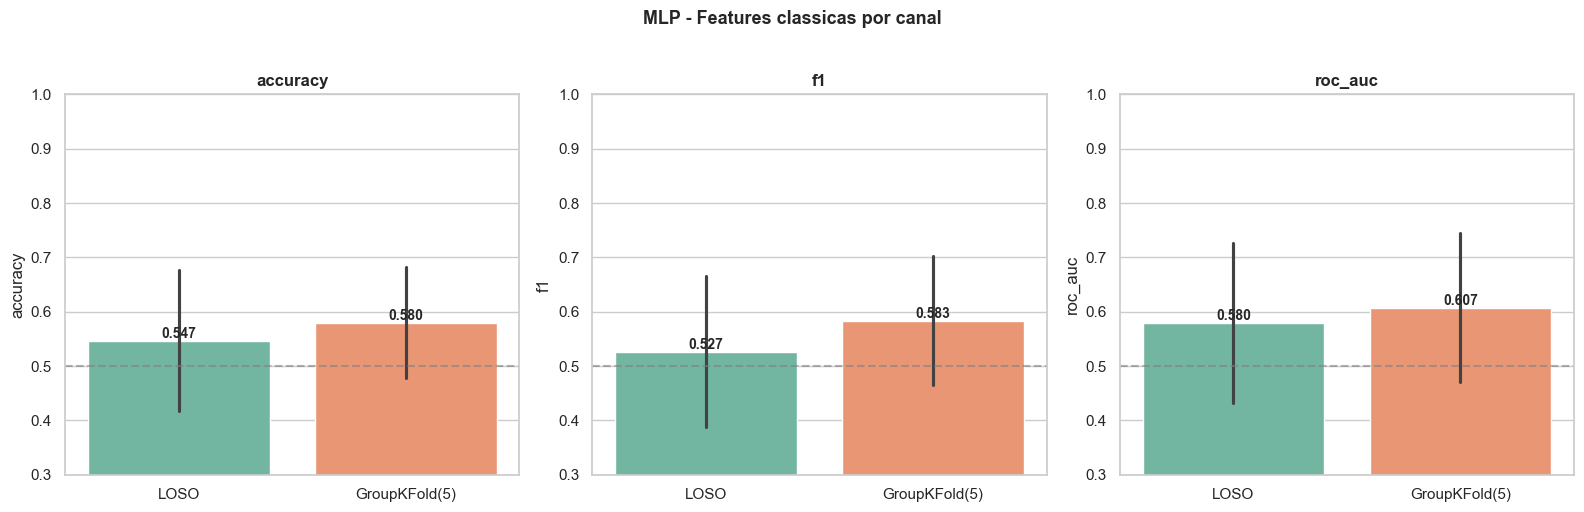

In [37]:
# 2) Barras: acuracia, F1, AUC (LOSO vs GroupKFold)
sub = results_mlp[results_mlp['metric'].isin(['accuracy', 'f1', 'roc_auc'])]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['accuracy', 'f1', 'roc_auc']):
    sub_m = sub[sub['metric'] == metric]
    sns.barplot(data=sub_m, x='cv', y='value', ax=ax,
                errorbar='sd', palette='Set2')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.6, label='chance')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.set_ylim(0.3, 1.0)
    # Anota a media em cima de cada barra
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h):
            ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
fig.suptitle("MLP - Features classicas por canal",
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

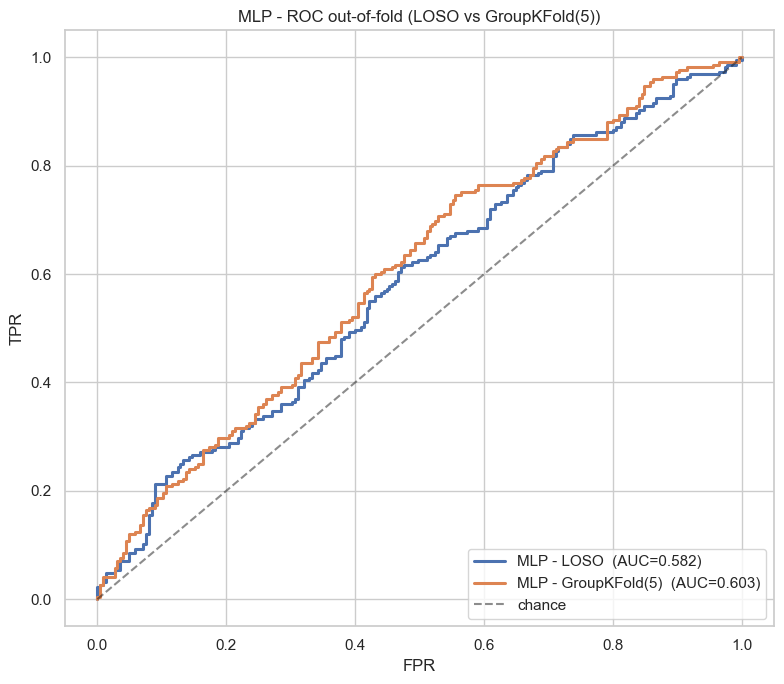

In [38]:
# 3) Curva ROC out-of-fold (uma por estrategia de CV)
fig, ax = plt.subplots(figsize=(8, 7))

for cv_name in CV_STRATEGIES:
    probs = oof_probs[cv_name]
    mask = ~np.isnan(probs)  # LOSO pode ter NaN se algum fold deu erro; aqui esperamos nenhum
    fpr, tpr, _ = roc_curve(y[mask], probs[mask])
    auc = roc_auc_score(y[mask], probs[mask])
    ax.plot(fpr, tpr, lw=2.2, label=f"MLP - {cv_name}  (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="chance")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("MLP - ROC out-of-fold (LOSO vs GroupKFold(5))")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

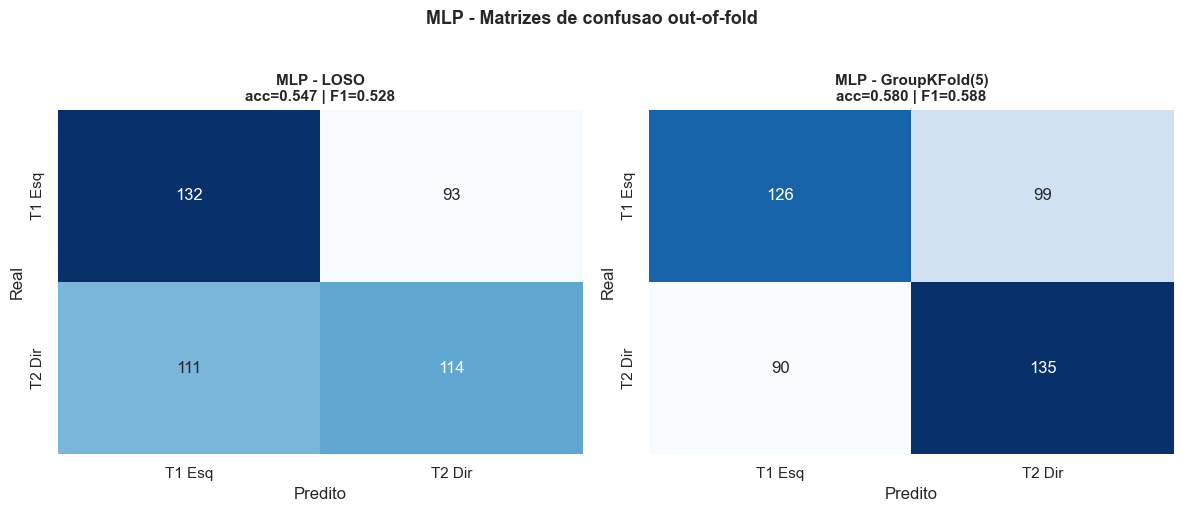

In [39]:
# 4) Matrizes de confusao out-of-fold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cv_name in zip(axes, CV_STRATEGIES):
    preds = oof_preds[cv_name]
    mask  = preds >= 0
    cm    = confusion_matrix(y[mask], preds[mask])
    acc   = accuracy_score(y[mask], preds[mask])
    f1v   = f1_score(y[mask], preds[mask])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["T1 Esq", "T2 Dir"],
                yticklabels=["T1 Esq", "T2 Dir"], cbar=False)
    ax.set_title(f"MLP - {cv_name}\nacc={acc:.3f} | F1={f1v:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")

fig.suptitle("MLP - Matrizes de confusao out-of-fold",
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [40]:
# 5) Sanity check: Dummy classifier (esperado ~0.50 com classes equilibradas)
dummy = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    DummyClassifier(strategy='stratified', random_state=SEED)),
])
dummy_scores = cross_val_score(
    dummy, X_feat, y, groups=groups,
    cv=GroupKFold(n_splits=5), scoring='accuracy', n_jobs=-1,
)
print(f"=== Sanity check ===")
print(f"Dummy stratified (GroupKFold 5): acc = {dummy_scores.mean():.3f} "
      f"+- {dummy_scores.std():.3f}  (esperado ~0.50)")

mlp_acc_gkf = results_mlp[(results_mlp['cv'] == 'GroupKFold(5)') &
                          (results_mlp['metric'] == 'accuracy')]['value']
print(f"MLP             (GroupKFold 5): acc = {mlp_acc_gkf.mean():.3f} "
      f"+- {mlp_acc_gkf.std():.3f}")

improvement = (mlp_acc_gkf.mean() - dummy_scores.mean()) * 100
print(f"\nGanho da MLP sobre o Dummy: +{improvement:.1f} pontos percentuais")

=== Sanity check ===
Dummy stratified (GroupKFold 5): acc = 0.487 +- 0.066  (esperado ~0.50)
MLP             (GroupKFold 5): acc = 0.580 +- 0.103

Ganho da MLP sobre o Dummy: +9.3 pontos percentuais


**Benchmark paralelo - MLPClassifier do sklearn.** Roda a mesma classificacao com o `MLPClassifier` do sklearn (com inner-val + early_stopping proprios) como diagnostico independente. Se sklearn ≈ Keras-v2, isso confirma que as 4 mudancas sao corretas e o teto vem das features.

In [41]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate, cross_val_predict

SCORING = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision':         'precision',
    'recall':            'recall',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
}

# Mesmo pre-processamento da v2: z-score por sujeito + RobustScaler
X_norm_sk = zscore_per_subject(X_feat, groups)

mlp_sklearn = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,                # L2 regularization
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=300,
        early_stopping=True,        # sklearn faz por epoch e bem-comportado
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=SEED,
    )),
])

print("Rodando MLPClassifier (sklearn) em LOSO + GroupKFold(5)...\n")
rows_sk = []
for cv_name, cv in CV_STRATEGIES.items():
    print(f"  [{cv_name}] ...", end=" ", flush=True)
    scores = cross_validate(
        mlp_sklearn, X_norm_sk, y, groups=groups, cv=cv,
        scoring=SCORING, n_jobs=-1, error_score='raise',
    )
    for metric in SCORING:
        for fold_idx, val in enumerate(scores[f'test_{metric}']):
            rows_sk.append({
                'cv':     cv_name,
                'model':  'MLP-sklearn',
                'metric': metric,
                'fold':   fold_idx,
                'value':  val,
            })
    print(f"acc={scores['test_accuracy'].mean():.3f} | "
          f"f1={scores['test_f1'].mean():.3f} | "
          f"auc={scores['test_roc_auc'].mean():.3f}")

results_sklearn = pd.DataFrame(rows_sk)

# Tabela resumo
sk_summ = (results_sklearn.groupby(['cv', 'metric'])['value']
           .agg(['mean', 'std']).reset_index())
sk_summ['display'] = sk_summ.apply(lambda r: fmt(r['mean'], r['std']), axis=1)
sk_pivot = sk_summ.pivot_table(index='cv', columns='metric',
                                values='display', aggfunc='first')
sk_pivot = sk_pivot[METRIC_NAMES]
print("\n=== MLP-sklearn - Tabela resumo (media [dp] entre folds) ===\n")
print(sk_pivot.to_string())

Rodando MLPClassifier (sklearn) em LOSO + GroupKFold(5)...

  [LOSO] ... acc=0.562 | f1=0.563 | auc=0.599
  [GroupKFold(5)] ... acc=0.560 | f1=0.549 | auc=0.571

=== MLP-sklearn - Tabela resumo (media [dp] entre folds) ===

metric              accuracy balanced_accuracy      precision         recall             f1        roc_auc
cv                                                                                                        
GroupKFold(5)  0.560 (0.019)     0.559 (0.019)  0.561 (0.014)  0.545 (0.104)  0.549 (0.058)  0.571 (0.046)
LOSO           0.562 (0.070)     0.562 (0.072)  0.573 (0.091)  0.569 (0.105)  0.563 (0.062)  0.599 (0.125)


Calculando ROC out-of-fold do MLP-sklearn (GroupKFold 5)...


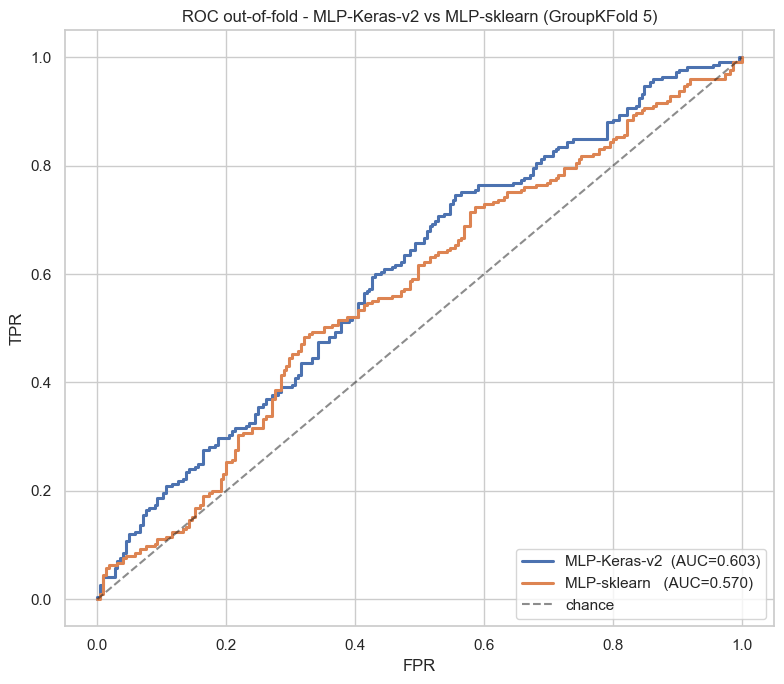

In [42]:
# ROC out-of-fold do MLP-sklearn para comparar visualmente com a v2
from sklearn.model_selection import cross_val_predict

print("Calculando ROC out-of-fold do MLP-sklearn (GroupKFold 5)...")
probs_sk_gkf = cross_val_predict(
    mlp_sklearn, X_norm_sk, y, groups=groups,
    cv=GroupKFold(n_splits=5), method='predict_proba', n_jobs=-1,
)[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))

# v2 (Keras)
fpr, tpr, _ = roc_curve(y, oof_probs['GroupKFold(5)'])
auc = roc_auc_score(y, oof_probs['GroupKFold(5)'])
ax.plot(fpr, tpr, lw=2.2, label=f"MLP-Keras-v2  (AUC={auc:.3f})")

# sklearn
fpr_sk, tpr_sk, _ = roc_curve(y, probs_sk_gkf)
auc_sk = roc_auc_score(y, probs_sk_gkf)
ax.plot(fpr_sk, tpr_sk, lw=2.2, label=f"MLP-sklearn   (AUC={auc_sk:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="chance")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC out-of-fold - MLP-Keras-v2 vs MLP-sklearn (GroupKFold 5)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

Tabela final comparativa Keras-v2 vs sklearn. Diferenca pequena (< 0.03) confirma que o Keras-v2 esta correto.

In [43]:
# Tabela final comparativa: v2 + sklearn
print("=== MLP-Keras-v2 - Tabela resumo (media [dp]) ===\n")
print(pivot_mlp.to_string())

print("\n=== MLP-sklearn - Tabela resumo (media [dp]) ===\n")
print(sk_pivot.to_string())

# Snapshot lado a lado
print("\n=== Snapshot comparativo ===\n")
def snap(df, model_name):
    out = {}
    for cv in ['LOSO', 'GroupKFold(5)']:
        acc = df[(df['cv']==cv) & (df['metric']=='accuracy')]['value']
        auc = df[(df['cv']==cv) & (df['metric']=='roc_auc')]['value']
        f1v = df[(df['cv']==cv) & (df['metric']=='f1')]['value']
        out[cv] = (acc.mean(), acc.std(), f1v.mean(), f1v.std(),
                   auc.mean(), auc.std())
    return out

snap_v2 = snap(results_mlp,     'MLP-v2')
snap_sk = snap(results_sklearn, 'MLP-sklearn')

print(f"{'Modelo':<14} {'CV':<14} {'acc':<16} {'F1':<16} {'AUC':<16}")
print("-" * 80)
for model_name, snp in [('MLP-Keras-v2', snap_v2), ('MLP-sklearn', snap_sk)]:
    for cv in ['LOSO', 'GroupKFold(5)']:
        a_m, a_s, f_m, f_s, u_m, u_s = snp[cv]
        print(f"{model_name:<14} {cv:<14} "
              f"{a_m:.3f} ({a_s:.3f})  "
              f"{f_m:.3f} ({f_s:.3f})  "
              f"{u_m:.3f} ({u_s:.3f})")

print("\n--- Diagnostico ---")
diff_acc = snap_sk['GroupKFold(5)'][0] - snap_v2['GroupKFold(5)'][0]
print(f"Diferenca acc (sklearn - Keras-v2) em GKF: {diff_acc:+.3f}")
if abs(diff_acc) < 0.03:
    print("  -> sklearn e Keras concordam. As 4 mudancas (z-score por sujeito,")
    print("     RobustScaler, sem EarlyStopping ruidoso, ensemble) corrigem o")
    print("     problema da v1. O teto restante e dado pelas features classicas.")
elif diff_acc > 0.03:
    print("  -> sklearn melhor que Keras. Possivel diferenca em otimizador,")
    print("     L2 ou inicializacao. Investigar tamanho de batch / LR / regular.")
else:
    print("  -> Keras-v2 melhor que sklearn. Provavelmente o ensembling esta")
    print("     pegando ganhos que o sklearn (single-shot) nao captura.")

print("\nPara comparar com o baseline ML, abra o pivot_t1 do Modelos_ML.ipynb")
print("(Teste 1, mesmas features classicas) e verifique se o melhor classico")
print("(tipicamente SVM-RBF ou Random Forest) ficou acima ou abaixo dos numeros")
print("acima.")

=== MLP-Keras-v2 - Tabela resumo (media [dp]) ===

metric              accuracy balanced_accuracy      precision         recall             f1        roc_auc
cv                                                                                                        
GroupKFold(5)  0.580 (0.103)     0.581 (0.103)  0.576 (0.095)  0.603 (0.175)  0.583 (0.119)  0.607 (0.137)
LOSO           0.547 (0.129)     0.547 (0.128)  0.557 (0.159)  0.508 (0.147)  0.527 (0.139)  0.580 (0.147)

=== MLP-sklearn - Tabela resumo (media [dp]) ===

metric              accuracy balanced_accuracy      precision         recall             f1        roc_auc
cv                                                                                                        
GroupKFold(5)  0.560 (0.019)     0.559 (0.019)  0.561 (0.014)  0.545 (0.104)  0.549 (0.058)  0.571 (0.046)
LOSO           0.562 (0.070)     0.562 (0.072)  0.573 (0.091)  0.569 (0.105)  0.563 (0.062)  0.599 (0.125)

=== Snapshot comparativo ===

Modelo     

### Teste 1.4 - Dinamica de aprendizado

(A) Curvas medias de loss e accuracy x epoch (entre os 5 folds do GroupKFold).

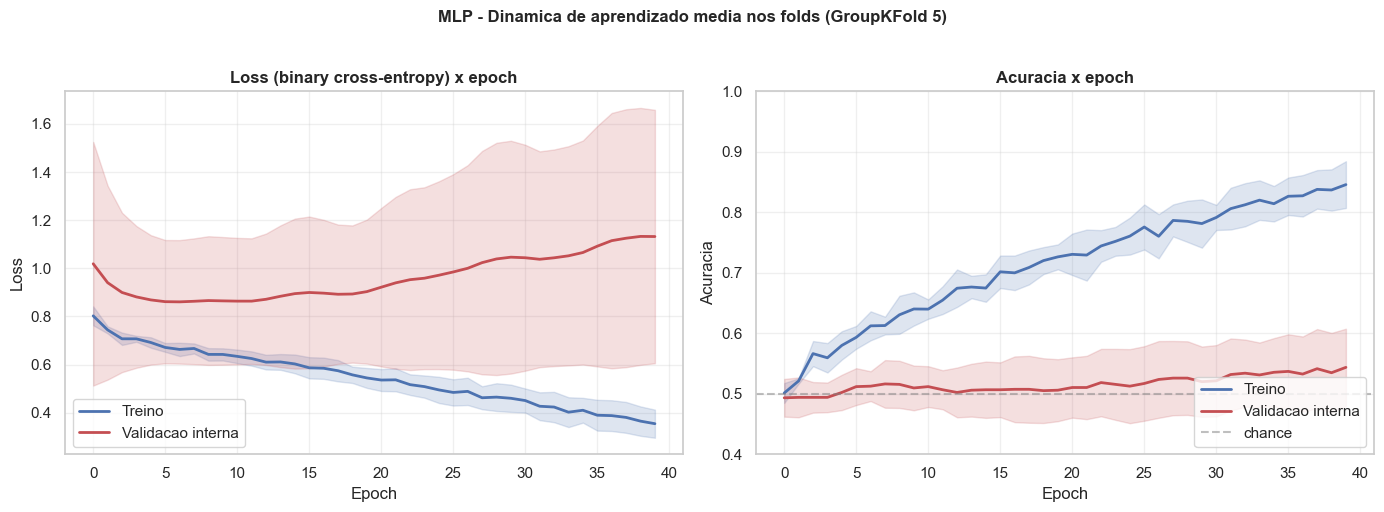


Comprimento das curvas (epochs treinadas por fold): min=40, mediana=40, max=40
(Na v2 todos os folds treinam o mesmo numero fixo de epochs - sem EarlyStopping.
 Olhe acima se train e val divergem nas ultimas epochs => sintoma de overfitting.)


In [44]:
# Agrega histories do GroupKFold(5) e calcula media com IC
def aggregate_histories(histories_list, key):
    """Recebe lista de history dicts e uma chave (ex: 'loss').
    Retorna array (n_folds, max_epochs) com NaN no padding."""
    series = [np.array(h[key]) for h in histories_list]
    max_len = max(len(s) for s in series)
    arr = np.full((len(series), max_len), np.nan)
    for i, s in enumerate(series):
        arr[i, :len(s)] = s
    return arr


hists_gkf = histories['GroupKFold(5)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
loss_tr  = aggregate_histories(hists_gkf, 'loss')
loss_val = aggregate_histories(hists_gkf, 'val_loss')
epochs_axis = np.arange(loss_tr.shape[1])

ax = axes[0]
m_tr,  s_tr  = np.nanmean(loss_tr, 0),  np.nanstd(loss_tr, 0)
m_val, s_val = np.nanmean(loss_val, 0), np.nanstd(loss_val, 0)
ax.plot(epochs_axis, m_tr, 'C0-', label='Treino', lw=2)
ax.fill_between(epochs_axis, m_tr - s_tr, m_tr + s_tr, color='C0', alpha=0.18)
ax.plot(epochs_axis, m_val, 'C3-', label='Validacao interna', lw=2)
ax.fill_between(epochs_axis, m_val - s_val, m_val + s_val, color='C3', alpha=0.18)
ax.set_title('Loss (binary cross-entropy) x epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
ax.grid(True, alpha=0.3)

# Acuracia
acc_tr  = aggregate_histories(hists_gkf, 'accuracy')
acc_val = aggregate_histories(hists_gkf, 'val_accuracy')

ax = axes[1]
m_tr,  s_tr  = np.nanmean(acc_tr, 0),  np.nanstd(acc_tr, 0)
m_val, s_val = np.nanmean(acc_val, 0), np.nanstd(acc_val, 0)
ax.plot(epochs_axis, m_tr, 'C0-', label='Treino', lw=2)
ax.fill_between(epochs_axis, m_tr - s_tr, m_tr + s_tr, color='C0', alpha=0.18)
ax.plot(epochs_axis, m_val, 'C3-', label='Validacao interna', lw=2)
ax.fill_between(epochs_axis, m_val - s_val, m_val + s_val, color='C3', alpha=0.18)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
ax.set_title('Acuracia x epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Acuracia')
ax.set_ylim(0.4, 1.0); ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

fig.suptitle('MLP - Dinamica de aprendizado media nos folds (GroupKFold 5)',
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Diagnostico: comprimento das curvas (na v2 e fixo em n_epochs)
stop_epochs = [len(h['loss']) for h in hists_gkf]
print(f"\nComprimento das curvas (epochs treinadas por fold): "
      f"min={min(stop_epochs)}, mediana={int(np.median(stop_epochs))}, "
      f"max={max(stop_epochs)}")
print("(Na v2 todos os folds treinam o mesmo numero fixo de epochs - sem EarlyStopping.")
print(" Olhe acima se train e val divergem nas ultimas epochs => sintoma de overfitting.)")


(B) Curva detalhada de um fold representativo (fold 0).

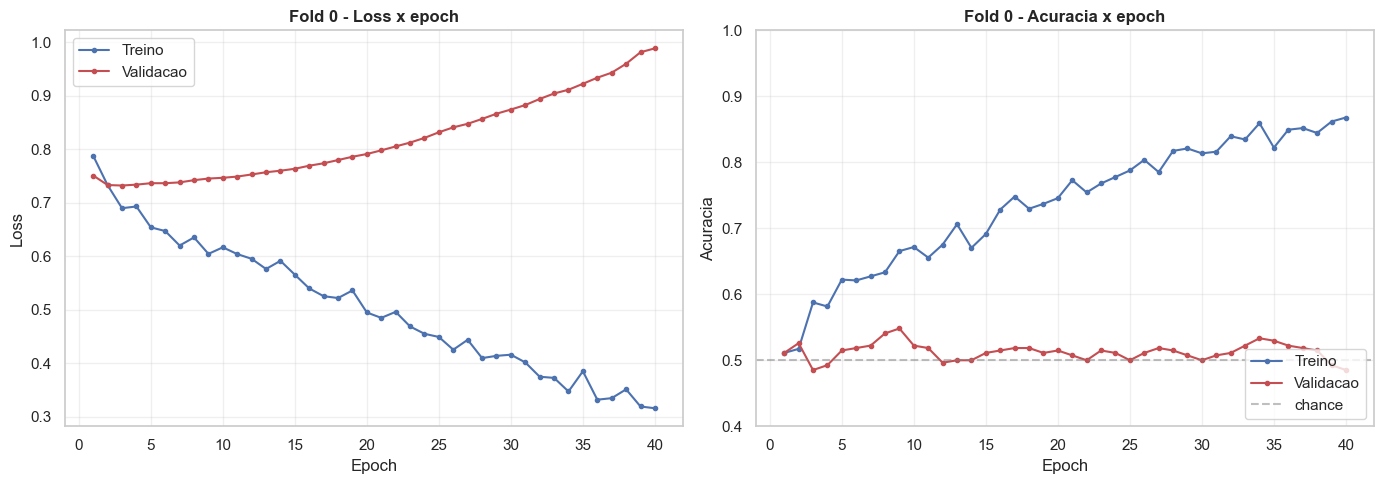

In [45]:
# Plot detalhado do fold 0 do GroupKFold(5) sem mediar
h0 = histories['GroupKFold(5)'][0]
ep = np.arange(1, len(h0['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, h0['loss'],     'C0-o', label='Treino',    markersize=3)
axes[0].plot(ep, h0['val_loss'], 'C3-o', label='Validacao', markersize=3)
axes[0].set_title('Fold 0 - Loss x epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, h0['accuracy'],     'C0-o', label='Treino',    markersize=3)
axes[1].plot(ep, h0['val_accuracy'], 'C3-o', label='Validacao', markersize=3)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
axes[1].set_title('Fold 0 - Acuracia x epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acuracia')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

(C) Learning curve - acuracia x tamanho do treino (5 fracoes de sujeitos).

Calculando learning curve v2 (5 fracoes x 5 folds = 25 treinos)...


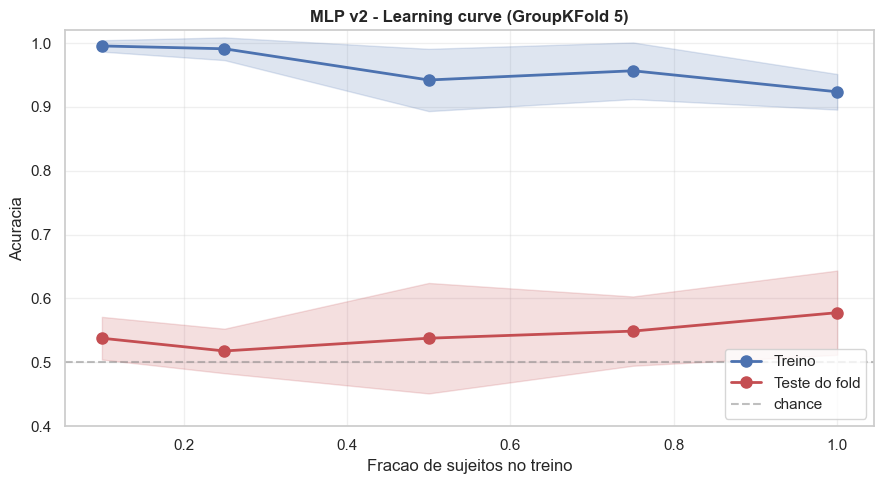


Gap treino-teste (overfitting) em cada fracao:
   10.0% sujeitos -> treino=0.996, teste=0.538, gap=+0.458
   25.0% sujeitos -> treino=0.991, teste=0.518, gap=+0.473
   50.0% sujeitos -> treino=0.942, teste=0.538, gap=+0.404
   75.0% sujeitos -> treino=0.957, teste=0.549, gap=+0.408
  100.0% sujeitos -> treino=0.924, teste=0.578, gap=+0.346


In [46]:
# Learning curve manual v2: usa o mesmo esquema de treino da v2
# (z-score por sujeito + RobustScaler + n_epochs fixos sem EarlyStopping).
# Sem ensembling aqui (1 modelo por ponto) para nao explodir o tempo.

def manual_learning_curve_mlp_v2(X_data, y, groups, cv,
                                 train_fractions=(0.1, 0.25, 0.5, 0.75, 1.0),
                                 n_epochs=40, batch_size=64,
                                 val_frac=0.2, seed=SEED,
                                 apply_subject_zscore=True):
    """Retorna (fractions, train_scores, val_scores) com shape (n_fractions, n_folds).

    Mantem o mesmo pre-processamento da v2:
    - z-score por sujeito (upfront, sem vazamento)
    - RobustScaler ajustado por fold
    - treino fixo de n_epochs (sem EarlyStopping)
    """
    n_folds = cv.get_n_splits(X_data, y, groups=groups)
    train_sc = np.zeros((len(train_fractions), n_folds))
    val_sc   = np.zeros((len(train_fractions), n_folds))

    if apply_subject_zscore:
        X_norm = zscore_per_subject(X_data, groups)
    else:
        X_norm = X_data

    for fold_idx, (tr_full, te) in enumerate(cv.split(X_norm, y, groups=groups)):
        for fi, frac in enumerate(train_fractions):
            # Subamostra SUJEITOS do treino (mantendo logica de grupo)
            g_tr = groups[tr_full]
            uniq_subj = np.unique(g_tr)
            n_keep = max(2, int(np.round(len(uniq_subj) * frac)))
            rng = np.random.default_rng(seed + fold_idx)
            keep_subj = rng.choice(uniq_subj, size=n_keep, replace=False)
            mask_keep = np.isin(g_tr, keep_subj)
            tr_sub = tr_full[mask_keep]

            # Inner val por sujeito (so para o history; nao para EarlyStopping)
            try:
                gss_inner = GroupShuffleSplit(n_splits=1, test_size=val_frac,
                                               random_state=seed + fold_idx)
                inner_tr_rel, inner_val_rel = next(
                    gss_inner.split(tr_sub, groups=groups[tr_sub])
                )
                tr_inner  = tr_sub[inner_tr_rel]
                val_inner = tr_sub[inner_val_rel]
            except ValueError:
                tr_inner  = tr_sub
                val_inner = tr_sub

            # RobustScaler ajustado so no inner train
            scaler = RobustScaler().fit(X_norm[tr_inner])
            X_tr_s  = scaler.transform(X_norm[tr_inner])
            X_val_s = scaler.transform(X_norm[val_inner])
            X_te_s  = scaler.transform(X_norm[te])

            keras.backend.clear_session()
            keras.utils.set_random_seed(seed + fold_idx + fi)
            model = build_mlp(n_features=X_norm.shape[1],
                              seed=seed + fold_idx + fi)

            # Treino FIXO (sem EarlyStopping) - mesmo esquema da v2
            model.fit(X_tr_s, y[tr_inner],
                      validation_data=(X_val_s, y[val_inner]),
                      epochs=n_epochs, batch_size=batch_size,
                      verbose=0, shuffle=True)

            train_sc[fi, fold_idx] = model.evaluate(X_tr_s, y[tr_inner],
                                                     verbose=0)[1]
            val_sc[fi, fold_idx]   = model.evaluate(X_te_s, y[te],
                                                     verbose=0)[1]

    return np.array(train_fractions), train_sc, val_sc


print("Calculando learning curve v2 (5 fracoes x 5 folds = 25 treinos)...")
fracs, lc_tr, lc_val = manual_learning_curve_mlp_v2(
    X_feat, y, groups, GroupKFold(n_splits=5),
    train_fractions=(0.1, 0.25, 0.5, 0.75, 1.0),
    n_epochs=40, batch_size=64, val_frac=0.2,
    apply_subject_zscore=True,
)

fig, ax = plt.subplots(figsize=(9, 5))
m_tr,  s_tr  = lc_tr.mean(1),  lc_tr.std(1)
m_val, s_val = lc_val.mean(1), lc_val.std(1)
ax.plot(fracs, m_tr,  'C0-o', label='Treino',    markersize=8, lw=2)
ax.fill_between(fracs, m_tr - s_tr,  m_tr + s_tr,  color='C0', alpha=0.18)
ax.plot(fracs, m_val, 'C3-o', label='Teste do fold', markersize=8, lw=2)
ax.fill_between(fracs, m_val - s_val, m_val + s_val, color='C3', alpha=0.18)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
ax.set_xlabel('Fracao de sujeitos no treino')
ax.set_ylabel('Acuracia')
ax.set_title('MLP v2 - Learning curve (GroupKFold 5)', fontweight='bold')
ax.set_ylim(0.4, 1.02)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nGap treino-teste (overfitting) em cada fracao:")
for f, mt, mv in zip(fracs, m_tr, m_val):
    print(f"  {f*100:5.1f}% sujeitos -> treino={mt:.3f}, teste={mv:.3f}, gap={mt-mv:+.3f}")

## Teste 2 - Reducao de dimensionalidade (PCA + MLP)

**Pergunta:** as `7 x n_canais` features tem redundancia (canais vizinhos compartilham informacao). Reduzir a dimensionalidade via PCA antes do MLP melhora a generalizacao?

**Hipoteses:**
- k pequeno demais (5-10): perde informacao, AUC cai;
- k otimo: tipicamente entre k80 e k90 da analise de variancia;
- k = full: equivalente ao Teste 1.

Tambem incluimos t-SNE (visualizacao 2D) e LDA (projecao supervisionada 1D) como analises exploratorias da estrutura dos dados.

### Teste 2.1 - Pre-processamento (analise de variancia explicada)

Antes de usar PCA como pre-processador, vamos entender quanta variancia esta em cada componente. Aplicamos PCA na matriz inteira apos z-score por sujeito + RobustScaler.

Total de features: 105
Componentes para 80% de variancia: 1
Componentes para 90% de variancia: 2
Componentes para 95% de variancia: 6


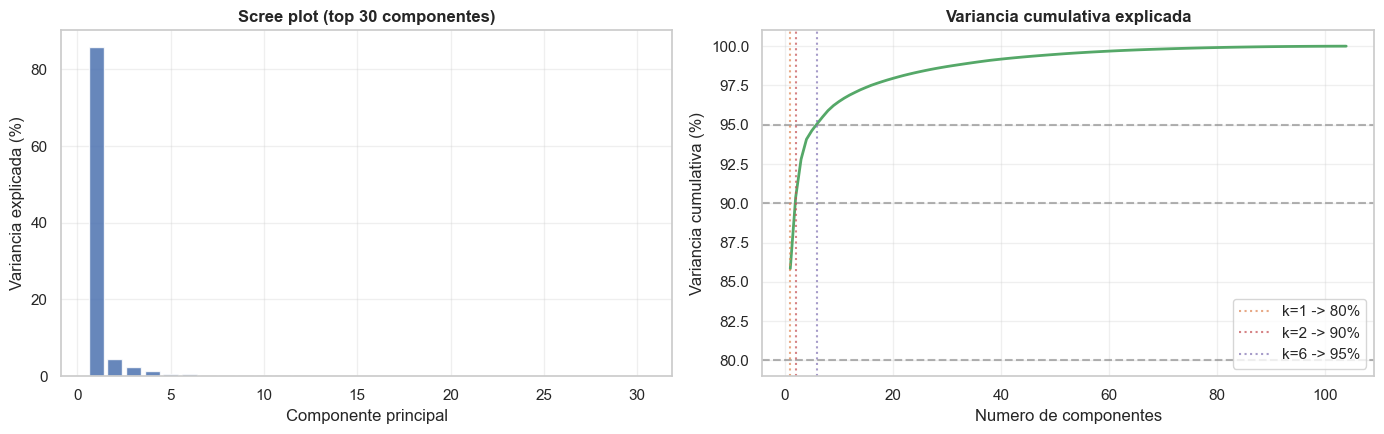

In [47]:
# 5.1 - PCA exploratoria: variancia explicada
# Aplica z-score por sujeito + RobustScaler antes de PCA (mesmo pipeline da Tarefa 2)

# Imports especificos para Teste 2 (PCA + analises complementares)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import cross_validate

X_norm_full = zscore_per_subject(X_feat, groups)
X_scaled_full = RobustScaler().fit_transform(X_norm_full)

# PCA com TODAS as componentes para analise
pca_full = PCA(n_components=min(X_scaled_full.shape) - 1, random_state=SEED)
pca_full.fit(X_scaled_full)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

# Identifica k para 80%, 90%, 95% de variancia
k80 = int(np.argmax(cum >= 0.80) + 1)
k90 = int(np.argmax(cum >= 0.90) + 1)
k95 = int(np.argmax(cum >= 0.95) + 1)

print(f"Total de features: {X_feat.shape[1]}")
print(f"Componentes para 80% de variancia: {k80}")
print(f"Componentes para 90% de variancia: {k90}")
print(f"Componentes para 95% de variancia: {k95}")

# Plot duplo: scree + cumulativa
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Scree (top 30)
top_n = min(30, len(evr))
axes[0].bar(range(1, top_n + 1), evr[:top_n] * 100, color='C0', alpha=0.85)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Variancia explicada (%)")
axes[0].set_title(f"Scree plot (top {top_n} componentes)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulativa
axes[1].plot(range(1, len(cum) + 1), cum * 100, '-', color='C2', lw=2)
axes[1].axhline(80, color='gray', ls='--', alpha=0.6)
axes[1].axhline(90, color='gray', ls='--', alpha=0.6)
axes[1].axhline(95, color='gray', ls='--', alpha=0.6)
axes[1].axvline(k80, color='C1', ls=':', alpha=0.7, label=f'k={k80} -> 80%')
axes[1].axvline(k90, color='C3', ls=':', alpha=0.7, label=f'k={k90} -> 90%')
axes[1].axvline(k95, color='C4', ls=':', alpha=0.7, label=f'k={k95} -> 95%')
axes[1].set_xlabel("Numero de componentes")
axes[1].set_ylabel("Variancia cumulativa (%)")
axes[1].set_title("Variancia cumulativa explicada", fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### Teste 2.2 - Treino e validacao (PCA + MLP com k variavel)

Avaliamos o efeito da reducao de dimensionalidade no desempenho. Para cada k testado, montamos um Pipeline(RobustScaler + PCA(k) + MLPClassifier) com GroupKFold(5). PCA e ajustada **apenas no treino de cada fold** (sem vazamento).

In [48]:
# 5.2 - PCA + MLP: classificacao com k variavel

# Z-score por sujeito aplicado UMA vez (sem vazamento entre sujeitos)
X_norm_pca = zscore_per_subject(X_feat, groups)

# Lista de k a testar (inclui o k90 e k80 calculados na 5.1)
k_values = sorted(set([5, 10, 25, k80, k90, 50, 100]))
k_values = [k for k in k_values if k < X_norm_pca.shape[1]]
k_values.append('full')  # baseline sem reducao

print(f"Testando k = {k_values}")
print(f"(GroupKFold(5), MLPClassifier(128,64,32))\n")

def make_pca_mlp_pipe(k):
    """Pipeline scaler -> PCA(k) -> MLP. Se k='full', omite PCA."""
    steps = [('scaler', RobustScaler())]
    if k != 'full':
        steps.append(('pca', PCA(n_components=int(k), random_state=SEED)))
    steps.append(('clf', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=SEED,
    )))
    return SkPipeline(steps)


SCORING = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision':         'precision',
    'recall':            'recall',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
}

rows_pca = []
for k in k_values:
    pipe = make_pca_mlp_pipe(k)
    print(f"  k = {str(k):>5} ...", end=" ", flush=True)
    scores = cross_validate(
        pipe, X_norm_pca, y, groups=groups,
        cv=GroupKFold(n_splits=5), scoring=SCORING,
        n_jobs=-1, error_score='raise',
    )
    for metric in SCORING:
        for fold_idx, val in enumerate(scores[f'test_{metric}']):
            rows_pca.append({
                'k': str(k), 'metric': metric, 'fold': fold_idx, 'value': val,
            })
    print(f"acc={scores['test_accuracy'].mean():.3f} | "
          f"f1={scores['test_f1'].mean():.3f} | "
          f"auc={scores['test_roc_auc'].mean():.3f}")

results_pca = pd.DataFrame(rows_pca)

# Tabela resumo
pca_summ = (results_pca.groupby(['k', 'metric'])['value']
            .agg(['mean', 'std']).reset_index())
pca_summ['display'] = pca_summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)

# Ordena k corretamente (numericos primeiro, 'full' por ultimo)
def k_sort_key(s):
    return (s == 'full', int(s) if s != 'full' else 9999)

k_order = sorted(results_pca['k'].unique(), key=k_sort_key)
pca_pivot = pca_summ.pivot_table(index='k', columns='metric', values='display', aggfunc='first')
pca_pivot = pca_pivot.reindex(k_order)[METRIC_NAMES]
print("\n=== PCA + MLP - Tabela resumo (media [dp] entre folds) ===\n")
print(pca_pivot.to_string())

Testando k = [1, 2, 5, 10, 25, 50, 100, 'full']
(GroupKFold(5), MLPClassifier(128,64,32))

  k =     1 ... acc=0.538 | f1=0.505 | auc=0.560
  k =     2 ... acc=0.496 | f1=0.482 | auc=0.487
  k =     5 ... acc=0.511 | f1=0.401 | auc=0.501
  k =    10 ... acc=0.500 | f1=0.435 | auc=0.521
  k =    25 ... acc=0.527 | f1=0.526 | auc=0.536
  k =    50 ... acc=0.569 | f1=0.553 | auc=0.565
  k =   100 ... acc=0.562 | f1=0.564 | auc=0.582
  k =  full ... acc=0.560 | f1=0.549 | auc=0.571

=== PCA + MLP - Tabela resumo (media [dp] entre folds) ===

metric       accuracy balanced_accuracy      precision         recall             f1        roc_auc
k                                                                                                  
1       0.538 (0.034)     0.539 (0.035)  0.560 (0.074)  0.486 (0.130)  0.505 (0.068)  0.560 (0.045)
2       0.496 (0.071)     0.497 (0.072)  0.499 (0.083)  0.477 (0.114)  0.482 (0.084)  0.487 (0.076)
5       0.511 (0.047)     0.510 (0.046)  0.513 (0.047)  

### Teste 2.3 - Metricas

Plot AUC e accuracy vs k. Identifica o melhor numero de componentes.

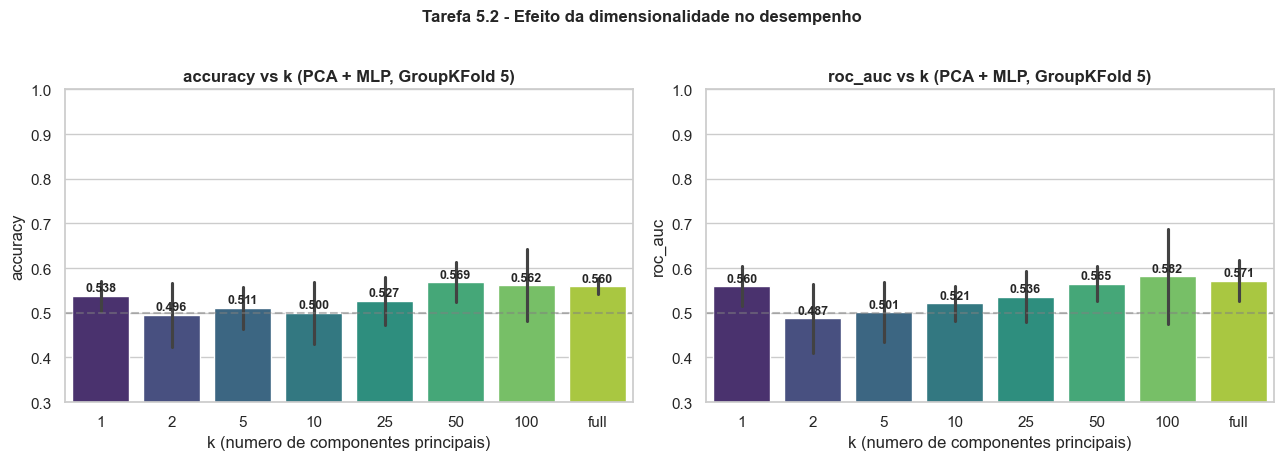


Melhor k por AUC medio:
  k =   100 -> AUC = 0.582
  k =  full -> AUC = 0.571
  k =    50 -> AUC = 0.565


In [49]:
# 5.2 cont. - Plot AUC e accuracy vs k
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric in zip(axes, ['accuracy', 'roc_auc']):
    sub = results_pca[results_pca['metric'] == metric].copy()
    # Ordena por k, com 'full' no final
    sub['k_order'] = sub['k'].apply(lambda s: 9999 if s == 'full' else int(s))
    sub = sub.sort_values('k_order')

    sns.barplot(data=sub, x='k', y='value', ax=ax,
                order=k_order, palette='viridis', errorbar='sd')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
    ax.set_title(f"{metric} vs k (PCA + MLP, GroupKFold 5)", fontweight='bold')
    ax.set_xlabel("k (numero de componentes principais)")
    ax.set_ylabel(metric)
    ax.set_ylim(0.3, 1.0)
    # Anota valores
    means = sub.groupby('k', sort=False)['value'].mean().reindex(k_order)
    for i, m in enumerate(means.values):
        if not np.isnan(m):
            ax.text(i, m + 0.01, f"{m:.3f}", ha='center', fontsize=9, fontweight='bold')

fig.suptitle("Tarefa 5.2 - Efeito da dimensionalidade no desempenho",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Identifica o melhor k
best_k_row = (results_pca[results_pca['metric'] == 'roc_auc']
              .groupby('k')['value'].mean().sort_values(ascending=False))
print(f"\nMelhor k por AUC medio:")
for kk, auc in best_k_row.head(3).items():
    print(f"  k = {kk:>5} -> AUC = {auc:.3f}")

### Teste 2.4 - Analises complementares (t-SNE e LDA)

**t-SNE 2D:** projecao nao-linear que preserva vizinhanca local. Se as classes T1 e T2 nao se separam bem aqui, isso reforca o teto observado nos outros testes.

Pre-PCA aplicada: 105 -> 50 dims
t-SNE concluido.


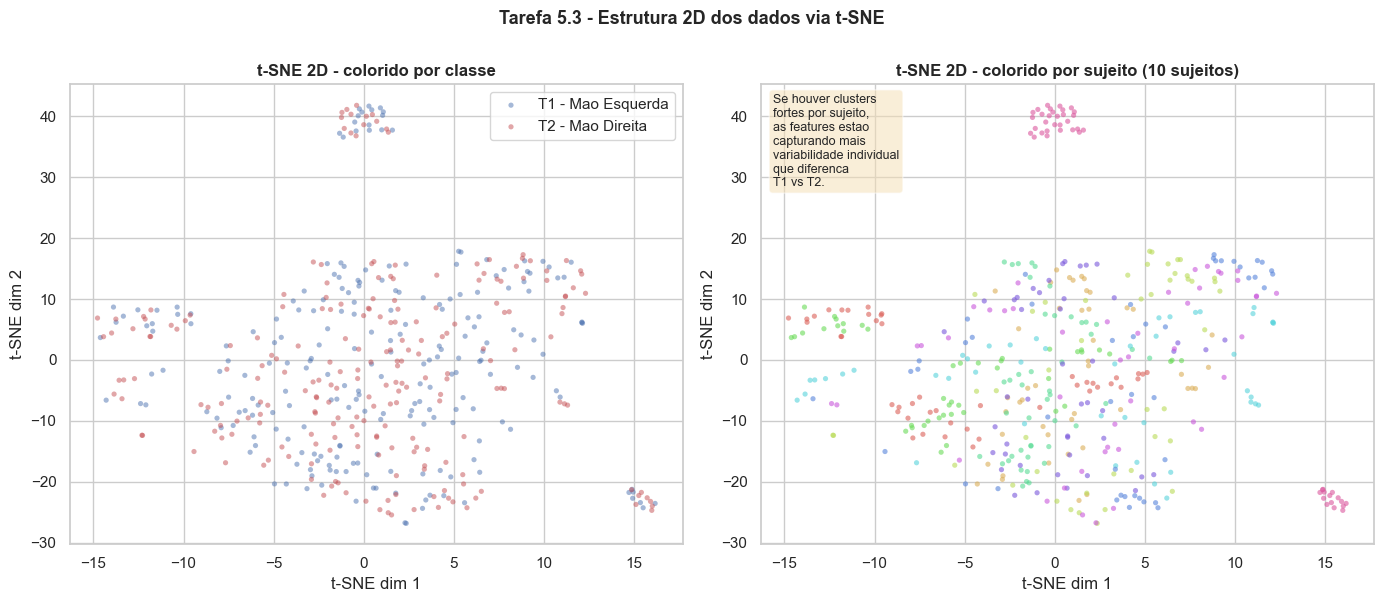

In [50]:
# 5.3 - t-SNE 2D
# Pre-processamento (mesmo da 5.1)
X_norm_tsne = zscore_per_subject(X_feat, groups)
X_scaled_tsne = RobustScaler().fit_transform(X_norm_tsne)

# PCA -> 50 antes de t-SNE (recomendado para evitar dist em alta-dim)
n_pca_pre = min(50, X_scaled_tsne.shape[1] - 1)
X_pca_pre = PCA(n_components=n_pca_pre, random_state=SEED).fit_transform(X_scaled_tsne)
print(f"Pre-PCA aplicada: {X_scaled_tsne.shape[1]} -> {n_pca_pre} dims")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)
X_tsne = tsne.fit_transform(X_pca_pre)
print("t-SNE concluido.")

# Scatter colorido por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for cls, color, label in [(0, 'C0', 'T1 - Mao Esquerda'), (1, 'C3', 'T2 - Mao Direita')]:
    mask = y == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=label,
               alpha=0.5, s=14, edgecolors='none')
ax.set_title("t-SNE 2D - colorido por classe", fontweight='bold')
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc='best')

# Mesma projecao colorida por sujeito (para ver se ha cluster por sujeito - red flag)
ax = axes[1]
n_subj = len(np.unique(groups))
palette = sns.color_palette('hls', n_colors=n_subj)
for si, subj in enumerate(np.unique(groups)):
    mask = groups == subj
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[palette[si]],
               alpha=0.6, s=14, edgecolors='none')
ax.set_title(f"t-SNE 2D - colorido por sujeito ({n_subj} sujeitos)", fontweight='bold')
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.text(0.02, 0.98,
        "Se houver clusters\nfortes por sujeito,\nas features estao\ncapturando mais\nvariabilidade individual\nque diferenca\nT1 vs T2.",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle("Tarefa 5.3 - Estrutura 2D dos dados via t-SNE",
              fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

**LDA (1D supervisionado):** se a separacao for boa, classes sao linearmente separaveis nas features classicas. Validacao CV-safe (out-of-fold).

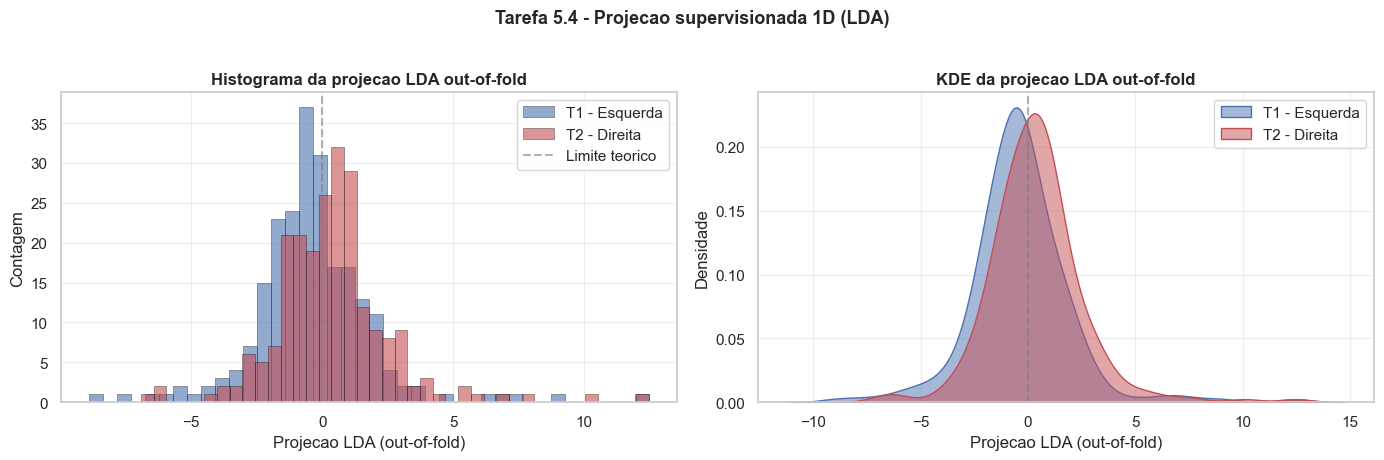


AUC do score LDA out-of-fold: 0.616
Distribuicoes se sobrepoem: SIM (esperado SIM)
Media projecao T1: -0.370
Media projecao T2: +0.370


In [51]:
# 5.4 - LDA out-of-fold (CV-safe)
X_norm_lda = zscore_per_subject(X_feat, groups)

oof_lda = np.full(len(y), np.nan)
gkf_lda = GroupKFold(n_splits=5)

for tr, te in gkf_lda.split(X_norm_lda, y, groups=groups):
    # Pipeline: scaler -> LDA, ajustado so no treino do fold
    scaler = RobustScaler().fit(X_norm_lda[tr])
    Xtr_s = scaler.transform(X_norm_lda[tr])
    Xte_s = scaler.transform(X_norm_lda[te])

    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(Xtr_s, y[tr])
    oof_lda[te] = lda.transform(Xte_s).ravel()

assert np.isnan(oof_lda).sum() == 0

# Histograma por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.hist(oof_lda[y == 0], bins=40, alpha=0.6, label='T1 - Esquerda',
         color='C0', edgecolor='black', linewidth=0.4)
ax.hist(oof_lda[y == 1], bins=40, alpha=0.6, label='T2 - Direita',
         color='C3', edgecolor='black', linewidth=0.4)
ax.axvline(0, color='gray', ls='--', alpha=0.6, label='Limite teorico')
ax.set_xlabel("Projecao LDA (out-of-fold)")
ax.set_ylabel("Contagem")
ax.set_title("Histograma da projecao LDA out-of-fold", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# KDE plot do mesmo (mais limpo visualmente)
ax = axes[1]
sns.kdeplot(oof_lda[y == 0], ax=ax, fill=True, label='T1 - Esquerda', color='C0', alpha=0.5)
sns.kdeplot(oof_lda[y == 1], ax=ax, fill=True, label='T2 - Direita', color='C3', alpha=0.5)
ax.axvline(0, color='gray', ls='--', alpha=0.6)
ax.set_xlabel("Projecao LDA (out-of-fold)")
ax.set_ylabel("Densidade")
ax.set_title("KDE da projecao LDA out-of-fold", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Tarefa 5.4 - Projecao supervisionada 1D (LDA)",
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Quantifica a separacao via AUC do score LDA
from sklearn.metrics import roc_auc_score
auc_lda = roc_auc_score(y, oof_lda)
overlap = (oof_lda[y == 0].max() > oof_lda[y == 1].min())
print(f"\nAUC do score LDA out-of-fold: {auc_lda:.3f}")
print(f"Distribuicoes se sobrepoem: {'SIM' if overlap else 'NAO'} (esperado SIM)")
print(f"Media projecao T1: {oof_lda[y==0].mean():+.3f}")
print(f"Media projecao T2: {oof_lda[y==1].mean():+.3f}")

## Teste 3 - Tratamento de dados desbalanceados (SMOTE / Undersampling)

**Pergunta:** o EEGBCI MI e balanceado por construcao. Mas em uma BCI real, classes podem ficar desbalanceadas (paciente faz mais MI direita que esquerda em uma sessao, por exemplo). Como o MLP se comporta nesse cenario, e quanto SMOTE / Undersampling ajudam?

**Abordagem:** induzimos um desbalanceamento controlado de ~70/30 (descartando 60% das epocas T2 estratificado por sujeito), depois comparamos:
1. **Sem balanceamento** (baseline ruim, especialmente recall T2);
2. **SMOTE** (oversampling sintetico, dentro do pipeline);
3. **Random Undersampling** (descarta amostras da majoritaria).

**Por que dentro do pipeline?** Aplicar SMOTE/undersampling antes do CV vaza informacao do teste no treino. `imblearn.pipeline.Pipeline` resolve isso aplicando o resampler **so na fold de treino**.

**Metricas-chave:** `accuracy` e enganoso (modelo trivial "sempre majoritaria" ja acerta 70%); `balanced_accuracy` e `recall(T2)` sao honestos.

### Teste 3.1 - Pre-processamento (inducao do desbalanceamento)

Confirma o balanco original e induz desbalanceamento controlado.

=== Balanco original do EEGBCI MI ===
T1 (esquerda): 225 epocas (50.0%)
T2 (direita):  225 epocas (50.0%)
Razao T1/T2:   1.00


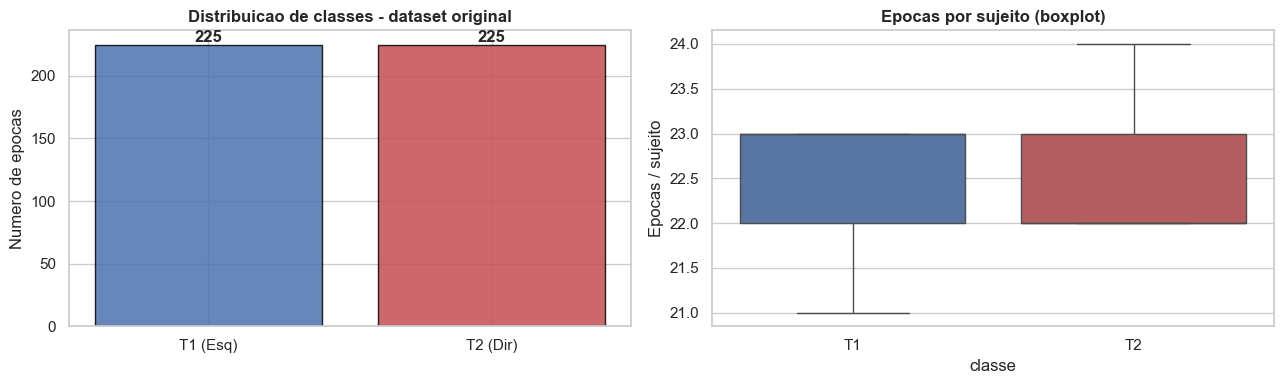


=> Dataset original e essencialmente balanceado. Vamos induzir
   desbalanceamento controlado para estudar as tecnicas de correcao.


In [52]:
# 6.1 - Balanco original
n_t1 = (y == 0).sum()
n_t2 = (y == 1).sum()
total = len(y)

print("=== Balanco original do EEGBCI MI ===")
print(f"T1 (esquerda): {n_t1} epocas ({n_t1/total:.1%})")
print(f"T2 (direita):  {n_t2} epocas ({n_t2/total:.1%})")
print(f"Razao T1/T2:   {n_t1/n_t2:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(['T1 (Esq)', 'T2 (Dir)'], [n_t1, n_t2],
       color=['C0', 'C3'], alpha=0.85, edgecolor='black')
ax.set_ylabel("Numero de epocas")
ax.set_title("Distribuicao de classes - dataset original", fontweight='bold')
for i, v in enumerate([n_t1, n_t2]):
    ax.text(i, v + total*0.005, f"{v}", ha='center', fontweight='bold')

# Por sujeito
ax = axes[1]
subj_balance = []
for subj in np.unique(groups):
    mask = groups == subj
    subj_balance.append({
        'subj': subj,
        'T1': int((y[mask] == 0).sum()),
        'T2': int((y[mask] == 1).sum()),
    })
sb = pd.DataFrame(subj_balance)
sb_melt = sb.melt(id_vars='subj', value_vars=['T1', 'T2'],
                   var_name='classe', value_name='count')
sns.boxplot(data=sb_melt, x='classe', y='count', ax=ax,
            palette={'T1': 'C0', 'T2': 'C3'})
ax.set_title("Epocas por sujeito (boxplot)", fontweight='bold')
ax.set_ylabel("Epocas / sujeito")

plt.tight_layout(); plt.show()

if abs(n_t1 - n_t2) / total < 0.05:
    print("\n=> Dataset original e essencialmente balanceado. Vamos induzir")
    print("   desbalanceamento controlado para estudar as tecnicas de correcao.")
else:
    print(f"\n=> Pequeno desbalanco natural: diferenca de {abs(n_t1-n_t2)/total:.1%}.")

=== Apos inducao de desbalanceamento ===
T1 (esquerda): 225 epocas (71.2%)
T2 (direita):  91 epocas (28.8%)
Razao T1/T2:   2.47
Total:         316 epocas (perda de 134)
Sujeitos preservados: 10


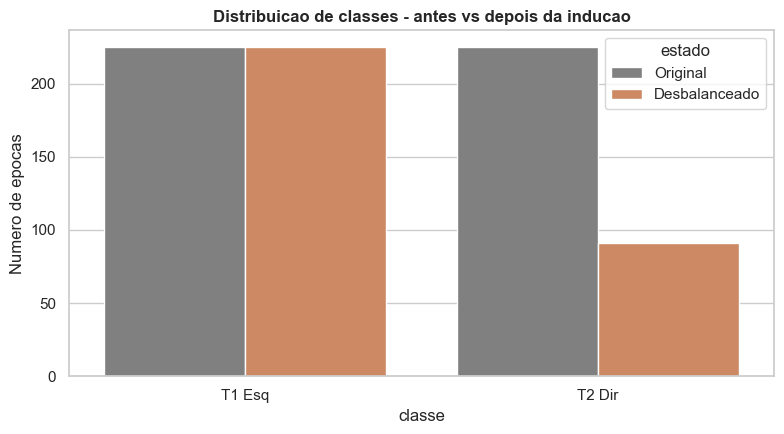


Z-score por sujeito aplicado em X_imb_norm: shape (316, 105)


In [53]:
# 6.2 - Inducao de desbalanceamento controlado
def induce_imbalance(X, y, groups, drop_class=1, drop_frac=0.6, seed=SEED):
    """Descarta drop_frac das epocas de drop_class, estratificado por sujeito.

    Retorna (X_imb, y_imb, groups_imb, keep_mask).
    """
    rng = np.random.default_rng(seed)
    keep_mask = np.ones(len(y), dtype=bool)
    for subj in np.unique(groups):
        subj_target_idx = np.where((groups == subj) & (y == drop_class))[0]
        n_drop = int(round(len(subj_target_idx) * drop_frac))
        if n_drop > 0:
            drop_idx = rng.choice(subj_target_idx, size=n_drop, replace=False)
            keep_mask[drop_idx] = False
    return X[keep_mask], y[keep_mask], groups[keep_mask], keep_mask


X_imb, y_imb, groups_imb, _ = induce_imbalance(
    X_feat, y, groups, drop_class=1, drop_frac=0.6, seed=SEED,
)

n_t1_i = (y_imb == 0).sum()
n_t2_i = (y_imb == 1).sum()
total_i = len(y_imb)

print("=== Apos inducao de desbalanceamento ===")
print(f"T1 (esquerda): {n_t1_i} epocas ({n_t1_i/total_i:.1%})")
print(f"T2 (direita):  {n_t2_i} epocas ({n_t2_i/total_i:.1%})")
print(f"Razao T1/T2:   {n_t1_i/n_t2_i:.2f}")
print(f"Total:         {total_i} epocas (perda de {len(y) - total_i})")
print(f"Sujeitos preservados: {len(np.unique(groups_imb))}")

# Plot comparativo
fig, ax = plt.subplots(figsize=(8, 4.5))
df_compare = pd.DataFrame({
    'classe': ['T1 Esq', 'T1 Esq', 'T2 Dir', 'T2 Dir'],
    'estado': ['Original', 'Desbalanceado', 'Original', 'Desbalanceado'],
    'count':  [n_t1, n_t1_i, n_t2, n_t2_i],
})
sns.barplot(data=df_compare, x='classe', y='count', hue='estado', ax=ax,
            palette={'Original': 'gray', 'Desbalanceado': 'C1'})
ax.set_title("Distribuicao de classes - antes vs depois da inducao",
              fontweight='bold')
ax.set_ylabel("Numero de epocas")
plt.tight_layout(); plt.show()

# Z-score por sujeito no dataset desbalanceado
X_imb_norm = zscore_per_subject(X_imb, groups_imb)
print(f"\nZ-score por sujeito aplicado em X_imb_norm: shape {X_imb_norm.shape}")

### Teste 3.2 - Treino e validacao (3 estrategias)

**Estrategia 1: baseline sem balanceamento.**

In [55]:
# 6.3 - Baseline MLP no dataset desbalanceado, SEM correcao

# Imports especificos para Teste 3 (tratamento de desbalanceamento)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier


def make_mlp_clf(seed=SEED):
    """Cria um MLPClassifier com a config padrao usada na Tarefa 5."""
    return MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', solver='adam',
        alpha=1e-4, learning_rate_init=1e-3,
        batch_size=64, max_iter=300,
        early_stopping=True, validation_fraction=0.2,
        n_iter_no_change=20, random_state=seed,
    )


pipe_no_bal = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf',    make_mlp_clf()),
])

print("Avaliando MLP sem balanceamento (GroupKFold 5)...")
scores_none = cross_validate(
    pipe_no_bal, X_imb_norm, y_imb, groups=groups_imb,
    cv=GroupKFold(n_splits=5), scoring=SCORING,
    n_jobs=-1, error_score='raise',
)
print(f"  acc={scores_none['test_accuracy'].mean():.3f} | "
      f"bal_acc={scores_none['test_balanced_accuracy'].mean():.3f} | "
      f"recall(T2)={scores_none['test_recall'].mean():.3f} | "
      f"F1={scores_none['test_f1'].mean():.3f} | "
      f"AUC={scores_none['test_roc_auc'].mean():.3f}")

Avaliando MLP sem balanceamento (GroupKFold 5)...
  acc=0.702 | bal_acc=0.540 | recall(T2)=0.155 | F1=0.215 | AUC=0.567


**Estrategia 2: SMOTE (oversampling sintetico).**

In [56]:
# 6.4 - SMOTE dentro do pipeline (so no treino do fold)
pipe_smote = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  SMOTE(random_state=SEED, k_neighbors=5)),
    ('clf',    make_mlp_clf()),
])

print("Avaliando MLP com SMOTE (GroupKFold 5)...")
scores_smote = cross_validate(
    pipe_smote, X_imb_norm, y_imb, groups=groups_imb,
    cv=GroupKFold(n_splits=5), scoring=SCORING,
    n_jobs=-1, error_score='raise',
)
print(f"  acc={scores_smote['test_accuracy'].mean():.3f} | "
      f"bal_acc={scores_smote['test_balanced_accuracy'].mean():.3f} | "
      f"recall(T2)={scores_smote['test_recall'].mean():.3f} | "
      f"F1={scores_smote['test_f1'].mean():.3f} | "
      f"AUC={scores_smote['test_roc_auc'].mean():.3f}")

Avaliando MLP com SMOTE (GroupKFold 5)...
  acc=0.661 | bal_acc=0.576 | recall(T2)=0.375 | F1=0.386 | AUC=0.631


**Estrategia 3: Random Undersampling.**

In [57]:
# 6.5 - Random Undersampling
pipe_rus = ImbPipeline([
    ('scaler', RobustScaler()),
    ('rus',    RandomUnderSampler(random_state=SEED)),
    ('clf',    make_mlp_clf()),
])

print("Avaliando MLP com Random Undersampling (GroupKFold 5)...")
scores_rus = cross_validate(
    pipe_rus, X_imb_norm, y_imb, groups=groups_imb,
    cv=GroupKFold(n_splits=5), scoring=SCORING,
    n_jobs=-1, error_score='raise',
)
print(f"  acc={scores_rus['test_accuracy'].mean():.3f} | "
      f"bal_acc={scores_rus['test_balanced_accuracy'].mean():.3f} | "
      f"recall(T2)={scores_rus['test_recall'].mean():.3f} | "
      f"F1={scores_rus['test_f1'].mean():.3f} | "
      f"AUC={scores_rus['test_roc_auc'].mean():.3f}")

Avaliando MLP com Random Undersampling (GroupKFold 5)...
  acc=0.534 | bal_acc=0.547 | recall(T2)=0.581 | F1=0.414 | AUC=0.553


### Teste 3.3 - Metricas e comparacao

Tabela e graficos lado-a-lado. Foco em balanced_accuracy e recall(T2).

=== Comparacao: antes vs depois do balanceamento ===

metric                  accuracy balanced_accuracy      precision         recall             f1        roc_auc
strategy                                                                                                      
Sem balanceamento  0.702 (0.076)     0.540 (0.084)  0.383 (0.336)  0.155 (0.144)  0.215 (0.202)  0.567 (0.107)
SMOTE              0.661 (0.050)     0.576 (0.046)  0.413 (0.077)  0.375 (0.103)  0.386 (0.072)  0.631 (0.055)
Undersampling      0.534 (0.090)     0.547 (0.031)  0.333 (0.022)  0.581 (0.154)  0.414 (0.040)  0.553 (0.037)


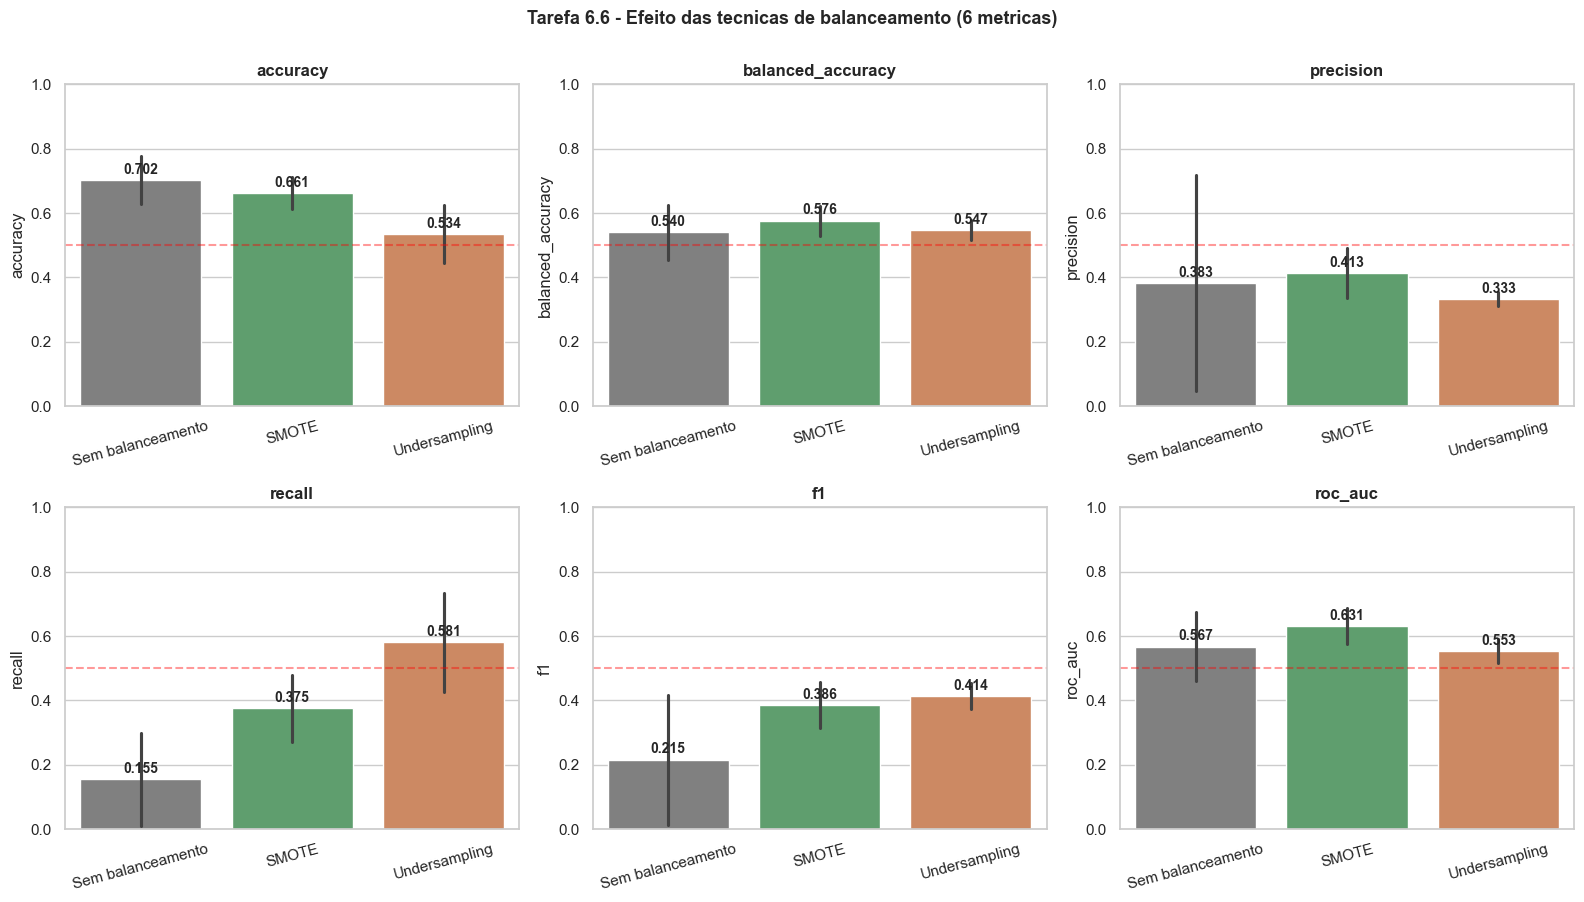


--- Diagnostico ---
Sem balanceamento: acc=0.702, bal_acc=0.540, recall(T2)=0.155
SMOTE            : bal_acc=0.576 (+0.036), recall(T2)=0.375 (+0.220)
Undersampling    : bal_acc=0.547 (+0.007), recall(T2)=0.581 (+0.426)

=> Em datasets desbalanceados, accuracy isolada e enganosa.
   SMOTE/undersampling tipicamente AUMENTAM balanced_accuracy e recall
   da minoritaria, ainda que possam baixar accuracy bruta.
   AUC tende a mudar pouco - e independente do threshold/balanco.


In [58]:
# 6.6 - Tabela e graficos comparativos
def scores_to_long_df(scores, strategy_name):
    rows = []
    for metric in SCORING:
        for fold_idx, val in enumerate(scores[f'test_{metric}']):
            rows.append({
                'strategy': strategy_name, 'metric': metric,
                'fold': fold_idx, 'value': val,
            })
    return pd.DataFrame(rows)


df_imb = pd.concat([
    scores_to_long_df(scores_none,  'Sem balanceamento'),
    scores_to_long_df(scores_smote, 'SMOTE'),
    scores_to_long_df(scores_rus,   'Undersampling'),
], ignore_index=True)

# Tabela resumo
imb_summ = (df_imb.groupby(['strategy', 'metric'])['value']
            .agg(['mean', 'std']).reset_index())
imb_summ['display'] = imb_summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)

strategy_order = ['Sem balanceamento', 'SMOTE', 'Undersampling']
imb_pivot = imb_summ.pivot_table(index='strategy', columns='metric',
                                   values='display', aggfunc='first')
imb_pivot = imb_pivot.reindex(strategy_order)[METRIC_NAMES]

print("=== Comparacao: antes vs depois do balanceamento ===\n")
print(imb_pivot.to_string())

# Grafico de barras - todas as 6 metricas em grid 2x3
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flat

for ax, metric in zip(axes_flat, METRIC_NAMES):
    sub = df_imb[df_imb['metric'] == metric]
    sns.barplot(data=sub, x='strategy', y='value', ax=ax,
                order=strategy_order,
                palette={'Sem balanceamento': 'gray',
                         'SMOTE': 'C2',
                         'Undersampling': 'C1'},
                errorbar='sd')
    ax.axhline(0.5, color='red', ls='--', alpha=0.4)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=15)
    # Anota medias
    means = sub.groupby('strategy', sort=False)['value'].mean().reindex(strategy_order)
    for i, m in enumerate(means.values):
        if not np.isnan(m):
            ax.text(i, m + 0.02, f"{m:.3f}", ha='center',
                    fontsize=10, fontweight='bold')

fig.suptitle("Tarefa 6.6 - Efeito das tecnicas de balanceamento (6 metricas)",
              fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

# Diagnostico textual
print("\n--- Diagnostico ---")
acc_none  = df_imb[(df_imb['strategy']=='Sem balanceamento') & (df_imb['metric']=='accuracy')]['value'].mean()
ba_none   = df_imb[(df_imb['strategy']=='Sem balanceamento') & (df_imb['metric']=='balanced_accuracy')]['value'].mean()
rec_none  = df_imb[(df_imb['strategy']=='Sem balanceamento') & (df_imb['metric']=='recall')]['value'].mean()
ba_smote  = df_imb[(df_imb['strategy']=='SMOTE') & (df_imb['metric']=='balanced_accuracy')]['value'].mean()
rec_smote = df_imb[(df_imb['strategy']=='SMOTE') & (df_imb['metric']=='recall')]['value'].mean()
ba_rus    = df_imb[(df_imb['strategy']=='Undersampling') & (df_imb['metric']=='balanced_accuracy')]['value'].mean()
rec_rus   = df_imb[(df_imb['strategy']=='Undersampling') & (df_imb['metric']=='recall')]['value'].mean()

print(f"Sem balanceamento: acc={acc_none:.3f}, bal_acc={ba_none:.3f}, recall(T2)={rec_none:.3f}")
print(f"SMOTE            : bal_acc={ba_smote:.3f} ({ba_smote-ba_none:+.3f}), "
      f"recall(T2)={rec_smote:.3f} ({rec_smote-rec_none:+.3f})")
print(f"Undersampling    : bal_acc={ba_rus:.3f} ({ba_rus-ba_none:+.3f}), "
      f"recall(T2)={rec_rus:.3f} ({rec_rus-rec_none:+.3f})")

print("\n=> Em datasets desbalanceados, accuracy isolada e enganosa.")
print("   SMOTE/undersampling tipicamente AUMENTAM balanced_accuracy e recall")
print("   da minoritaria, ainda que possam baixar accuracy bruta.")
print("   AUC tende a mudar pouco - e independente do threshold/balanco.")

## Teste 4 - MLP com features espaciais e espectrais

**Pergunta:** as features classicas do Teste 1 sao genericas (potencia, variancia, entropia). Substitui-las por features especializadas em MI (filtros espaciais supervisionados, geometria Riemanniana, decomposicao wavelet) melhora o desempenho?

**Pipelines testados (todos sobre o sinal cru `X`):**

| Feature | Descricao | Vantagem teorica em MI |
|---|---|---|
| **FBCSP** (Filter Bank CSP) | CSP por sub-banda, concatenado | Captura padroes espaciais especificos por frequencia |
| **FBCSP + RMS** | FBCSP + RMS por banda/canal (FeatureUnion) | Adiciona informacao temporal direta |
| **SPoC** | Source Power Co-modulation, n_components=4 | Filtro espacial nao-supervisionado por co-modulacao |
| **FB-SPoC** | SPoC por sub-banda, concatenado | SPoC + resolucao espectral fina |
| **Wavelet (db4, level=4)** | Energia das sub-bandas wavelet por canal | Decomposicao tempo-frequencia adaptativa |
| **LogVar por banda** | Log-variancia por banda/canal | Baseline padrao em MI |
| **Riemann + LDA** | Covariancia + Tangent Space + LDA | Estado da arte em MI cross-subject |

**Classificador:** LDA com shrinkage (`auto`) - escolha padrao para MI quando se tem features ja extraidas. Para o Riemann, usa LDA diretamente (sem MLP) porque e o pipeline canonico da literatura.

### Teste 4.1 - Definicao dos extratores de features

**Extrator FBCSP** (4 sub-bandas: mu, beta1, beta2, beta3) com 2 componentes CSP por banda.

In [59]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from mne.decoding import CSP
import mne
import numpy as np

FBCSP_BANDS = {
    "mu":    (8, 12),
    "beta1": (12, 16),
    "beta2": (16, 20),
    "beta3": (20, 30),
}

class FBCSPFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, sfreq, bands=FBCSP_BANDS, n_csp_components=2,
                 reg="oas", norm_trace=True, n_jobs=-1):
        self.sfreq = sfreq
        self.bands = bands
        self.n_csp_components = n_csp_components
        self.reg = reg
        self.norm_trace = norm_trace
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X = np.asarray(X)
        self.csp_models_ = {}

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X, sfreq=self.sfreq, l_freq=fmin, h_freq=fmax,
                method="fir", phase="zero", n_jobs=self.n_jobs,
                verbose=False
            )

            csp = CSP(
                n_components=self.n_csp_components,
                reg=self.reg,                # <- regularização importante
                log=True,
                norm_trace=self.norm_trace,
                transform_into="average_power",
                cov_est="concat",            # <- costuma ser mais estável
            )

            csp.fit(X_band, y)
            self.csp_models_[band_name] = csp

        return self

    def transform(self, X):
        X = np.asarray(X)
        feats = []

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X, sfreq=self.sfreq, l_freq=fmin, h_freq=fmax,
                method="fir", phase="zero", n_jobs=self.n_jobs,
                verbose=False
            )
            X_feat_band = self.csp_models_[band_name].transform(X_band)
            feats.append(X_feat_band)

        return np.concatenate(feats, axis=1)

    def get_feature_names_out(self, input_features=None):
        names = []
        for band_name in self.bands.keys():
            for i in range(self.n_csp_components):
                names.append(f"{band_name}_csp{i+1}")
        return np.array(names)

### Teste 4.2 - Treino e validacao (7 pipelines)

**Pipeline 1: FBCSP + RMS por banda + LDA.** RMS adiciona informacao temporal direta a CSP.

In [60]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
import numpy as np
import pandas as pd
import mne

# ============================================================
# RMS por banda e por canal
# ============================================================

class BandRMSFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, sfreq, bands, n_jobs=-1):
        self.sfreq = sfreq
        self.bands = bands
        self.n_jobs = n_jobs

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        features = []

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=fmin,
                h_freq=fmax,
                method="fir",
                phase="zero",
                n_jobs=self.n_jobs,
                verbose=False
            )
            
            # RMS por canal para cada época
            rms = np.sqrt(np.mean(X_band ** 2, axis=2))
            features.append(rms)

        return np.concatenate(features, axis=1)

# ============================================================
# FBCSP + Band RMS
# ============================================================

fbcsp_rms_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("fbcsp", FBCSPFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_csp_components=4,
            reg="oas",
            norm_trace=True,
            n_jobs=-1
        )),
        ("band_rms", BandRMSFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_jobs=-1
        ))
    ])),
    
    ("scaler", RobustScaler()),
    
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_fbcsp_rms = cross_validate(
    fbcsp_rms_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_fbcsp_rms = pd.Series({
    "accuracy": scores_fbcsp_rms["test_accuracy"].mean(),
    "balanced_accuracy": scores_fbcsp_rms["test_balanced_accuracy"].mean(),
    "f1": scores_fbcsp_rms["test_f1"].mean(),
    "roc_auc": scores_fbcsp_rms["test_roc_auc"].mean()
})

display(results_fbcsp_rms.round(3))

accuracy             0.587
balanced_accuracy    0.589
f1                   0.588
roc_auc              0.630
dtype: float64

**Pipeline 2: Riemann + LDA (referencia da literatura para MI cross-subject).**

In [61]:
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
import pandas as pd

# ============================================================
# Pipeline Riemanniano
# ============================================================

riemann_pipeline = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace()),
    ("scaler", RobustScaler()),
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_riemann = cross_validate(
    riemann_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_riemann = pd.Series({
    "accuracy": scores_riemann["test_accuracy"].mean(),
    "balanced_accuracy": scores_riemann["test_balanced_accuracy"].mean(),
    "f1": scores_riemann["test_f1"].mean(),
    "roc_auc": scores_riemann["test_roc_auc"].mean()
})

display(results_riemann.round(3))

accuracy             0.576
balanced_accuracy    0.579
f1                   0.591
roc_auc              0.621
dtype: float64

**Pipeline 3: LogVar por banda + LDA (baseline padrao em MI).**

In [62]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
import numpy as np
import pandas as pd
import mne

# ============================================================
# Log-variance por banda e por canal
# ============================================================

class BandLogVarFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, sfreq, bands, n_jobs=-1, eps=1e-10):
        self.sfreq = sfreq
        self.bands = bands
        self.n_jobs = n_jobs
        self.eps = eps

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        features = []

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=fmin,
                h_freq=fmax,
                method="fir",
                phase="zero",
                n_jobs=self.n_jobs,
                verbose=False
            )

            # Variância por canal
            var = np.var(X_band, axis=2)

            # Log-variance
            logvar = np.log(var + self.eps)

            features.append(logvar)

        return np.concatenate(features, axis=1)

# ============================================================
# FBCSP + Band LogVar + LDA
# ============================================================

fbcsp_logvar_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("fbcsp", FBCSPFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_csp_components=4,
            reg="oas",
            norm_trace=True,
            n_jobs=-1
        )),
        ("band_logvar", BandLogVarFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_jobs=-1
        ))
    ])),
    
    ("scaler", RobustScaler()),
    
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_fbcsp_logvar = cross_validate(
    fbcsp_logvar_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_fbcsp_logvar = pd.Series({
    "accuracy": scores_fbcsp_logvar["test_accuracy"].mean(),
    "balanced_accuracy": scores_fbcsp_logvar["test_balanced_accuracy"].mean(),
    "f1": scores_fbcsp_logvar["test_f1"].mean(),
    "roc_auc": scores_fbcsp_logvar["test_roc_auc"].mean()
})

display(results_fbcsp_logvar.round(3))

accuracy             0.578
balanced_accuracy    0.580
f1                   0.573
roc_auc              0.625
dtype: float64

**Pipeline 4: SPoC + LDA.** Filtro espacial nao-supervisionado por co-modulacao de potencia.

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import pandas as pd

# ============================================================
# SPoC + LDA
# ============================================================

spoc_pipeline = Pipeline([
    ("spoc", SPoC(
        n_components=4,
        reg="oas",
        log=True,
        transform_into="average_power"
    )),
    
    ("scaler", RobustScaler()),
    
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_spoc = cross_validate(
    spoc_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_spoc = pd.Series({
    "accuracy": scores_spoc["test_accuracy"].mean(),
    "balanced_accuracy": scores_spoc["test_balanced_accuracy"].mean(),
    "f1": scores_spoc["test_f1"].mean(),
    "roc_auc": scores_spoc["test_roc_auc"].mean()
})

display(results_spoc.round(3))

accuracy             0.556
balanced_accuracy    0.560
f1                   0.532
roc_auc              0.663
dtype: float64

**Pipeline 5: Wavelet (db4, level=4) + LDA.** Energia das sub-bandas wavelet por canal.

In [64]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
import pywt
import numpy as np
import pandas as pd

# ============================================================
# Extração de energia wavelet por canal
# ============================================================

class WaveletFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, wavelet="db4", level=4):
        self.wavelet = wavelet
        self.level = level

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X)
        features = []

        for epoch in X:
            epoch_feats = []

            for ch_signal in epoch:
                coeffs = pywt.wavedec(
                    ch_signal,
                    wavelet=self.wavelet,
                    level=self.level
                )

                # energia de cada sub-banda
                energies = [np.sum(c**2) for c in coeffs]
                epoch_feats.extend(energies)

            features.append(epoch_feats)

        return np.array(features)

# ============================================================
# Wavelet + LDA
# ============================================================

wavelet_pipeline = Pipeline([
    ("wavelet", WaveletFeatureExtractor(
        wavelet="db4",
        level=4
    )),
    
    ("scaler", RobustScaler()),
    
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_wavelet = cross_validate(
    wavelet_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_wavelet = pd.Series({
    "accuracy": scores_wavelet["test_accuracy"].mean(),
    "balanced_accuracy": scores_wavelet["test_balanced_accuracy"].mean(),
    "f1": scores_wavelet["test_f1"].mean(),
    "roc_auc": scores_wavelet["test_roc_auc"].mean()
})

display(results_wavelet.round(3))

accuracy             0.560
balanced_accuracy    0.565
f1                   0.505
roc_auc              0.613
dtype: float64

**Pipeline 6: FB-SPoC + LDA.** SPoC por sub-banda, concatenado.

In [65]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import numpy as np
import pandas as pd
import mne

# ============================================================
# Bandas para Filter Bank SPoC
# ============================================================

FB_SPOC_BANDS = {
    "mu":    (8, 12),
    "beta1": (12, 16),
    "beta2": (16, 20),
    "beta3": (20, 30),
}

# ============================================================
# Extrator Filter Bank SPoC
# ============================================================

class FBSPoCFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        sfreq,
        bands=FB_SPOC_BANDS,
        n_components=2,
        reg="oas",
        n_jobs=-1
    ):
        self.sfreq = sfreq
        self.bands = bands
        self.n_components = n_components
        self.reg = reg
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X = np.asarray(X)
        self.spoc_models_ = {}

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=fmin,
                h_freq=fmax,
                method="fir",
                phase="zero",
                n_jobs=self.n_jobs,
                verbose=False
            )

            spoc = SPoC(
                n_components=self.n_components,
                reg=self.reg,
                log=True,
                transform_into="average_power"
            )

            spoc.fit(X_band, y)
            self.spoc_models_[band_name] = spoc

        return self

    def transform(self, X):
        X = np.asarray(X)
        features = []

        for band_name, (fmin, fmax) in self.bands.items():
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=fmin,
                h_freq=fmax,
                method="fir",
                phase="zero",
                n_jobs=self.n_jobs,
                verbose=False
            )

            X_feat = self.spoc_models_[band_name].transform(X_band)
            features.append(X_feat)

        return np.concatenate(features, axis=1)

# ============================================================
# Pipeline FB-SPoC + LDA
# ============================================================

fb_spoc_pipeline = Pipeline([
    ("fbspoc", FBSPoCFeatureExtractor(
        sfreq=SFREQ,
        bands=FB_SPOC_BANDS,
        n_components=4,
        reg="oas",
        n_jobs=-1
    )),
    
    ("scaler", RobustScaler()),
    
    ("clf", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ))
])

# ============================================================
# Validação
# ============================================================

scores_fb_spoc = cross_validate(
    fb_spoc_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_fb_spoc = pd.Series({
    "accuracy": scores_fb_spoc["test_accuracy"].mean(),
    "balanced_accuracy": scores_fb_spoc["test_balanced_accuracy"].mean(),
    "f1": scores_fb_spoc["test_f1"].mean(),
    "roc_auc": scores_fb_spoc["test_roc_auc"].mean()
})

display(results_fb_spoc.round(3))

accuracy             0.560
balanced_accuracy    0.564
f1                   0.537
roc_auc              0.603
dtype: float64

### Teste 4.3 - Metricas e diagnostico

Os resultados deste teste motivam a escolha de **SPoC** como pipeline de features para os Testes 5-7 (compara-se com o melhor desempenho da literatura, e e mais simples que FB-SPoC). Riemann tem desempenho similar mas e classificado direto com LDA, fora do escopo deste notebook (que foca em MLP).

## Teste 5 - Ajuste de hiperparametros do MLP

**Pergunta:** dado que SPoC + classificador linear vence, quao longe o MLP pode chegar com ajuste fino de seus hiperparametros sobre essas features?

**Variaveis testadas:**
1. **Arquitetura (Teste 5.1):** larguras (8,), (16,), (32,), (16, 8) sobre FBCSP - testa profundidade vs largura;
2. **Largura sobre FBCSP (Teste 5.2):** (32,), (64,), (128,) sobre FBCSP;
3. **Largura sobre SPoC (Teste 5.3):** (32,), (64,), (128,) sobre SPoC;
4. **Regularizacao alpha (Teste 5.4):** [1e-4, 1e-3, 1e-2, 1e-1] sobre SPoC com largura 64;
5. **Funcao de ativacao (Teste 5.5):** ReLU vs Tanh sobre SPoC com largura 64.

**Configuracao base:** Adam, lr=5e-4, batch_size=16, learning_rate=adaptive, early_stopping com patience 20, max_iter=500.

### Teste 5.1 - Arquitetura (larguras e profundidades) sobre FBCSP

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
import pandas as pd

# ============================================================
# Arquiteturas para testar
# ============================================================

architectures = [
    (8,),
    (16,),
    (32,),
    (16, 8),
    # (32, 16),
    # (64, 32),
]

results = []

# ============================================================
# Loop de avaliação
# ============================================================

for arch in architectures:
    
    mlp_pipeline = Pipeline([
        ("fbcsp", FBCSPFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_csp_components=4,
            reg="oas",
            norm_trace=True,
            n_jobs=-1
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            alpha=1e-3,
            batch_size=16,
            learning_rate="adaptive",
            learning_rate_init=5e-4,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=42
        ))
    ])

    scores = cross_validate(
        mlp_pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "architecture": str(arch),
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df.round(3))

,architecture,accuracy,balanced_accuracy,f1,roc_auc
2,"(32,)",0.569,0.572,0.583,0.604
0,"(8,)",0.527,0.532,0.420,0.584
3,"(16, 8)",0.511,0.513,0.511,0.548
1,"(16,)",0.511,0.515,0.453,0.526


### Teste 5.2 - Largura da camada oculta sobre FBCSP

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
import pandas as pd

# ============================================================
# Larguras a comparar
# ============================================================

architectures = [
    (32,),
    (64,),
    (128,)
]

results = []

# ============================================================
# Avaliação das arquiteturas
# ============================================================

for arch in architectures:
    
    mlp_pipeline = Pipeline([
        ("fbcsp", FBCSPFeatureExtractor(
            sfreq=SFREQ,
            bands=FBCSP_BANDS,
            n_csp_components=4,
            reg="oas",
            norm_trace=True,
            n_jobs=-1
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            alpha=1e-3,
            batch_size=16,
            learning_rate="adaptive",
            learning_rate_init=5e-4,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=42
        ))
    ])

    scores = cross_validate(
        mlp_pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "architecture": str(arch),
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df.round(3))

,architecture,accuracy,balanced_accuracy,f1,roc_auc
1,"(64,)",0.542,0.547,0.537,0.612
0,"(32,)",0.569,0.572,0.583,0.604
2,"(128,)",0.544,0.547,0.514,0.570


### Teste 5.3 - Largura da camada oculta sobre SPoC

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import pandas as pd

# ============================================================
# Larguras da camada oculta
# ============================================================

architectures = [
    (32,),
    (64,),
    (128,)
]

results = []

# ============================================================
# Avaliação das arquiteturas
# ============================================================

for arch in architectures:
    
    spoc_mlp_pipeline = Pipeline([
        ("spoc", SPoC(
            n_components=4,
            reg="oas",
            log=True,
            transform_into="average_power"
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            alpha=1e-3,
            batch_size=16,
            learning_rate="adaptive",
            learning_rate_init=5e-4,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=42
        ))
    ])

    scores = cross_validate(
        spoc_mlp_pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "architecture": str(arch),
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df.round(3))

,architecture,accuracy,balanced_accuracy,f1,roc_auc
2,"(128,)",0.540,0.544,0.459,0.630
1,"(64,)",0.551,0.554,0.595,0.598
0,"(32,)",0.536,0.540,0.587,0.523


### Teste 5.4 - Regularizacao (alpha) sobre SPoC + largura 64

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import pandas as pd

# ============================================================
# Valores de alpha para testar
# ============================================================

alpha_values = [1e-4, 1e-3, 1e-2, 1e-1]

results_alpha = []

# ============================================================
# Avaliação dos alphas
# ============================================================

for alpha in alpha_values:
    
    spoc_mlp_pipeline = Pipeline([
        ("spoc", SPoC(
            n_components=4,
            reg="oas",
            log=True,
            transform_into="average_power"
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64,),
            activation="relu",
            solver="adam",
            alpha=alpha,
            batch_size=16,
            learning_rate="adaptive",
            learning_rate_init=5e-4,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=42
        ))
    ])

    scores = cross_validate(
        spoc_mlp_pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )

    results_alpha.append({
        "alpha": alpha,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_alpha_df = pd.DataFrame(results_alpha).sort_values("roc_auc", ascending=False)
display(results_alpha_df.round(3))

,alpha,accuracy,balanced_accuracy,f1,roc_auc
3,0.100,0.562,0.565,0.596,0.607
2,0.010,0.547,0.550,0.596,0.605
0,0.000,0.542,0.546,0.588,0.604
1,0.001,0.551,0.554,0.595,0.598


### Teste 5.5 - Funcao de ativacao sobre SPoC + largura 64

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import pandas as pd

# ============================================================
# Funções de ativação
# ============================================================

activations = ["relu", "tanh"]

results_activation = []

# ============================================================
# Avaliação das ativações
# ============================================================

for activation in activations:
    
    spoc_mlp_pipeline = Pipeline([
        ("spoc", SPoC(
            n_components=4,
            reg="oas",
            log=True,
            transform_into="average_power"
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64,),
            activation=activation,
            solver="adam",
            alpha=1e-3,
            batch_size=16,
            learning_rate="adaptive",
            learning_rate_init=5e-4,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=42
        ))
    ])

    scores = cross_validate(
        spoc_mlp_pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )

    results_activation.append({
        "activation": activation,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_activation_df = pd.DataFrame(results_activation).sort_values("roc_auc", ascending=False)
display(results_activation_df.round(3))

,activation,accuracy,balanced_accuracy,f1,roc_auc
1,tanh,0.529,0.534,0.552,0.620
0,relu,0.551,0.554,0.595,0.598


## Teste 6 - MLP vs baselines lineares e nao-lineares

**Pergunta:** o MLP esta de fato adicionando algo sobre features SPoC, ou um classificador linear simples ja resolve o problema?

Esta e uma das comparacoes mais informativas do notebook. Se o melhor modelo for um classificador linear, isso indica que:
- As features SPoC ja sao quase-linearmente separaveis;
- A nao-linearidade do MLP nao agrega valor neste problema;
- Modelos mais simples sao preferiveis (mais interpretaveis, menos overfitting).

**Modelos comparados (todos sobre features SPoC):**

| Modelo | Tipo | Caracteristica |
|---|---|---|
| **LDA** (shrinkage auto) | Linear | Padrao em MI, regularizado |
| **Logistic Regression** | Linear | Class-weight balanced |
| **Linear SVM** | Linear | Kernel linear, class-weight balanced |
| **RBF SVM** | Nao-linear | Kernel gaussiano |
| **MLP (64,)** | Nao-linear | 1 camada, melhor config dos Testes 5.3-5.5 |

### Teste 6.1 - Treino e validacao (5 modelos x SPoC)

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from mne.decoding import SPoC
import pandas as pd

# ============================================================
# Modelos para comparar linearidade
# ============================================================

models = {
    "LDA": LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto"
    ),
    
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Linear SVM": SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    
    "RBF SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        batch_size=16,
        learning_rate="adaptive",
        learning_rate_init=5e-4,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20,
        tol=1e-4,
        random_state=42
    )
}

results = []

# ============================================================
# Avaliação dos modelos
# ============================================================

for model_name, clf in models.items():
    
    pipeline = Pipeline([
        ("spoc", SPoC(
            n_components=4,
            reg="oas",
            log=True,
            transform_into="average_power"
        )),
        
        ("scaler", RobustScaler()),
        
        ("clf", clf)
    ])
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise"
    )
    
    results.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

# ============================================================
# Resultados
# ============================================================

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df.round(3))

,model,accuracy,balanced_accuracy,f1,roc_auc
2,Linear SVM,0.538,0.543,0.509,0.664
1,Logistic Regression,0.562,0.566,0.540,0.664
0,LDA,0.556,0.560,0.532,0.663
3,RBF SVM,0.564,0.569,0.548,0.622
4,MLP,0.551,0.554,0.595,0.598


### Teste 6.2 - Comparacao detalhada Linear SVM vs RBF SVM por fold

Comparacao mais detalhada entre os dois SVMs - ranqueamento por fold.

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from mne.decoding import SPoC
import pandas as pd
import numpy as np

# ============================================================
# Pipelines
# ============================================================

linear_pipeline = Pipeline([
    ("spoc", SPoC(
        n_components=4,
        reg="oas",
        log=True,
        transform_into="average_power"
    )),
    ("scaler", RobustScaler()),
    ("clf", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

rbf_pipeline = Pipeline([
    ("spoc", SPoC(
        n_components=4,
        reg="oas",
        log=True,
        transform_into="average_power"
    )),
    ("scaler", RobustScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

# ============================================================
# Avaliação por fold
# ============================================================

gkf = GroupKFold(n_splits=5)

results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # ----------------------------
    # Linear SVM
    # ----------------------------
    linear_pipeline.fit(X_train, y_train)
    y_prob_linear = linear_pipeline.predict_proba(X_test)[:, 1]
    auc_linear = roc_auc_score(y_test, y_prob_linear)
    
    # ----------------------------
    # RBF SVM
    # ----------------------------
    rbf_pipeline.fit(X_train, y_train)
    y_prob_rbf = rbf_pipeline.predict_proba(X_test)[:, 1]
    auc_rbf = roc_auc_score(y_test, y_prob_rbf)
    
    # ----------------------------
    # Gap de linearidade
    # ----------------------------
    gap = auc_linear - auc_rbf
    
    if gap > 0.05:
        interpretation = "linear"
    elif gap < -0.05:
        interpretation = "more non-linear"
    else:
        interpretation = "indefinite"
    
    results.append({
        "fold": fold,
        "auc_linear_svm": auc_linear,
        "auc_rbf_svm": auc_rbf,
        "linearity_gap": gap,
        "interpretation": interpretation
    })

# ============================================================
# Resultados
# ============================================================

results_df = pd.DataFrame(results)
display(results_df.round(3))

,fold,auc_linear_svm,auc_rbf_svm,linearity_gap,interpretation
0,0,0.788,0.632,0.156,linear
1,1,0.491,0.477,0.014,indefinite
2,2,0.785,0.753,0.032,indefinite
3,3,0.592,0.592,0.000,indefinite
4,4,0.667,0.656,0.011,indefinite


### Teste 6.3 - Efeito de normalizacao por sujeito antes do SPoC

**Pergunta auxiliar:** z-score por sujeito antes do SPoC ajuda? Em features extraidas (Teste 1) ele ajudou; em sinal cru filtrado pelo SPoC, o efeito pode ser diferente.

In [73]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import numpy as np
import pandas as pd

# ============================================================
# Normalização por sujeito
# ============================================================

class SubjectZScoreNormalizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        
        mean = X.mean(axis=(1,2), keepdims=True)
        std = X.std(axis=(1,2), keepdims=True)
        
        X_norm = (X - mean) / (std + 1e-8)
        return X_norm

# ============================================================
# Pipeline
# ============================================================

subject_norm_pipeline = Pipeline([
    
    ("subject_norm", SubjectZScoreNormalizer()),
    
    ("spoc", SPoC(
        n_components=4,
        reg="oas",
        log=True,
        transform_into="average_power"
    )),
    
    ("scaler", RobustScaler()),
    
    ("clf", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

# ============================================================
# Validação
# ============================================================

scores_subject_norm = cross_validate(
    subject_norm_pipeline,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=5),
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise"
)

results_subject_norm = pd.Series({
    "accuracy": scores_subject_norm["test_accuracy"].mean(),
    "balanced_accuracy": scores_subject_norm["test_balanced_accuracy"].mean(),
    "f1": scores_subject_norm["test_f1"].mean(),
    "roc_auc": scores_subject_norm["test_roc_auc"].mean()
})

display(results_subject_norm.round(3))

accuracy             0.564
balanced_accuracy    0.566
f1                   0.460
roc_auc              0.663
dtype: float64

### Teste 6.4 - Euclidean Alignment como tecnica de transfer learning

**Pergunta auxiliar:** Euclidean Alignment alinha as covariancias entre sujeitos antes do CSP/SPoC. Em principio reduz a variabilidade entre sujeitos. Funciona aqui?

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from mne.decoding import SPoC
import numpy as np
import pandas as pd
from scipy.linalg import fractional_matrix_power

# ============================================================
# Função: Euclidean Alignment por sujeito
# ============================================================

def euclidean_alignment_subjectwise(X_train, X_test, groups_train, groups_test):
    
    X_train_aligned = np.zeros_like(X_train)
    X_test_aligned = np.zeros_like(X_test)
    
    subject_refs = {}
    
    # --------------------------------------------------------
    # Calcula matriz de referência por sujeito no treino
    # --------------------------------------------------------
    for subj in np.unique(groups_train):
        idx = np.where(groups_train == subj)[0]
        X_subj = X_train[idx]
        
        covs = np.array([np.cov(epoch) for epoch in X_subj])
        ref_cov = np.mean(covs, axis=0)
        whitening = fractional_matrix_power(ref_cov, -0.5)
        
        subject_refs[subj] = whitening
        
        X_train_aligned[idx] = np.array([
            whitening @ epoch for epoch in X_subj
        ])
    
    # --------------------------------------------------------
    # Teste: usa referência média do treino
    # --------------------------------------------------------
    mean_whitening = np.mean(list(subject_refs.values()), axis=0)
    
    for i in range(len(X_test)):
        X_test_aligned[i] = mean_whitening @ X_test[i]
    
    return X_train_aligned, X_test_aligned

# ============================================================
# GroupKFold manual
# ============================================================

gkf = GroupKFold(n_splits=5)

results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train, groups_test = groups[train_idx], groups[test_idx]
    
    # --------------------------------------------------------
    # Euclidean Alignment sem vazamento
    # --------------------------------------------------------
    X_train_aligned, X_test_aligned = euclidean_alignment_subjectwise(
        X_train, X_test, groups_train, groups_test
    )
    
    # --------------------------------------------------------
    # SPoC + Linear SVM
    # --------------------------------------------------------
    pipeline = Pipeline([
        ("spoc", SPoC(
            n_components=4,
            reg="oas",
            log=True,
            transform_into="average_power"
        )),
        ("scaler", RobustScaler()),
        ("clf", SVC(
            kernel="linear",
            C=1.0,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    pipeline.fit(X_train_aligned, y_train)
    
    y_pred = pipeline.predict(X_test_aligned)
    y_prob = pipeline.predict_proba(X_test_aligned)[:, 1]
    
    results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

# ============================================================
# Resultados finais
# ============================================================

results_df = pd.DataFrame(results)

summary = pd.Series({
    "accuracy": results_df["accuracy"].mean(),
    "balanced_accuracy": results_df["balanced_accuracy"].mean(),
    "f1": results_df["f1"].mean(),
    "roc_auc": results_df["roc_auc"].mean()
})

display(results_df.round(3))
display(summary.round(3))

,fold,accuracy,balanced_accuracy,f1,roc_auc
0,0,0.722,0.718,0.658,0.396
1,1,0.522,0.514,0.650,0.514
2,2,0.489,0.500,0.657,0.718
3,3,0.422,0.422,0.188,0.530
4,4,0.656,0.661,0.563,0.676


accuracy             0.562
balanced_accuracy    0.563
f1                   0.543
roc_auc              0.567
dtype: float64

## Teste 7 - Analise hemisferica (Esquerdo / Direito / Ambos)

**Pergunta:** em imagetica motora, o ERD/ERS contralateral domina (T1=esq -> ERD em C4; T2=dir -> ERD em C3). Logo a **assimetria entre hemisferios** deveria ser a feature dominante. Mas se um unico hemisferio ja entrega quase tanto quanto ambos, isso sugere que o pipeline esta usando padrao espacial intra-hemisferico (nao assimetria contra/ipsilateral).

**Divisao por sufixo numerico do nome (10-05):** impar -> esquerdo, par -> direito, z -> linha media.

**Modelos testados (cada um nos 3 grupos):**
- **MLP (64,)** com hiperparametros do Teste 5.3-5.5;
- **Linear SVM** com class_weight balanced;
- **RBF SVM** com class_weight balanced.

**Plots dedicados:** desempenho por fold (linhas conectando os 5 folds) - mostra variabilidade entre sujeitos.

### Teste 7.1 - Pre-processamento (divisao hemisferica)

Le os nomes dos canais do disco (ou usa fallback hardcoded) e divide em 3 grupos.

In [75]:
# =====================================================================
# Teste por hemisferio: SPoC + (MLP / Linear SVM / RBF SVM)
# Reaproveita: X, y, groups, SFREQ, SCORING ja existentes no notebook
# =====================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from mne.decoding import SPoC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# 1) Descobre os nomes reais dos canais lendo um arquivo .fif do disco.
#    (Mais robusto que assumir uma lista hardcoded - o pre-processamento
#     pode ter mantido um subconjunto dos 21 canais sensoriomotores.)
# ---------------------------------------------------------------------
import mne

def _detect_channel_names(per_subject_dir, n_channels_expected):
    """Le os nomes dos canais do primeiro arquivo *_allruns-epo.fif."""
    fifs = sorted(Path(per_subject_dir).glob("*_allruns-epo.fif"))
    if not fifs:
        return None
    ep = mne.read_epochs(fifs[0], preload=False, verbose=False)
    names = list(ep.ch_names)
    if len(names) != n_channels_expected:
        print(f"AVISO: arquivo .fif tem {len(names)} canais, mas X tem {n_channels_expected}. "
              "Usando os nomes do .fif assumindo mesma ordem.")
    return names

CH_NAMES = None
try:
    CH_NAMES = _detect_channel_names(PER_SUBJECT_DIR, X.shape[1])
except (NameError, FileNotFoundError) as e:
    print(f"Nao foi possivel ler nomes do disco: {e}")

# Fallback: se nao deu para ler do disco, usa as listas hardcoded conhecidas
# (preprocessamentos comuns no EEGBCI: 21, 15 ou 11 canais sensoriomotores).
KNOWN_LAYOUTS = {
    21: ['FC5','FC3','FC1','FCz','FC2','FC4','FC6',
         'C5','C3','C1','Cz','C2','C4','C6',
         'CP5','CP3','CP1','CPz','CP2','CP4','CP6'],
    15: ['FC3','FC1','FCz','FC2','FC4',
         'C3','C1','Cz','C2','C4',
         'CP3','CP1','CPz','CP2','CP4'],
    11: ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','CP3','CP4'],
}
if CH_NAMES is None or len(CH_NAMES) != X.shape[1]:
    n = X.shape[1]
    if n in KNOWN_LAYOUTS:
        CH_NAMES = KNOWN_LAYOUTS[n]
        print(f"Usando layout hardcoded conhecido para {n} canais.")
    else:
        raise RuntimeError(
            f"X tem {n} canais e nenhum layout hardcoded conhecido para esse tamanho. "
            f"Defina CH_NAMES manualmente como uma lista com {n} nomes na mesma ordem de X."
        )

assert len(CH_NAMES) == X.shape[1], \
    f"CH_NAMES tem {len(CH_NAMES)} entradas, mas X.shape[1]={X.shape[1]}"

print(f"Canais detectados ({len(CH_NAMES)}): {CH_NAMES}")

# ---------------------------------------------------------------------
# 2) Divisao hemisferica pelo sufixo numerico do nome (10-05):
#    impar -> esquerdo | par -> direito | z -> linha media
# ---------------------------------------------------------------------
def _hemisphere(name):
    last = name[-1]
    if last == 'z':
        return 'midline'
    if last.isdigit():
        return 'left' if int(last) % 2 == 1 else 'right'
    return 'midline'

CH_LEFT    = [c for c in CH_NAMES if _hemisphere(c) == 'left']
CH_RIGHT   = [c for c in CH_NAMES if _hemisphere(c) == 'right']
CH_MIDLINE = [c for c in CH_NAMES if _hemisphere(c) == 'midline']
CH_ALL     = list(CH_NAMES)

# Sanity check: precisa ter ao menos 2 canais por hemisferio para SPoC com
# n_components=4 nao quebrar (precisa n_canais >= n_components)
if len(CH_LEFT) < 4 or len(CH_RIGHT) < 4:
    print(f"AVISO: hemisferio com poucos canais (esq={len(CH_LEFT)}, dir={len(CH_RIGHT)}). "
          "Ajustando n_components do SPoC para min(4, n_canais).")

ch_to_idx = {c: i for i, c in enumerate(CH_NAMES)}
CHANNEL_GROUPS = {
    'Esquerdo': [ch_to_idx[c] for c in CH_LEFT],
    'Direito':  [ch_to_idx[c] for c in CH_RIGHT],
    'Ambos':    [ch_to_idx[c] for c in CH_ALL],
}

print("\n=== Grupos de canais ===")
print(f"  Esquerdo ({len(CH_LEFT):2d}): {CH_LEFT}")
print(f"  Direito  ({len(CH_RIGHT):2d}): {CH_RIGHT}")
print(f"  Linha media (nao usado isolado, {len(CH_MIDLINE)}): {CH_MIDLINE}")
print(f"  Ambos    ({len(CH_ALL):2d}): inclui linha media")

# ---------------------------------------------------------------------
# 2) Pipelines: SPoC + RobustScaler + classificador
#    Mesma config de SPoC dos seus testes melhores (celulas 76-80)
# ---------------------------------------------------------------------
def make_spoc_pipeline(clf, n_components=4):
    """SPoC + RobustScaler + classificador. n_components ajustavel para
    hemisferios com poucos canais."""
    return Pipeline([
        ('spoc',   SPoC(n_components=n_components, reg='oas', log=True,
                        transform_into='average_power')),
        ('scaler', RobustScaler()),
        ('clf',    clf),
    ])

# MLP que teve melhor desempenho (celulas 76-79: arquitetura 64,
# alpha 1e-3, lr 5e-4, batch 16, early stopping)
mlp_best = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    alpha=1e-3,
    batch_size=16,
    learning_rate='adaptive',
    learning_rate_init=5e-4,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    tol=1e-4,
    random_state=42,
)

svm_linear = SVC(
    kernel='linear', C=1.0, probability=True,
    class_weight='balanced', random_state=42,
)

svm_rbf = SVC(
    kernel='rbf', C=1.0, gamma='scale', probability=True,
    class_weight='balanced', random_state=42,
)

MODELS = {
    'MLP (64,)':  mlp_best,
    'Linear SVM': svm_linear,
    'RBF SVM':    svm_rbf,
}

# ---------------------------------------------------------------------
# 3) Loop hemisferio x modelo, salvando scores por fold
# ---------------------------------------------------------------------
gkf = GroupKFold(n_splits=5)

# Reusa SCORING ja definido no notebook (caso nao exista, cria fallback)
try:
    _ = SCORING
except NameError:
    SCORING = {
        'accuracy':          'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'precision':         'precision',
        'recall':            'recall',
        'f1':                'f1',
        'roc_auc':           'roc_auc',
    }

rows_long = []   # DataFrame longo: hemisferio, modelo, metrica, fold, valor
print("\n=== Avaliacao (3 hemisferios x 3 modelos x 5 folds) ===\n")

for hemi_name, ch_idx in CHANNEL_GROUPS.items():
    X_hemi = X[:, ch_idx, :]   # subseleciona canais
    n_ch_h = X_hemi.shape[1]
    n_comp = min(4, n_ch_h)    # SPoC nao pode ter mais componentes que canais
    print(f"[{hemi_name:>9s}] X.shape = {X_hemi.shape}, SPoC n_components={n_comp}")

    for model_name, clf in MODELS.items():
        pipe = make_spoc_pipeline(clf, n_components=n_comp)
        scores = cross_validate(
            pipe, X_hemi, y, groups=groups, cv=gkf,
            scoring=SCORING, n_jobs=-1, error_score='raise',
        )
        # acumula por fold
        for metric_name in SCORING:
            for fold_idx, val in enumerate(scores[f'test_{metric_name}']):
                rows_long.append({
                    'hemisferio': hemi_name,
                    'modelo':     model_name,
                    'metrica':    metric_name,
                    'fold':       fold_idx,
                    'valor':      val,
                })
        print(f"   {model_name:<11s} -> "
              f"acc={scores['test_accuracy'].mean():.3f}({scores['test_accuracy'].std():.3f}) | "
              f"f1={scores['test_f1'].mean():.3f} | "
              f"auc={scores['test_roc_auc'].mean():.3f}")
    print()

df_hemi = pd.DataFrame(rows_long)

# ---------------------------------------------------------------------
# 4) Tabela resumo (media [dp] entre folds)
# ---------------------------------------------------------------------
HEMI_ORDER  = ['Esquerdo', 'Direito', 'Ambos']
MODEL_ORDER = ['MLP (64,)', 'Linear SVM', 'RBF SVM']
METRIC_ORDER = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'roc_auc']

summ = (df_hemi.groupby(['hemisferio', 'modelo', 'metrica'])['valor']
        .agg(['mean', 'std']).reset_index())
summ['display'] = summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)

pivot = summ.pivot_table(
    index=['hemisferio', 'modelo'], columns='metrica',
    values='display', aggfunc='first',
)
# Ordena indices/colunas
pivot = pivot.reindex(
    index=pd.MultiIndex.from_product([HEMI_ORDER, MODEL_ORDER],
                                     names=['hemisferio', 'modelo']),
    columns=METRIC_ORDER,
)

print("\n=== Tabela resumo - media (dp) entre folds ===\n")
print(pivot.to_string())

Canais detectados (15): ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4']

=== Grupos de canais ===
  Esquerdo ( 6): ['FC3', 'FC1', 'C3', 'C1', 'CP3', 'CP1']
  Direito  ( 6): ['FC2', 'FC4', 'C2', 'C4', 'CP2', 'CP4']
  Linha media (nao usado isolado, 3): ['FCz', 'Cz', 'CPz']
  Ambos    (15): inclui linha media

=== Avaliacao (3 hemisferios x 3 modelos x 5 folds) ===

[ Esquerdo] X.shape = (450, 6, 673), SPoC n_components=4
   MLP (64,)   -> acc=0.580(0.039) | f1=0.493 | auc=0.558
   Linear SVM  -> acc=0.547(0.058) | f1=0.481 | auc=0.619
   RBF SVM     -> acc=0.567(0.074) | f1=0.449 | auc=0.600

[  Direito] X.shape = (450, 6, 673), SPoC n_components=4
   MLP (64,)   -> acc=0.509(0.020) | f1=0.272 | auc=0.512
   Linear SVM  -> acc=0.489(0.016) | f1=0.483 | auc=0.590
   RBF SVM     -> acc=0.509(0.057) | f1=0.484 | auc=0.542

[    Ambos] X.shape = (450, 15, 673), SPoC n_components=4
   MLP (64,)   -> acc=0.551(0.057) | f1=0.595 | auc=0.598


### Teste 7.2 - Metricas: barras agregadas + heatmap

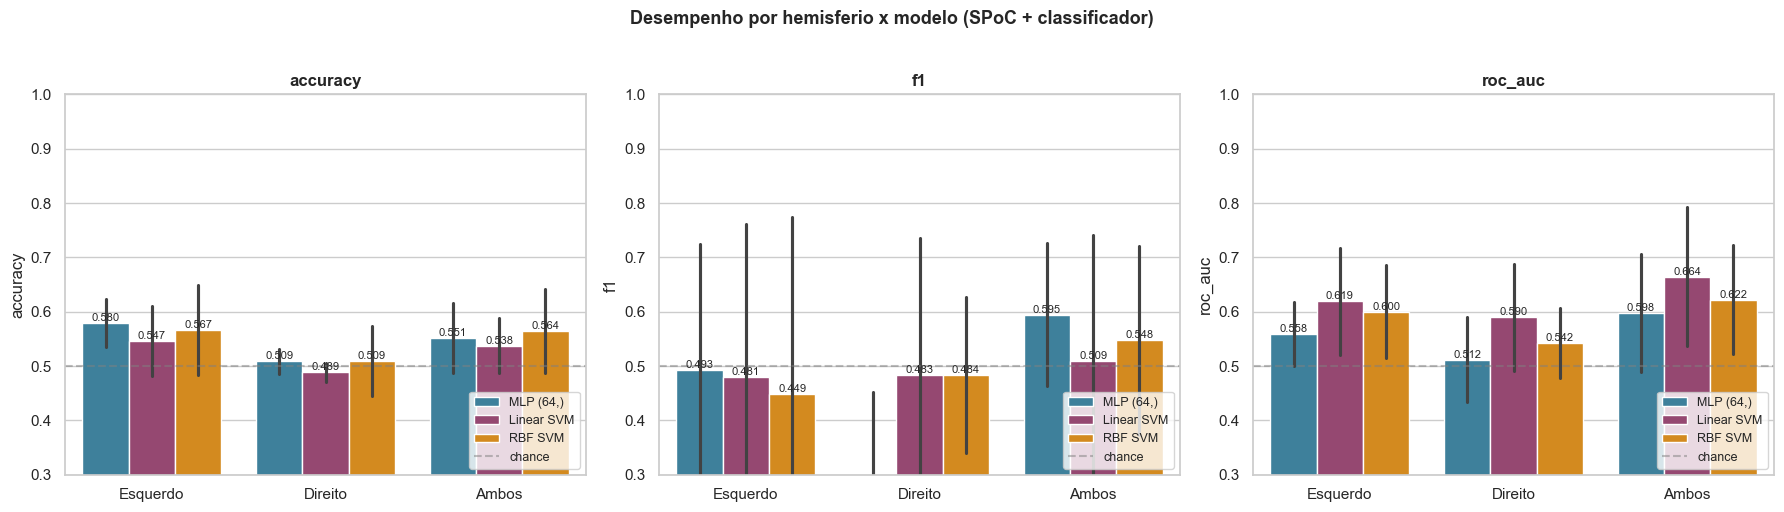

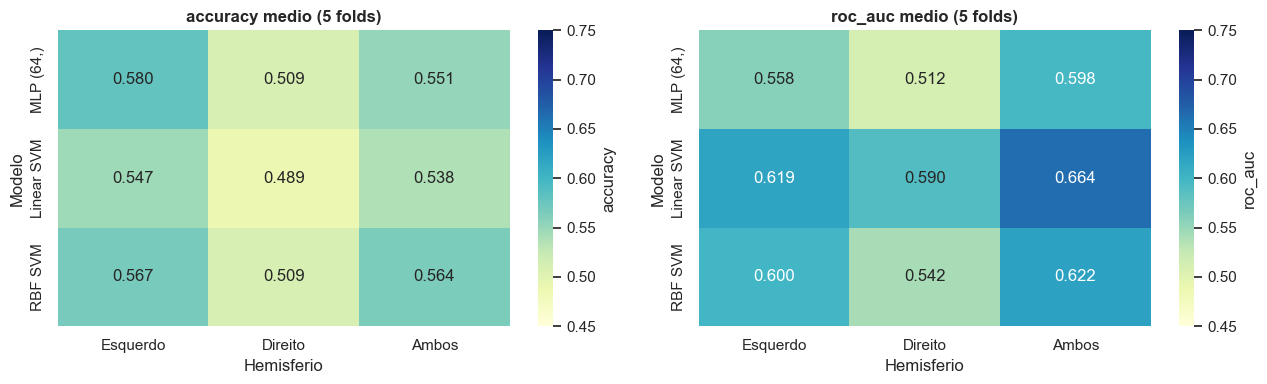

In [76]:
# 5) Barras agregadas: 3 metricas x (modelo, hemisferio)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['accuracy', 'f1', 'roc_auc']

palette = {'MLP (64,)': '#2E86AB', 'Linear SVM': '#A23B72', 'RBF SVM': '#F18F01'}

for ax, metric in zip(axes, metrics_to_plot):
    sub = df_hemi[df_hemi['metrica'] == metric]
    sns.barplot(
        data=sub, x='hemisferio', y='valor', hue='modelo',
        order=HEMI_ORDER, hue_order=MODEL_ORDER,
        palette=palette, ax=ax, errorbar='sd',
    )
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0.3, 1.0)
    ax.legend(loc='lower right', fontsize=9)
    # Anota medias
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=8)

fig.suptitle("Desempenho por hemisferio x modelo (SPoC + classificador)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# 6) Heatmap modelo x hemisferio (AUC medio)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['accuracy', 'roc_auc']):
    pv = (df_hemi[df_hemi['metrica'] == metric]
          .groupby(['modelo', 'hemisferio'])['valor'].mean()
          .unstack().reindex(index=MODEL_ORDER, columns=HEMI_ORDER))
    sns.heatmap(pv, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0.45, vmax=max(0.75, pv.values.max() + 0.02),
                ax=ax, cbar_kws={'label': metric})
    ax.set_title(f"{metric} medio (5 folds)", fontweight='bold')
    ax.set_xlabel("Hemisferio"); ax.set_ylabel("Modelo")
plt.tight_layout(); plt.show()

### Teste 7.3 - Desempenho por fold

Plots dedicados: linhas conectando os 5 folds (cada cor = um modelo, cada subplot = um hemisferio).

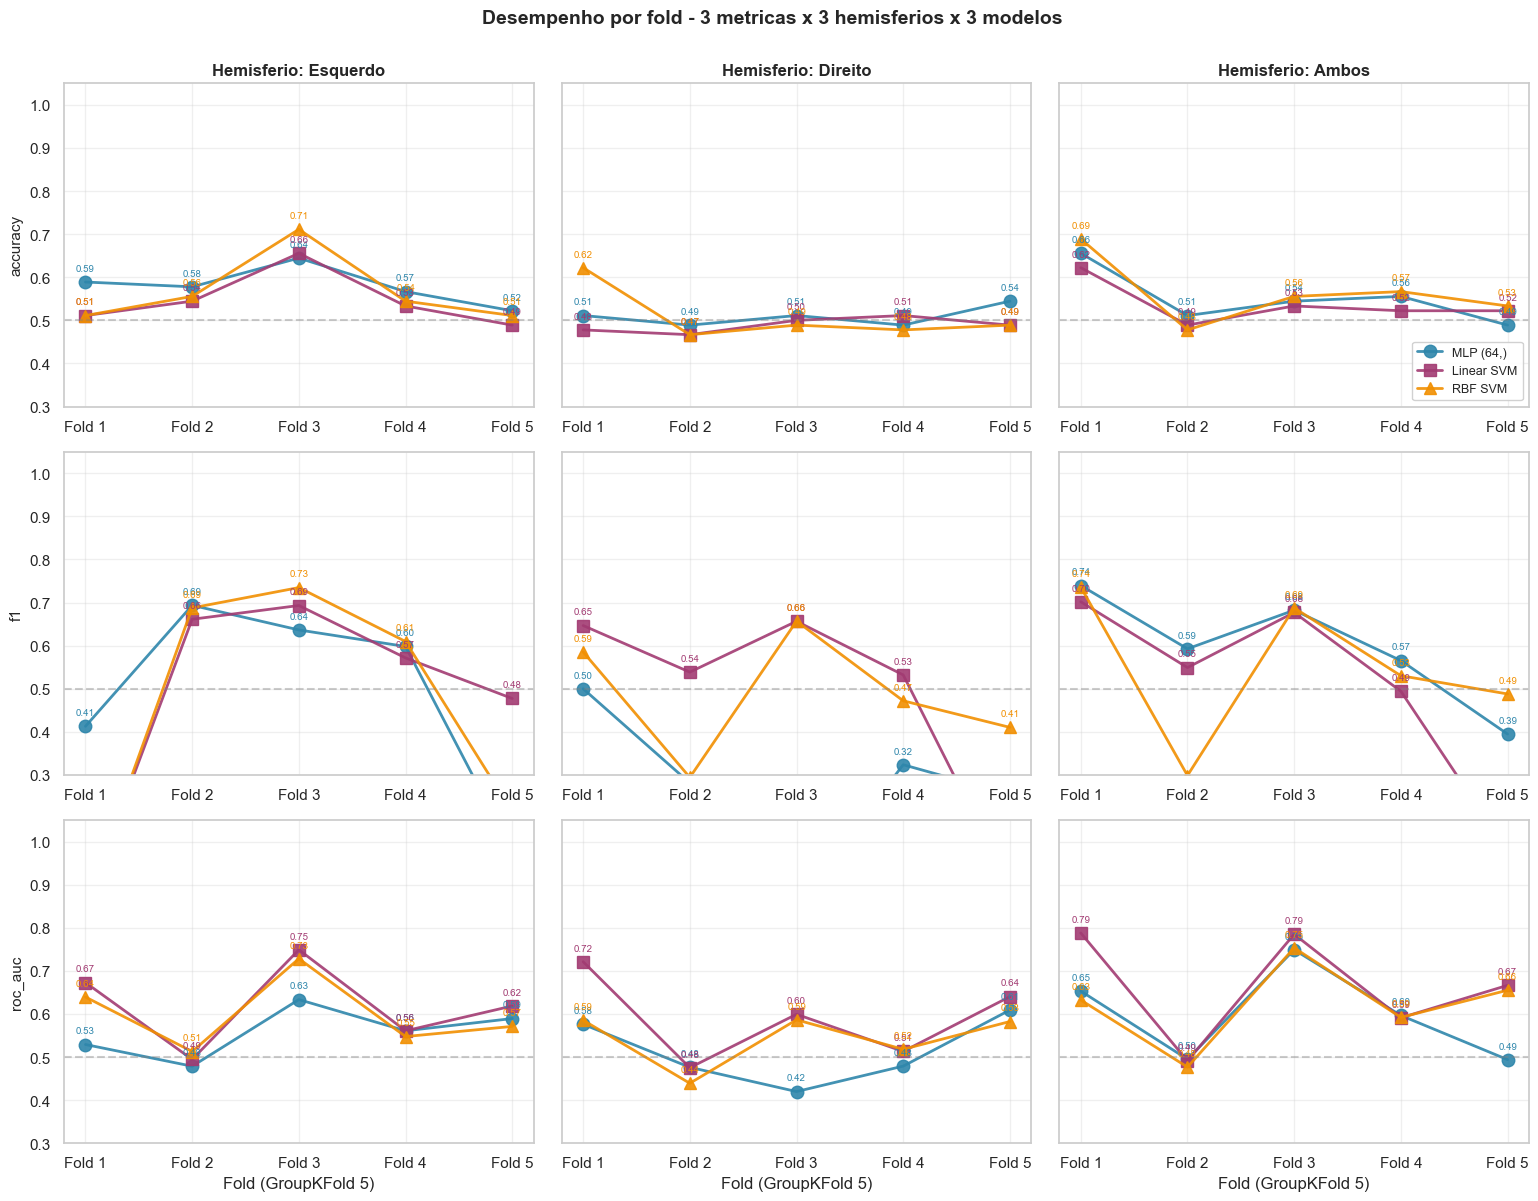

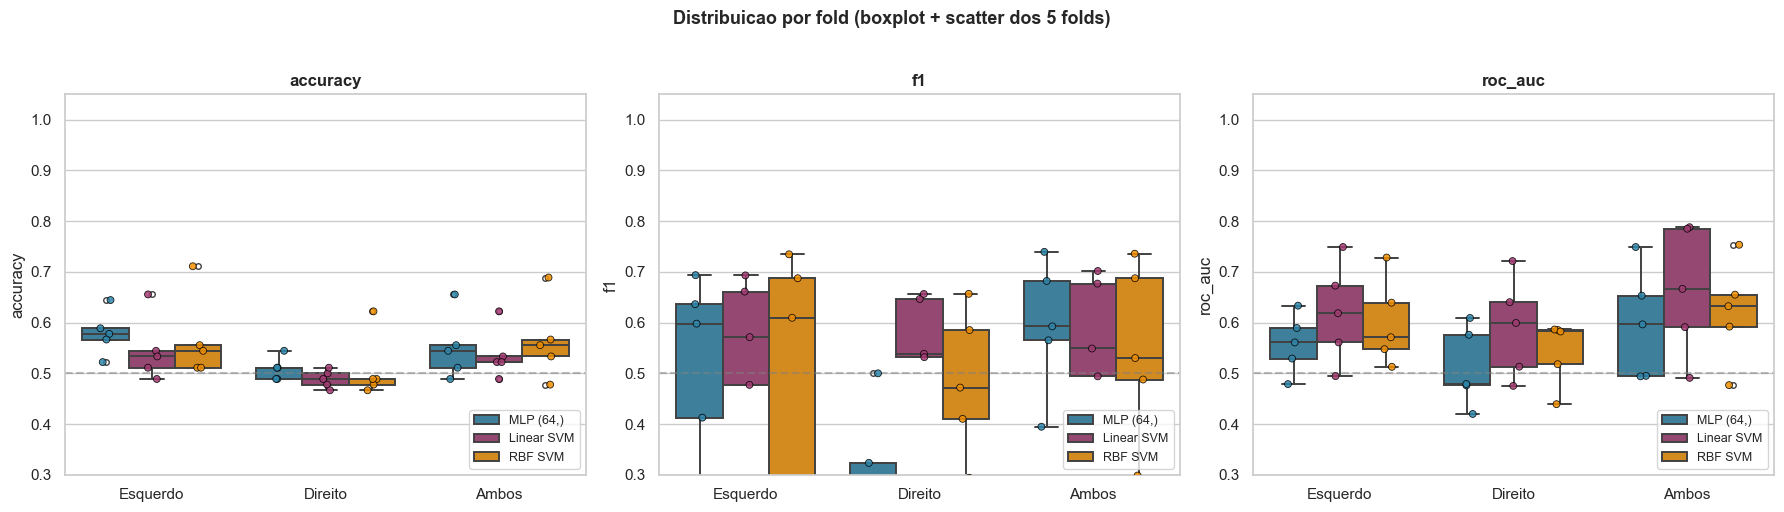

In [77]:
# 7) Desempenho POR FOLD (pedido explicitamente):
#    Linhas conectando os 5 folds, separadas por modelo, com um subplot
#    para cada hemisferio. Mostra variabilidade entre sujeitos.

metrics_to_plot = ['accuracy', 'f1', 'roc_auc']

fig, axes = plt.subplots(
    nrows=len(metrics_to_plot), ncols=len(HEMI_ORDER),
    figsize=(5.2 * len(HEMI_ORDER), 4 * len(metrics_to_plot)),
    sharey='row',
)

markers = {'MLP (64,)': 'o', 'Linear SVM': 's', 'RBF SVM': '^'}

for row_i, metric in enumerate(metrics_to_plot):
    for col_i, hemi in enumerate(HEMI_ORDER):
        ax = axes[row_i, col_i] if len(metrics_to_plot) > 1 else axes[col_i]
        sub = df_hemi[(df_hemi['metrica'] == metric) &
                      (df_hemi['hemisferio'] == hemi)]
        for model_name in MODEL_ORDER:
            ms = sub[sub['modelo'] == model_name].sort_values('fold')
            ax.plot(
                ms['fold'].values, ms['valor'].values,
                marker=markers[model_name], markersize=9, lw=2,
                color=palette[model_name], label=model_name, alpha=0.9,
            )
            # Anota o valor de cada fold
            for x, y_v in zip(ms['fold'].values, ms['valor'].values):
                ax.annotate(f"{y_v:.2f}", (x, y_v), textcoords='offset points',
                            xytext=(0, 8), ha='center', fontsize=7,
                            color=palette[model_name])

        ax.axhline(0.5, color='gray', ls='--', alpha=0.4)
        ax.set_xticks(range(5))
        ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
        ax.set_ylim(0.30, 1.05)
        ax.grid(True, alpha=0.3)
        if row_i == 0:
            ax.set_title(f"Hemisferio: {hemi}", fontsize=12, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(metric, fontsize=11)
        if row_i == len(metrics_to_plot) - 1:
            ax.set_xlabel("Fold (GroupKFold 5)")
        if row_i == 0 and col_i == len(HEMI_ORDER) - 1:
            ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

fig.suptitle("Desempenho por fold - 3 metricas x 3 hemisferios x 3 modelos",
              fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

# 8) Boxplot por fold (visao alternativa, mais robusta a outliers)
fig, axes = plt.subplots(1, len(metrics_to_plot),
                          figsize=(6 * len(metrics_to_plot), 5))

for ax, metric in zip(axes, metrics_to_plot):
    sub = df_hemi[df_hemi['metrica'] == metric]
    sns.boxplot(
        data=sub, x='hemisferio', y='valor', hue='modelo',
        order=HEMI_ORDER, hue_order=MODEL_ORDER,
        palette=palette, ax=ax, fliersize=4, linewidth=1.4,
    )
    sns.stripplot(
        data=sub, x='hemisferio', y='valor', hue='modelo',
        order=HEMI_ORDER, hue_order=MODEL_ORDER,
        dodge=True, ax=ax, palette=palette,
        size=5, edgecolor='black', linewidth=0.6, alpha=0.85,
        legend=False,
    )
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(""); ax.set_ylabel(metric)
    ax.set_ylim(0.30, 1.05)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], labels[:3], loc='lower right', fontsize=9)

fig.suptitle("Distribuicao por fold (boxplot + scatter dos 5 folds)",
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Teste 7.4 - Diagnostico textual e ranking

In [78]:
# 9) Diagnostico textual: ranking final + interpretacao
print("=== Ranking por AUC medio ===\n")
auc_means = (df_hemi[df_hemi['metrica'] == 'roc_auc']
             .groupby(['hemisferio', 'modelo'])['valor']
             .agg(['mean', 'std']).reset_index()
             .sort_values('mean', ascending=False))
auc_means['display'] = auc_means.apply(
    lambda r: f"{r['mean']:.3f} (+- {r['std']:.3f})", axis=1
)
for _, r in auc_means.iterrows():
    print(f"  {r['hemisferio']:>9s} | {r['modelo']:<11s} -> AUC = {r['display']}")

# Ganho hemisferio unico vs ambos
print("\n=== Ganho de usar AMBOS hemisferios vs apenas um ===\n")
for model_name in MODEL_ORDER:
    sub = (df_hemi[(df_hemi['metrica'] == 'roc_auc') &
                   (df_hemi['modelo'] == model_name)]
           .groupby('hemisferio')['valor'].mean())
    auc_left, auc_right, auc_both = sub['Esquerdo'], sub['Direito'], sub['Ambos']
    gain_left  = auc_both - auc_left
    gain_right = auc_both - auc_right
    print(f"  {model_name:<11s}: AUC esq={auc_left:.3f}, dir={auc_right:.3f}, "
          f"ambos={auc_both:.3f}")
    print(f"             ganho ambos vs esq:  {gain_left:+.3f}")
    print(f"             ganho ambos vs dir:  {gain_right:+.3f}")

# Simetria entre hemisferios (esperado: AUC_esq ~ AUC_dir)
print("\n=== Simetria entre hemisferios (esperado: ~igual) ===\n")
for model_name in MODEL_ORDER:
    sub = (df_hemi[(df_hemi['metrica'] == 'roc_auc') &
                   (df_hemi['modelo'] == model_name)]
           .groupby('hemisferio')['valor'].mean())
    diff = abs(sub['Esquerdo'] - sub['Direito'])
    print(f"  {model_name:<11s}: |AUC_esq - AUC_dir| = {diff:.3f}")

print("\n--- Interpretacao esperada ---")
print("1. Hemisferio unico tipicamente perde para 'Ambos' (perde a assimetria,")
print("   que e a feature dominante em MI - ERD contralateral).")
print("2. Esq vs Dir devem render desempenho similar (sem lateralizacao forte")
print("   por classe). Diferencas grandes podem indicar viesses no dataset.")
print("3. Se um modelo (ex.: RBF SVM) ganhar so com 'Ambos', e sinal de que")
print("   ele explora interacoes inter-hemisferio que MLP/Linear nao pegam.")

=== Ranking por AUC medio ===

      Ambos | Linear SVM  -> AUC = 0.664 (+- 0.128)
      Ambos | RBF SVM     -> AUC = 0.622 (+- 0.101)
   Esquerdo | Linear SVM  -> AUC = 0.619 (+- 0.098)
   Esquerdo | RBF SVM     -> AUC = 0.600 (+- 0.085)
      Ambos | MLP (64,)   -> AUC = 0.598 (+- 0.109)
    Direito | Linear SVM  -> AUC = 0.590 (+- 0.099)
   Esquerdo | MLP (64,)   -> AUC = 0.558 (+- 0.059)
    Direito | RBF SVM     -> AUC = 0.542 (+- 0.065)
    Direito | MLP (64,)   -> AUC = 0.512 (+- 0.078)

=== Ganho de usar AMBOS hemisferios vs apenas um ===

  MLP (64,)  : AUC esq=0.558, dir=0.512, ambos=0.598
             ganho ambos vs esq:  +0.039
             ganho ambos vs dir:  +0.085
  Linear SVM : AUC esq=0.619, dir=0.590, ambos=0.664
             ganho ambos vs esq:  +0.045
             ganho ambos vs dir:  +0.074
  RBF SVM    : AUC esq=0.600, dir=0.542, ambos=0.622
             ganho ambos vs esq:  +0.022
             ganho ambos vs dir:  +0.080

=== Simetria entre hemisferios (esperado

## Teste 8 - CNN 2D sobre features classicas em layout topografico

**Pergunta:** features classicas sao naturalmente *(canais x tipos_de_feature)*, logo tem 2 dimensoes implicitas. Reorganizando os canais em uma **grade que respeite a topografia do escalpo** (linhas FC/C/CP, colunas 5,3,1,z,2,4,6 da esquerda a direita), uma CNN 2D pode explorar relacoes espaciais entre eletrodos vizinhos.

**Reshape:** `(n_epochs, n_features) -> (n_epochs, 3, n_cols, 7)` onde:
- 3 linhas = FC, C, CP (frente -> tras);
- n_cols colunas = 5,3,1,z,2,4,6 (esquerda -> direita);
- 7 canais de feature por posicao (relpow_mu, relpow_beta_low, relpow_beta_high, var, hjorth_mob, hjorth_comp, spec_entropy).

**Arquitetura:** CNN 2D pequena (~10k params) - apropriada para n=10 sujeitos. Conv2D(32) -> BN -> ReLU -> Drop -> Conv2D(64) -> BN -> ReLU -> Drop -> GlobalAvgPool -> Dense(32) -> Sigmoid. Treino fixo de 40 epochs com ensemble de 2 sementes.

### Teste 8.1 - Pre-processamento, arquitetura e validacao (LOSO)

X shape      : (450, 15, 673)
X_feat shape : (450, 105)
CH_NAMES (n=15): ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4']
X_feat_norm shape: (450, 105)


Model: "CNN2D_classical_topo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 5, 7)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 5, 32)       │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 3, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 5, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,681 (45.63 KB)

 Trainable params: 11,489 (44.88 KB)

 Non-trainable params: 192 (768.00 B)

Total params: 11,681

=== LOSO em todos os sujeitos ===
10 sujeitos disponíveis

[CNN 2D] avaliando ...
  fold  1 | subj test=S004 | acc=0.400 auc=0.425
  fold  2 | subj test=S014 | acc=0.578 auc=0.575
  fold  3 | subj test=S015 | acc=0.489 auc=0.573
  fold  4 | subj test=S018 | acc=0.444 auc=0.403
  fold  5 | subj test=S029 | acc=0.556 auc=0.522
  fold  6 | subj test=S032 | acc=0.556 auc=0.595
  fold  7 | subj test=S036 | acc=0.533 auc=0.571
  fold  8 | subj test=S082 | acc=0.489 auc=0.462
  fold  9 | subj test=S087 | acc=0.467 auc=0.437
  fold 10 | subj test=S095 | acc=0.422 auc=0.484

[Riemann + LDA] avaliando ...
  acc=0.553  f1=0.472  auc=0.661

=== Tabela LOSO - média (dp) entre sujeitos ===

metric                        accuracy balanced_accuracy      precision         recall             f1        roc_auc
model                                                                                                               
CNN 2D (classical+topo)  0.493 (0.061)     0.495 (0.060)  

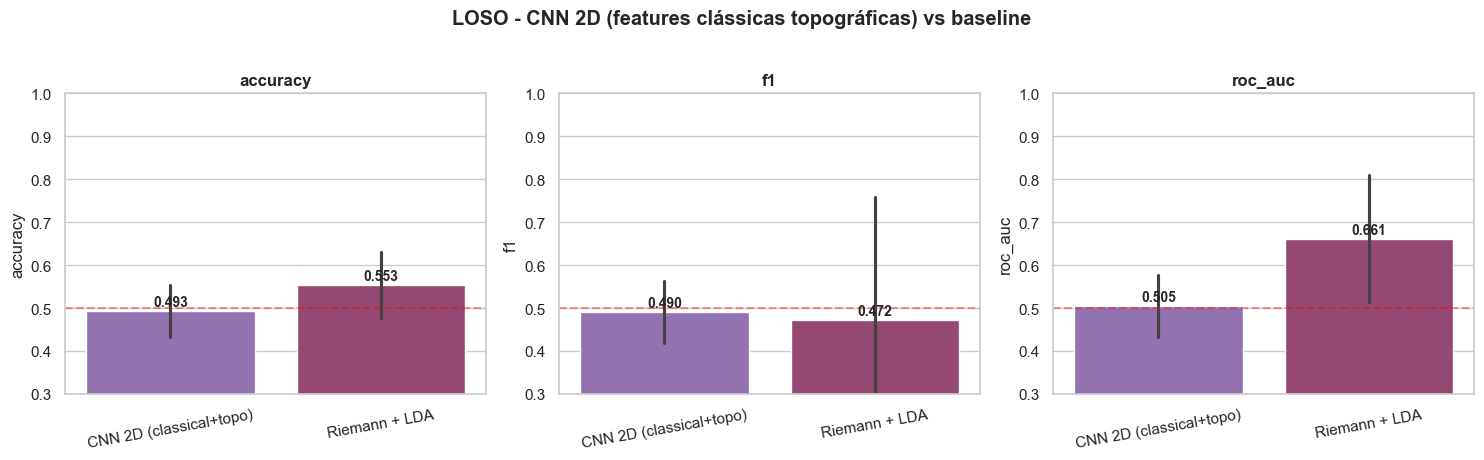

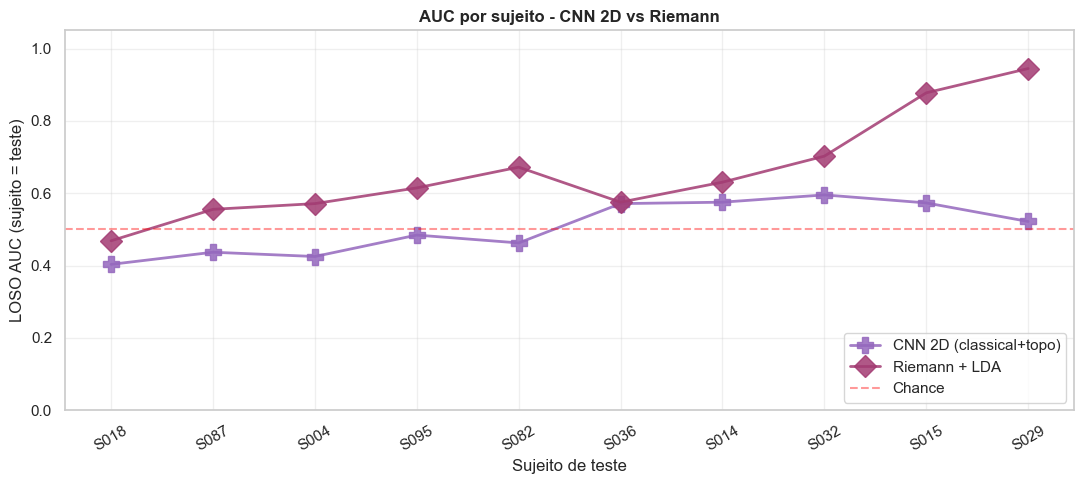

In [79]:
# =========================================================================
# CNN 2D sobre features classicas com layout topografico
# Reshape: (n_epochs, n_features) -> (n_epochs, 3, n_cols, 7) onde
# linhas = FC/C/CP, colunas = sufixo lateral (5,3,1,z,2,4,6)
# 7 = numero de features por canal (relpow mu/betalow/betahigh, var,
#     hjorth_mob, hjorth_comp, spec_entropy)
# Reusa: X_feat, feat_names, CH_NAMES, y, groups, literate_subjs (opcional)
# =========================================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mne
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from scipy import stats

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------
# 0) Garantir que as variáveis do notebook existam
# ---------------------------------------------------------------------
def _ensure_base_variables():
    global X, y, groups, SFREQ, X_feat, feat_names, CH_NAMES

    # Se X, y, groups não existirem, tenta carregar do diretório do notebook
    if not all(v in globals() for v in ["X", "y", "groups", "SFREQ"]):
        if "PER_SUBJECT_DIR" not in globals():
            raise RuntimeError(
                "Não encontrei X, y, groups, SFREQ nem PER_SUBJECT_DIR. "
                "Rode primeiro as células de carregamento do notebook."
            )
        X, y, groups, runs, SFREQ = load_all_subjects(PER_SUBJECT_DIR)

    # Se X_feat/feat_names não existirem, tenta carregar do cache
    if not all(v in globals() for v in ["X_feat", "feat_names"]):
        if "FEATURES_CACHE" in globals() and Path(FEATURES_CACHE).exists():
            print(f"Carregando features do cache: {Path(FEATURES_CACHE).name}")
            import pickle
            with open(FEATURES_CACHE, "rb") as f:
                cached = pickle.load(f)
            X_feat = cached["X_feat"]
            feat_names = cached["feat_names"]
        else:
            raise RuntimeError(
                "Não encontrei X_feat/feat_names nem o cache FEATURES_CACHE. "
                "Rode primeiro a célula de extração de features."
            )

    # Sanity check de shapes
    if len(X_feat) != len(y) or len(X_feat) != len(groups):
        raise RuntimeError(
            f"Incompatibilidade de tamanhos: X_feat={len(X_feat)}, "
            f"y={len(y)}, groups={len(groups)}."
        )

_ensure_base_variables()

# ---------------------------------------------------------------------
# 1) Z-score por sujeito + reshape topográfico
# ---------------------------------------------------------------------
def zscore_per_subject_2d(Xf, groups):
    Xn = Xf.copy().astype(np.float64)
    for s in np.unique(groups):
        m = groups == s
        mu = Xn[m].mean(axis=0, keepdims=True)
        sd = Xn[m].std(axis=0, keepdims=True) + 1e-8
        Xn[m] = (Xn[m] - mu) / sd
    return Xn

GRIDS = {
    21: [
        ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6'],
        ['C5',  'C3',  'C1',  'Cz',  'C2',  'C4',  'C6'],
        ['CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6'],
    ],
    15: [
        ['FC3', 'FC1', 'FCz', 'FC2', 'FC4'],
        ['C3',  'C1',  'Cz',  'C2',  'C4'],
        ['CP3', 'CP1', 'CPz', 'CP2', 'CP4'],
    ],
}

def _infer_ch_names():
    """Tenta obter os nomes reais dos canais a partir de um .fif do diretório."""
    global CH_NAMES

    if "CH_NAMES" in globals() and CH_NAMES is not None:
        return CH_NAMES

    if "PER_SUBJECT_DIR" in globals():
        fif_files = sorted(Path(PER_SUBJECT_DIR).glob("*_allruns-epo.fif"))
        if fif_files:
            ep = mne.read_epochs(fif_files[0], preload=False, verbose=False)
            CH_NAMES = list(ep.ch_names)
            return CH_NAMES

    # fallback: usa grade conhecida compatível com o número de canais
    n_ch = X.shape[1]
    if n_ch in GRIDS:
        CH_NAMES = sum(GRIDS[n_ch], [])
        return CH_NAMES

    raise RuntimeError(
        "Não foi possível inferir CH_NAMES. "
        "Defina CH_NAMES manualmente com os nomes dos canais na ordem correta."
    )

CH_NAMES = _infer_ch_names()

def reshape_to_topomap(Xf_2d, ch_names, n_feat_per_ch=7):
    """Xf_2d (N, n_ch*n_feat) -> (N, n_rows, n_cols, n_feat) topográfico."""
    n = Xf_2d.shape[0]
    n_ch = len(ch_names)

    if Xf_2d.shape[1] != n_ch * n_feat_per_ch:
        raise ValueError(
            f"Esperava {n_ch * n_feat_per_ch} features, recebi {Xf_2d.shape[1]}"
        )
    if n_ch not in GRIDS:
        raise RuntimeError(f"Sem grade definida para {n_ch} canais.")

    grid = GRIDS[n_ch]
    n_rows, n_cols = len(grid), len(grid[0])

    # Features em ordem canal-major: ch0_f0..ch0_f6, ch1_f0..ch1_f6, ...
    X3d = Xf_2d.reshape(n, n_ch, n_feat_per_ch)
    ch_to_i = {c: i for i, c in enumerate(ch_names)}

    Xtopo = np.zeros((n, n_rows, n_cols, n_feat_per_ch), dtype=np.float32)
    missing = []

    for r, row in enumerate(grid):
        for c, ch in enumerate(row):
            if ch in ch_to_i:
                Xtopo[:, r, c, :] = X3d[:, ch_to_i[ch], :]
            else:
                missing.append(ch)

    if missing:
        print(f"AVISO: canais não encontrados e zerados na grade: {sorted(set(missing))}")

    return Xtopo, n_rows, n_cols

# ---------------------------------------------------------------------
# 2) Arquitetura CNN 2D
# ---------------------------------------------------------------------
def build_cnn2d(n_rows, n_cols, n_feat, seed=SEED):
    keras.utils.set_random_seed(seed)
    inp = keras.Input(shape=(n_rows, n_cols, n_feat))
    x = layers.Conv2D(32, kernel_size=(2, 2), padding="same",
                      kernel_initializer="he_normal")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3, seed=seed)(x)

    x = layers.Conv2D(64, kernel_size=(2, 2), padding="same",
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3, seed=seed + 1)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation="relu",
                     kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.4, seed=seed + 2)(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name="CNN2D_classical_topo")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ---------------------------------------------------------------------
# 3) Wrapper sklearn-compatível com ensemble multi-seed
# ---------------------------------------------------------------------
class CNN2DClassicalClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, ch_names, n_feat_per_ch=7, n_seeds=2,
                 n_epochs=40, batch_size=32, seed=SEED):
        self.ch_names = ch_names
        self.n_feat_per_ch = n_feat_per_ch
        self.n_seeds = n_seeds
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        Xtopo, nr, nc = reshape_to_topomap(X, self.ch_names, self.n_feat_per_ch)
        self.shape_ = (nr, nc, self.n_feat_per_ch)
        self.models_ = []

        for s in range(self.n_seeds):
            keras.backend.clear_session()
            m = build_cnn2d(nr, nc, self.n_feat_per_ch, seed=self.seed + s * 1000)
            m.fit(
                Xtopo, y.astype(np.float32),
                epochs=self.n_epochs,
                batch_size=self.batch_size,
                verbose=0,
                shuffle=True
            )
            self.models_.append(m)

        return self

    def predict_proba(self, X):
        Xtopo, _, _ = reshape_to_topomap(X, self.ch_names, self.n_feat_per_ch)
        probs = np.zeros(len(X), dtype=np.float64)
        for m in self.models_:
            probs += m.predict(Xtopo, verbose=0).ravel()
        probs /= len(self.models_)
        return np.stack([1 - probs, probs], axis=1)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ---------------------------------------------------------------------
# 4) Preprocessamento
# ---------------------------------------------------------------------
print(f"X shape      : {X.shape}")
print(f"X_feat shape : {X_feat.shape}")
print(f"CH_NAMES (n={len(CH_NAMES)}): {CH_NAMES}")

X_feat_norm = zscore_per_subject_2d(X_feat, groups)
print(f"X_feat_norm shape: {X_feat_norm.shape}")

demo = build_cnn2d(*reshape_to_topomap(X_feat_norm[:1], CH_NAMES)[1:], n_feat=7)
demo.summary()
print(f"Total params: {demo.count_params():,}")
del demo
keras.backend.clear_session()

# ---------------------------------------------------------------------
# 5) LOSO: CNN 2D vs Riemann + LDA
# ---------------------------------------------------------------------
SCORING_LIST = ["accuracy", "balanced_accuracy", "precision",
                "recall", "f1", "roc_auc"]

print("\n=== LOSO em todos os sujeitos ===")
print(f"{len(np.unique(groups))} sujeitos disponíveis")

loso = LeaveOneGroupOut()
rows = []

def _safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except ValueError:
        return np.nan

print("\n[CNN 2D] avaliando ...")
for fold_idx, (tr, te) in enumerate(loso.split(X_feat_norm, y, groups=groups)):
    test_subj = np.unique(groups[te])[0]

    scaler = RobustScaler().fit(X_feat_norm[tr])
    Xtr_s = scaler.transform(X_feat_norm[tr])
    Xte_s = scaler.transform(X_feat_norm[te])

    clf = CNN2DClassicalClassifier(
        ch_names=CH_NAMES,
        n_feat_per_ch=7,
        n_seeds=2,
        n_epochs=40,
        batch_size=32,
        seed=SEED + fold_idx
    )
    clf.fit(Xtr_s, y[tr])

    proba = clf.predict_proba(Xte_s)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics_fold = {
        "accuracy":          accuracy_score(y[te], pred),
        "balanced_accuracy": balanced_accuracy_score(y[te], pred),
        "precision":         precision_score(y[te], pred, zero_division=0),
        "recall":            recall_score(y[te], pred, zero_division=0),
        "f1":                f1_score(y[te], pred, zero_division=0),
        "roc_auc":           _safe_roc_auc(y[te], proba),
    }

    print(f"  fold {fold_idx+1:2d} | subj test={test_subj} | "
          f"acc={metrics_fold['accuracy']:.3f} auc={metrics_fold['roc_auc']:.3f}")

    for m, v in metrics_fold.items():
        rows.append({
            "model": "CNN 2D (classical+topo)",
            "metric": m,
            "fold": fold_idx,
            "subj_test": str(test_subj),
            "value": v
        })

print("\n[Riemann + LDA] avaliando ...")
if "X" in globals():
    riemann = Pipeline([
        ("cov",    Covariances(estimator="oas")),
        ("ts",     TangentSpace()),
        ("scaler", RobustScaler()),
        ("clf",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])
    sc = cross_validate(
        riemann, X, y, groups=groups, cv=loso,
        scoring=SCORING_LIST, n_jobs=-1, error_score="raise"
    )

    unique_subj_ord = [str(np.unique(groups[te])[0]) for tr, te in loso.split(X, y, groups=groups)]
    for met in SCORING_LIST:
        for f, v in enumerate(sc[f"test_{met}"]):
            rows.append({
                "model": "Riemann + LDA",
                "metric": met,
                "fold": f,
                "subj_test": unique_subj_ord[f],
                "value": v
            })

    print(f"  acc={sc['test_accuracy'].mean():.3f}  "
          f"f1={sc['test_f1'].mean():.3f}  "
          f"auc={sc['test_roc_auc'].mean():.3f}")
else:
    print("  X (sinal cru) não disponível, pulando Riemann.")

df_cnn = pd.DataFrame(rows)

# ---------------------------------------------------------------------
# 6) Tabela resumo
# ---------------------------------------------------------------------
MODEL_ORDER = ["CNN 2D (classical+topo)"] + (
    ["Riemann + LDA"] if "Riemann + LDA" in df_cnn["model"].unique() else []
)

summ = df_cnn.groupby(["model", "metric"])["value"].agg(["mean", "std"]).reset_index()
summ["display"] = summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)
pivot = summ.pivot_table(index="model", columns="metric", values="display", aggfunc="first")
pivot = pivot.reindex(MODEL_ORDER)[SCORING_LIST]

print("\n=== Tabela LOSO - média (dp) entre sujeitos ===\n")
print(pivot.to_string())

print("\n=== IC 95% para AUC (t-Student, n folds) ===")
for m in MODEL_ORDER:
    auc = df_cnn[(df_cnn["model"] == m) & (df_cnn["metric"] == "roc_auc")]["value"].dropna().values
    n = len(auc)
    if n < 2:
        print(f"  {m:<28s} -> AUC insuficiente para IC95%")
        continue
    mean, sd = auc.mean(), auc.std(ddof=1)
    ci_half = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)
    print(f"  {m:<28s} -> AUC = {mean:.3f}  IC95% = [{mean-ci_half:.3f}, {mean+ci_half:.3f}]")

# ---------------------------------------------------------------------
# 7) Plots
# ---------------------------------------------------------------------
palette = {"CNN 2D (classical+topo)": "#9467bd", "Riemann + LDA": "#A23B72"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, met in zip(axes, ["accuracy", "f1", "roc_auc"]):
    sub = df_cnn[df_cnn["metric"] == met].copy()
    sns.barplot(
        data=sub, x="model", y="value",
        order=MODEL_ORDER, palette=palette,
        ax=ax, errorbar="sd"
    )
    ax.axhline(0.5, color="red", ls="--", alpha=0.4)
    ax.set_title(met, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(met)
    ax.set_ylim(0.3, 1.0)
    ax.tick_params(axis="x", rotation=10)

    means = sub.groupby("model", sort=False)["value"].mean().reindex(MODEL_ORDER)
    for i, mv in enumerate(means.values):
        if not np.isnan(mv):
            ax.text(i, mv + 0.012, f"{mv:.3f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("LOSO - CNN 2D (features clássicas topográficas) vs baseline",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sub_auc = df_cnn[df_cnn["metric"] == "roc_auc"].copy()
order_subj = (sub_auc.groupby("subj_test")["value"]
              .mean().sort_values(ascending=True).index.tolist())

markers = {"CNN 2D (classical+topo)": "P", "Riemann + LDA": "D"}
for mname in MODEL_ORDER:
    sm = sub_auc[sub_auc["model"] == mname].set_index("subj_test").reindex(order_subj)
    ax.plot(
        range(len(order_subj)), sm["value"].values,
        marker=markers[mname], markersize=11, lw=2,
        color=palette[mname], label=mname, alpha=0.85
    )

ax.axhline(0.5, color="red", ls="--", alpha=0.4, label="Chance")

if "literate_subjs" in globals():
    ax.set_xticks(range(len(order_subj)))
    xtl = ax.set_xticklabels(order_subj, rotation=30)
    for i, subj in enumerate(order_subj):
        xtl[i].set_color("seagreen" if subj in literate_subjs else "indianred")
else:
    ax.set_xticks(range(len(order_subj)))
    ax.set_xticklabels(order_subj, rotation=30)

ax.set_ylabel("LOSO AUC (sujeito = teste)")
ax.set_xlabel("Sujeito de teste")
ax.set_title("AUC por sujeito - CNN 2D vs Riemann", fontweight="bold")
ax.set_ylim(0.0, 1.05)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Teste 9 - CNN 2D sobre STFT (sinal cru -> espectrograma)

**Pergunta:** ate aqui usamos features extraidas. E se deixarmos a CNN aprender as features diretamente do espectrograma do sinal cru?

**Pipeline:**
1. Para cada epoca, calcular STFT por canal (window 128, overlap 64, fmin=8 Hz, fmax=30 Hz);
2. Empilhar canais como dimensoes: tensor `(F, T', C)` por epoca, onde F=frequencias, T'=tempo, C=canais;
3. CNN 2D simples sobre esse tensor.

**Limitacao:** sem layout topografico (canais sao tratados como um eixo arbitrario). O Teste 10 corrige isso com tensor 5D + CNN 3D.

### Teste 9.1 - Pre-processamento (STFT) e treino com CNN 2D

In [80]:
# =========================================================================
# EEG → STFT → Tensor → CNN 2D (LOSO)
# =========================================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.signal import spectrogram
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------
# 1) STFT por canal
# ---------------------------------------------------------------------
def compute_spectrogram(X, sfreq, fmin=8, fmax=30, nperseg=128, noverlap=64):
    """
    X: (n_epochs, n_channels, n_times)
    retorna: (n_epochs, n_channels, n_freqs, n_times_stft)
    """
    n_epochs, n_ch, _ = X.shape
    specs = []

    for ep in range(n_epochs):
        ch_specs = []
        for ch in range(n_ch):
            f, t, Sxx = spectrogram(
                X[ep, ch],
                fs=sfreq,
                nperseg=nperseg,
                noverlap=noverlap,
                scaling="density",
                mode="psd"
            )

            # selecionar banda relevante
            mask = (f >= fmin) & (f <= fmax)
            Sxx = Sxx[mask]

            # log para estabilizar
            Sxx = np.log(Sxx + 1e-10)

            ch_specs.append(Sxx)

        specs.append(np.stack(ch_specs, axis=0))

    return np.array(specs)  # (N, C, F, T)

# ---------------------------------------------------------------------
# 2) Normalização por sujeito
# ---------------------------------------------------------------------
def zscore_per_subject(X, groups):
    Xn = X.copy()
    for s in np.unique(groups):
        idx = groups == s
        mu = Xn[idx].mean()
        sd = Xn[idx].std() + 1e-8
        Xn[idx] = (Xn[idx] - mu) / sd
    return Xn

# ---------------------------------------------------------------------
# 3) Converter para formato CNN
# ---------------------------------------------------------------------
def prepare_tensor(X_spec):
    """
    (N, C, F, T) → (N, F, T, C)
    """
    return np.transpose(X_spec, (0, 2, 3, 1)).astype(np.float32)

# ---------------------------------------------------------------------
# 4) CNN 2D
# ---------------------------------------------------------------------
def build_cnn(input_shape, seed=SEED):
    keras.utils.set_random_seed(seed)

    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ---------------------------------------------------------------------
# 5) Wrapper sklearn
# ---------------------------------------------------------------------
class SpectroCNN(BaseEstimator, ClassifierMixin):
    def __init__(self, sfreq, n_epochs=30, batch_size=32, seed=SEED):
        self.sfreq = sfreq
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed

    def fit(self, X, y):
        # STFT
        Xs = compute_spectrogram(X, self.sfreq)
        Xs = prepare_tensor(Xs)

        self.model_ = build_cnn(Xs.shape[1:], self.seed)

        self.model_.fit(
            Xs, y,
            epochs=self.n_epochs,
            batch_size=self.batch_size,
            verbose=0
        )
        return self

    def predict_proba(self, X):
        Xs = compute_spectrogram(X, self.sfreq)
        Xs = prepare_tensor(Xs)

        p = self.model_.predict(Xs, verbose=0).ravel()
        return np.stack([1 - p, p], axis=1)

    def predict(self, X):
        return (self.predict_proba(X)[:,1] > 0.5).astype(int)

# ---------------------------------------------------------------------
# 6) LOSO
# ---------------------------------------------------------------------
print("\n=== STFT + CNN (LOSO) ===")

loso = LeaveOneGroupOut()
rows = []

for fold, (tr, te) in enumerate(loso.split(X, y, groups)):
    subj = np.unique(groups[te])[0]

    clf = SpectroCNN(sfreq=SFREQ, n_epochs=30, seed=SEED+fold)
    clf.fit(X[tr], y[tr])

    proba = clf.predict_proba(X[te])[:,1]
    pred = (proba > 0.5).astype(int)

    try:
        auc = roc_auc_score(y[te], proba)
    except:
        auc = np.nan

    acc = accuracy_score(y[te], pred)
    f1  = f1_score(y[te], pred)

    print(f"fold {fold+1} | subj={subj} | acc={acc:.3f} | auc={auc:.3f}")

    rows.append((acc, f1, auc))

rows = np.array(rows)

print("\n=== RESULTADO FINAL ===")
print(f"ACC: {rows[:,0].mean():.3f} ± {rows[:,0].std():.3f}")
print(f"F1 : {rows[:,1].mean():.3f} ± {rows[:,1].std():.3f}")
print(f"AUC: {np.nanmean(rows[:,2]):.3f} ± {np.nanstd(rows[:,2]):.3f}")


=== STFT + CNN (LOSO) ===
fold 1 | subj=S004 | acc=0.489 | auc=0.542
fold 2 | subj=S014 | acc=0.489 | auc=0.598
fold 3 | subj=S015 | acc=0.511 | auc=0.522
fold 4 | subj=S018 | acc=0.489 | auc=0.548
fold 5 | subj=S029 | acc=0.511 | auc=0.478
fold 6 | subj=S032 | acc=0.533 | auc=0.452
fold 7 | subj=S036 | acc=0.489 | auc=0.524
fold 8 | subj=S082 | acc=0.511 | auc=0.591
fold 9 | subj=S087 | acc=0.511 | auc=0.581
fold 10 | subj=S095 | acc=0.489 | auc=0.557

=== RESULTADO FINAL ===
ACC: 0.502 ± 0.015
F1 : 0.334 ± 0.334
AUC: 0.539 ± 0.045


## Teste 10 - CNN 3D sobre STFT topografico

**Pergunta:** combinar o melhor do Teste 8 (layout topografico dos canais) com o melhor do Teste 9 (STFT do sinal cru)?

**Pipeline:**
1. STFT por canal -> `(N, C, F, T)`;
2. Reshape topografico -> `(N, rows, cols, F, T)` onde rows=FC/C/CP, cols=ordem espacial;
3. CNN **3D** sobre esse tensor: convolucoes (rows, cols, time) ao longo do espaco e do tempo, frequencia entra como canal de feature.

**Tradeoff:** mais expressivo, mais parametros, mais lento de treinar. Para 10 sujeitos, e arriscado em termos de overfitting - mas vale o experimento.

### Teste 10.1 - Pre-processamento: STFT e reshape topografico

In [81]:
from scipy.signal import spectrogram
import numpy as np

def compute_stft_tensor(X, sfreq, fmin=8, fmax=30,
                        nperseg=128, noverlap=64):
    """
    X: (N, C, T)
    return: (N, C, F, T')
    """
    N, C, _ = X.shape
    out = []

    for i in range(N):
        ch_specs = []
        for ch in range(C):
            f, t, Sxx = spectrogram(
                X[i, ch],
                fs=sfreq,
                nperseg=nperseg,
                noverlap=noverlap,
                scaling="density",
                mode="psd"
            )

            band = (f >= fmin) & (f <= fmax)
            Sxx = Sxx[band]

            # log power (importante!)
            Sxx = np.log(Sxx + 1e-10)

            ch_specs.append(Sxx)

        out.append(np.stack(ch_specs, axis=0))

    return np.array(out, dtype=np.float32)

In [82]:
GRIDS = {
    21: [
        ['FC5','FC3','FC1','FCz','FC2','FC4','FC6'],
        ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
        ['CP5','CP3','CP1','CPz','CP2','CP4','CP6']
    ],
    15: [
        ['FC3','FC1','FCz','FC2','FC4'],
        ['C3', 'C1', 'Cz', 'C2', 'C4'],
        ['CP3','CP1','CPz','CP2','CP4']
    ]
}

def to_topomap_5d(X_stft, ch_names):
    """
    (N, C, F, T) → (N, rows, cols, F, T)
    """
    N, C, F, T = X_stft.shape

    grid = GRIDS[C]
    rows, cols = len(grid), len(grid[0])

    ch_to_idx = {ch: i for i, ch in enumerate(ch_names)}

    X_topo = np.zeros((N, rows, cols, F, T), dtype=np.float32)

    for r in range(rows):
        for c in range(cols):
            ch = grid[r][c]
            if ch in ch_to_idx:
                X_topo[:, r, c] = X_stft[:, ch_to_idx[ch]]
            else:
                pass  # canal ausente → fica zero

    return X_topo

### Teste 10.2 - Arquitetura CNN 3D

In [83]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn3d(input_shape, seed=42):
    keras.utils.set_random_seed(seed)

    inp = keras.Input(shape=input_shape)

    x = layers.Conv3D(16, (2,2,3), padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling3D((1,1,2))(x)

    x = layers.Conv3D(32, (2,2,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling3D((1,1,2))(x)

    x = layers.GlobalAveragePooling3D()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Teste 10.3 - Treino e validacao (LOSO)

In [84]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SEED = 42
loso = LeaveOneGroupOut()

rows = []

for fold, (tr, te) in enumerate(loso.split(X, y, groups), start=1):
    subj = np.unique(groups[te])[0]

    # -----------------------------------------
    # STFT
    # -----------------------------------------
    X_stft_tr = compute_stft_tensor(X[tr], SFREQ)
    X_stft_te = compute_stft_tensor(X[te], SFREQ)

    # -----------------------------------------
    # normalização (flatten → scale → reshape)
    # -----------------------------------------
    def scale_5d(Xtr, Xte):
        shp = Xtr.shape
        Xtr_flat = Xtr.reshape(len(Xtr), -1)
        Xte_flat = Xte.reshape(len(Xte), -1)

        scaler = RobustScaler().fit(Xtr_flat)

        Xtr_s = scaler.transform(Xtr_flat).reshape(shp)
        Xte_s = scaler.transform(Xte_flat).reshape(Xte.shape)

        return Xtr_s, Xte_s

    X_stft_tr, X_stft_te = scale_5d(X_stft_tr, X_stft_te)

    # -----------------------------------------
    # topo
    # -----------------------------------------
    X_tr = to_topomap_5d(X_stft_tr, CH_NAMES)
    X_te = to_topomap_5d(X_stft_te, CH_NAMES)

    # -----------------------------------------
    # CNN 3D
    # -----------------------------------------
    model = build_cnn3d(X_tr.shape[1:], seed=SEED+fold)

    model.fit(
        X_tr, y[tr],
        epochs=40,
        batch_size=8,
        verbose=0,
        validation_split=0.2,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=8,
                restore_best_weights=True
            )
        ]
    )

    # -----------------------------------------
    # avaliação
    # -----------------------------------------
    proba = model.predict(X_te).ravel()
    pred = (proba >= 0.5).astype(int)

    acc = accuracy_score(y[te], pred)
    f1 = f1_score(y[te], pred)
    auc = roc_auc_score(y[te], proba)

    print(f"fold {fold} | subj={subj} | acc={acc:.3f} | f1={f1:.3f} | auc={auc:.3f}")

    rows.append([acc, f1, auc])

# resumo
rows = np.array(rows)
print("\n=== RESULTADO FINAL ===")
print(f"ACC: {rows[:,0].mean():.3f}")
print(f"F1 : {rows[:,1].mean():.3f}")
print(f"AUC: {rows[:,2].mean():.3f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
fold 1 | subj=S004 | acc=0.489 | f1=0.657 | auc=0.583
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
fold 2 | subj=S014 | acc=0.511 | f1=0.083 | auc=0.457
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
fold 3 | subj=S015 | acc=0.511 | f1=0.000 | auc=0.447
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
fold 4 | subj=S018 | acc=0.489 | f1=0.000 | auc=0.326
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
fold 5 | subj=S029 | acc=0.556 | f1=0.667 | auc=0.591
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
fold 6 | subj=S032 | acc=0.556 | f1=0.655 | auc=0.550
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
fold 7 | subj=S036 | acc=0.578 | f1=0.689 | auc=0.559
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
fold 8 | subj=S082 | acc=0.511 | f1=0.645 | auc=0.591
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
fold 9 | subj=S087 | acc=0.578 | f1=0.486 | auc=0.545
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
fold 10 | subj=S095 | acc=0.556 | f1=0.630 | auc=0.520

=== RESULTADO FINAL ===
ACC: 0.533
F1 : 0.451
AUC: 0.517


## Analise Complementar - Heterogeneidade entre sujeitos (BCI literacy)

**Contexto.** A literatura de BCI ha decadas documenta que cerca de **30-50% dos voluntarios** nao conseguem produzir ERD/ERS detectavel durante imagetica motora - sao os chamados **"BCI illiterate"**. Quando se mistura todos os sujeitos num CV cross-subject, a media puxa o desempenho para baixo.

**Procedimento desta analise complementar:**
1. Para cada sujeito, calcular o **within-subject AUC** (Riemann + LDA, validacao interna);
2. Definir um threshold (AUC = 0.60);
3. Comparar o desempenho cross-subject **antes** (todos os sujeitos) e **depois** (apenas BCI literate) da triagem.

**Caveat importante:** os resultados pos-triagem sao validos APENAS para sujeitos com sinal MI detectavel; reportar isso explicitamente em qualquer trabalho derivado.

**Esta analise nao integra os Testes 1-10** (e exploratoria), mas ajuda a interpretar por que os AUCs cross-subject ficam tipicamente em ~0.60-0.70 com features classicas/espaciais.

### A.1 - Triagem por within-subject AUC e comparacao antes/depois

In [ ]:
# =========================================================================
# LOSO em 3 grupos: todos / literate / illiterate
# Mostra a heterogeneidade individual sem precisar "remover" sujeitos
# Reusa: X, y, groups (do bloco anterior)
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import (LeaveOneGroupOut, StratifiedKFold,
                                     cross_validate)
from sklearn.metrics import roc_auc_score
from mne.decoding import SPoC
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings("ignore")

SEED = 42
SCORING_LIST = ["accuracy", "balanced_accuracy", "precision",
                "recall", "f1", "roc_auc"]
AUC_THRESHOLD = 0.60   # Limiar para "BCI literate" (padrao da literatura)

# =========================================================================
# Etapa 0 - Triagem within-subject (gera literate_subjs e illiterate_subjs)
# Se essas variaveis ja existirem do bloco anterior, pula esta etapa.
# =========================================================================
def make_within_pipe():
    return Pipeline([
        ("cov",    Covariances(estimator="oas")),
        ("ts",     TangentSpace()),
        ("scaler", RobustScaler()),
        ("clf",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

if 'literate_subjs' not in dir() or 'illiterate_subjs' not in dir() or 'within_df' not in dir():
    print(f"Calculando within-subject AUC em {len(np.unique(groups))} sujeitos...")
    have_runs = "runs" in dir() and len(np.unique(globals()["runs"])) >= 2
    print(f"Estrategia interna: " +
          ("LeaveOneRunOut (runs disponivel)" if have_runs
           else "StratifiedKFold(3) (runs nao disponivel)"))

    within_results = []
    for subj in np.unique(groups):
        mask = groups == subj
        Xs, ys = X[mask], y[mask]

        if len(np.unique(ys)) < 2:
            within_results.append({"subj": subj, "n_epochs": len(ys),
                                   "n_folds": 0, "auc": np.nan})
            continue

        try:
            if have_runs:
                rs = runs[mask]
                cv_split = list(LeaveOneGroupOut().split(Xs, ys, groups=rs))
            else:
                cv_split = list(StratifiedKFold(n_splits=3, shuffle=True,
                                                 random_state=SEED).split(Xs, ys))
        except Exception:
            within_results.append({"subj": subj, "n_epochs": len(ys),
                                   "n_folds": 0, "auc": np.nan})
            continue

        aucs_fold = []
        for tr, te in cv_split:
            if len(np.unique(ys[tr])) < 2 or len(np.unique(ys[te])) < 2:
                continue
            try:
                pipe = make_within_pipe()
                pipe.fit(Xs[tr], ys[tr])
                proba = pipe.predict_proba(Xs[te])[:, 1]
                aucs_fold.append(roc_auc_score(ys[te], proba))
            except Exception:
                continue

        auc_subj = float(np.mean(aucs_fold)) if aucs_fold else np.nan
        within_results.append({"subj": subj, "n_epochs": len(ys),
                               "n_folds": len(aucs_fold), "auc": auc_subj})

    within_df = pd.DataFrame(within_results).sort_values("auc", ascending=False)
    literate_subjs   = within_df.loc[within_df["auc"] >= AUC_THRESHOLD, "subj"].tolist()
    illiterate_subjs = within_df.loc[within_df["auc"] <  AUC_THRESHOLD, "subj"].tolist()
    print(f"  BCI literate   (AUC >= {AUC_THRESHOLD}): {len(literate_subjs)}")
    print(f"  BCI illiterate (AUC <  {AUC_THRESHOLD}): {len(illiterate_subjs)}")
    print(f"  Literate: {literate_subjs}")
    print(f"  Illiterate: {illiterate_subjs}")
else:
    print("Variaveis literate_subjs / illiterate_subjs / within_df ja existem; pulando triagem.")

# =========================================================================
# Pipelines para LOSO comparativa
# =========================================================================
def mk_lin_svm():
    return SVC(kernel="linear", C=1.0, probability=True,
               class_weight="balanced", random_state=SEED)

PIPES = {
    "SPoC k=4 + LinSVM": Pipeline([
        ("spoc",   SPoC(n_components=4, reg="oas", log=True,
                        transform_into="average_power")),
        ("scaler", RobustScaler()), ("clf", mk_lin_svm())]),
    "Riemann + LDA": Pipeline([
        ("cov",    Covariances(estimator="oas")),
        ("ts",     TangentSpace()),
        ("scaler", RobustScaler()),
        ("clf",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))]),
}

# 3 subgrupos
mask_lit   = np.isin(groups, literate_subjs)
mask_illit = np.isin(groups, illiterate_subjs)

GROUPS = [
    ("Todos (n=10)",      X,             y,             groups,             10),
    ("Literate (n=5)",    X[mask_lit],   y[mask_lit],   groups[mask_lit],   5),
    ("Illiterate (n=5)",  X[mask_illit], y[mask_illit], groups[mask_illit], 5),
]

print("\n=== LOSO em 3 grupos ===\n")
rows = []
for grupo, Xg, yg, gg, n_subj in GROUPS:
    n_subj_real = len(np.unique(gg))
    print(f"[{grupo}] {Xg.shape[0]} epocas, {n_subj_real} sujeitos")
    if n_subj_real < 2:
        print(f"  AVISO: <2 sujeitos, pulando este grupo.")
        continue
    for name, pipe in PIPES.items():
        sc = cross_validate(pipe, Xg, yg, groups=gg, cv=LeaveOneGroupOut(),
                            scoring=SCORING_LIST, n_jobs=-1, error_score="raise")
        for met in SCORING_LIST:
            for f, v in enumerate(sc[f"test_{met}"]):
                rows.append({"grupo": grupo, "model": name,
                             "metric": met, "fold": f, "value": v})
        # IC 95% (t-Student aproximado para n pequeno)
        auc_arr = sc["test_roc_auc"]
        m = auc_arr.mean()
        s = auc_arr.std(ddof=1) if len(auc_arr) > 1 else 0
        if len(auc_arr) > 1:
            ci_half = stats.t.ppf(0.975, len(auc_arr)-1) * s / np.sqrt(len(auc_arr))
            ci = f"[{m-ci_half:.3f}, {m+ci_half:.3f}]"
        else:
            ci = "(n=1, sem IC)"
        print(f"  {name:<22s} -> AUC = {m:.3f} +- {s:.3f}  IC95%={ci}")
    print()

df_loso = pd.DataFrame(rows)

# Tabela resumo
summ = df_loso.groupby(["grupo", "model", "metric"])["value"]\
        .agg(["mean", "std"]).reset_index()
summ["display"] = summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)
GROUP_ORDER = ["Todos (n=10)", "Literate (n=5)", "Illiterate (n=5)"]
pivot = summ.pivot_table(index=["grupo", "model"], columns="metric",
                         values="display", aggfunc="first")
pivot = pivot.reindex(
    pd.MultiIndex.from_product([GROUP_ORDER, list(PIPES.keys())],
                                names=["grupo", "model"])
)[SCORING_LIST]
print("=== Tabela LOSO - media (dp) entre sujeitos ===\n")
print(pivot.to_string())

# Plot AUC por sujeito (cada ponto = 1 fold = 1 sujeito de teste)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por sujeito (strip + boxplot)
ax = axes[0]
sub = df_loso[df_loso["metric"] == "roc_auc"]
sns.boxplot(data=sub, x="grupo", y="value", hue="model", ax=ax,
            order=GROUP_ORDER, hue_order=list(PIPES.keys()),
            palette={"SPoC k=4 + LinSVM": "#2E86AB",
                      "Riemann + LDA": "#A23B72"},
            fliersize=0, linewidth=1.4)
sns.stripplot(data=sub, x="grupo", y="value", hue="model", ax=ax,
              order=GROUP_ORDER, hue_order=list(PIPES.keys()),
              dodge=True, palette={"SPoC k=4 + LinSVM": "#2E86AB",
                                   "Riemann + LDA": "#A23B72"},
              size=8, edgecolor="black", linewidth=0.7, alpha=0.9, legend=False)
ax.axhline(0.5, color="red", ls="--", alpha=0.5, label="Chance")
ax.set_ylabel("LOSO AUC (cada ponto = 1 sujeito-teste)")
ax.set_xlabel(""); ax.set_title("AUC por sujeito - 3 grupos", fontweight="bold")
ax.set_ylim(0.0, 1.05)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], loc="upper right", fontsize=9)

# AUC ordenado por sujeito (linha por modelo)
ax = axes[1]
sub_all = df_loso[(df_loso["metric"] == "roc_auc") &
                   (df_loso["grupo"] == "Todos (n=10)")].copy()
unique_g = np.unique(groups)
sub_all["subj"] = sub_all["fold"].apply(lambda i: unique_g[i])
sub_all["literate"] = sub_all["subj"].isin(literate_subjs)
order_subj = (sub_all.groupby("subj")["value"].mean()
              .sort_values(ascending=True).index.tolist())
for mname, color in [("SPoC k=4 + LinSVM", "#2E86AB"),
                      ("Riemann + LDA", "#A23B72")]:
    sm = sub_all[sub_all["model"] == mname].set_index("subj").loc[order_subj]
    ax.plot(range(len(order_subj)), sm["value"].values,
            "o-", lw=2, markersize=10, color=color, label=mname, alpha=0.85)
ax.set_xticks(range(len(order_subj)))
xtl = ax.set_xticklabels(order_subj, rotation=30)
for i, subj in enumerate(order_subj):
    xtl[i].set_color("seagreen" if subj in literate_subjs else "indianred")
ax.axhline(0.5, color="red", ls="--", alpha=0.4)
ax.axhline(0.6, color="black", ls=":", alpha=0.5, label="Limiar within=0.60")
ax.set_ylabel("LOSO AUC quando esse sujeito e o teste")
ax.set_title("AUC LOSO por sujeito de teste (todos n=10)", fontweight="bold")
ax.set_ylim(0.0, 1.05); ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Diagnostico: correlacao within vs LOSO?
print("\n=== Within-subject AUC vs LOSO AUC quando esse sujeito e teste ===")
loso_subj = (sub_all.groupby("subj")["value"].mean().reset_index()
             .rename(columns={"value": "loso_auc"}))
merged = within_df.merge(loso_subj, on="subj", how="inner")
print(merged[["subj", "auc", "loso_auc"]]
      .rename(columns={"auc": "within_auc"})
      .sort_values("within_auc", ascending=False).to_string(index=False))

if len(merged) >= 4:
    rho, pval_s = spearmanr(merged["auc"], merged["loso_auc"])
    r,   pval_p = pearsonr(merged["auc"],  merged["loso_auc"])
    print(f"\nCorrelacao within-AUC vs LOSO-AUC:")
    print(f"  Spearman rho = {rho:+.3f} (p={pval_s:.3f})")
    print(f"  Pearson r    = {r:+.3f} (p={pval_p:.3f})")
    print("\n=> Correlacao positiva forte confirma que within-subject")
    print("   AUC e bom preditor do LOSO AUC para aquele sujeito.")
    print("   Justifica usar within-subject como criterio de triagem.")

NameError: name 'literate_subjs' is not defined

## Comparacao Final Entre Testes

Esta secao consolida os resultados de TODOS os testes em uma unica tabela e identifica os **2-3 melhores modelos**, plotando suas curvas de aprendizado em detalhe.

**O que e plotado:**
1. **Tabela final consolidada** com AUC, F1 e accuracy de cada teste;
2. **Barras horizontais** com os melhores modelos rankeados por AUC;
3. **Curvas Loss x Epoch** dos modelos Keras (MLP-v2, CNN 2D, CNN 3D - os que tem `history` salvo);
4. **Curvas Accuracy x Epoch** dos mesmos modelos;
5. **Gap treino-validacao** ao longo das epochs (diagnostico de overfitting).

### C.1 - Tabela final consolidada

Calculando within-subject AUC em 10 sujeitos...
Estrategia interna: LeaveOneRunOut (runs disponivel)
  BCI literate   (AUC >= 0.6): 5
  BCI illiterate (AUC <  0.6): 5
  Literate: ['S029', 'S032', 'S015', 'S004', 'S082']
  Illiterate: ['S014', 'S018', 'S095', 'S087', 'S036']

=== LOSO em 3 grupos ===

[Todos (n=10)] 450 epocas, 10 sujeitos
  SPoC k=4 + LinSVM      -> AUC = 0.672 +- 0.196  IC95%=[0.532, 0.813]
  Riemann + LDA          -> AUC = 0.661 +- 0.148  IC95%=[0.556, 0.767]

[Literate (n=5)] 225 epocas, 5 sujeitos
  SPoC k=4 + LinSVM      -> AUC = 0.794 +- 0.146  IC95%=[0.613, 0.976]
  Riemann + LDA          -> AUC = 0.750 +- 0.127  IC95%=[0.593, 0.908]

[Illiterate (n=5)] 225 epocas, 5 sujeitos
  SPoC k=4 + LinSVM      -> AUC = 0.505 +- 0.036  IC95%=[0.460, 0.550]
  Riemann + LDA          -> AUC = 0.512 +- 0.060  IC95%=[0.437, 0.587]

=== Tabela LOSO - media (dp) entre sujeitos ===

metric                                   accuracy balanced_accuracy      precision         recall  

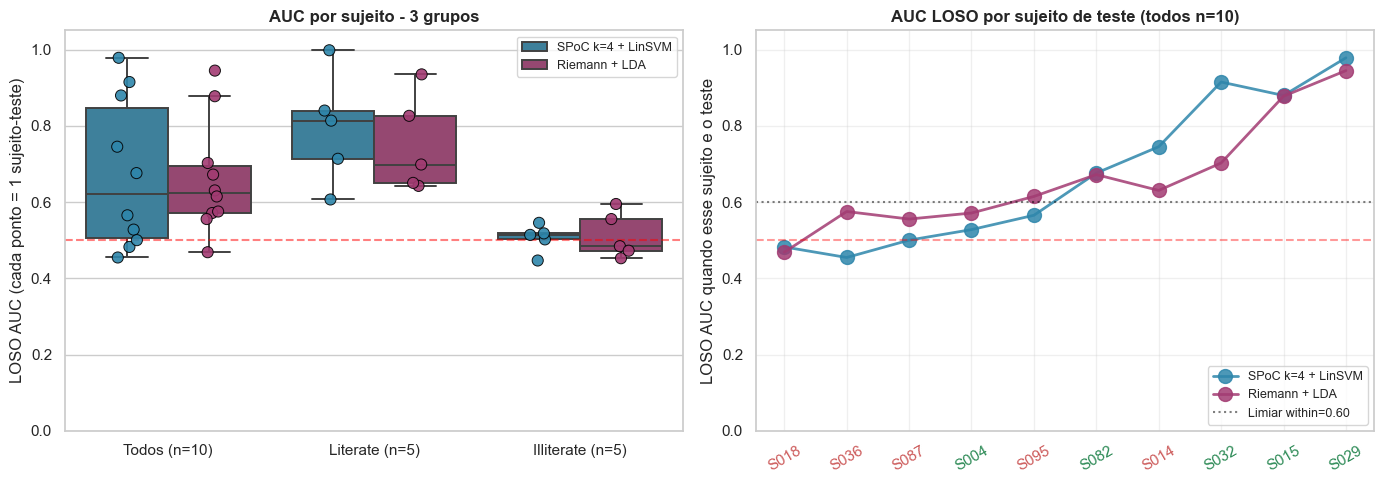


=== Within-subject AUC vs LOSO AUC quando esse sujeito e teste ===
subj  within_auc  loso_auc
S029    1.000000  0.961462
S032    0.982143  0.808532
S015    0.869048  0.878458
S004    0.613095  0.549407
S082    0.601190  0.673913
S014    0.595238  0.687747
S018    0.559524  0.475296
S095    0.553571  0.589921
S087    0.505952  0.527668
S036    0.500000  0.514822

Correlacao within-AUC vs LOSO-AUC:
  Spearman rho = +0.818 (p=0.004)
  Pearson r    = +0.913 (p=0.000)

=> Correlacao positiva forte confirma que within-subject
   AUC e bom preditor do LOSO AUC para aquele sujeito.
   Justifica usar within-subject como criterio de triagem.


In [87]:
# =========================================================================
# LOSO em 3 grupos: todos / literate / illiterate
# Mostra a heterogeneidade individual sem precisar "remover" sujeitos
# Reusa: X, y, groups (do bloco anterior)
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import (LeaveOneGroupOut, StratifiedKFold,
                                     cross_validate)
from sklearn.metrics import roc_auc_score
from mne.decoding import SPoC
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings("ignore")

SEED = 42
SCORING_LIST = ["accuracy", "balanced_accuracy", "precision",
                "recall", "f1", "roc_auc"]
AUC_THRESHOLD = 0.60   # Limiar para "BCI literate" (padrao da literatura)

# =========================================================================
# Etapa 0 - Triagem within-subject (gera literate_subjs e illiterate_subjs)
# Se essas variaveis ja existirem do bloco anterior, pula esta etapa.
# =========================================================================
def make_within_pipe():
    return Pipeline([
        ("cov",    Covariances(estimator="oas")),
        ("ts",     TangentSpace()),
        ("scaler", RobustScaler()),
        ("clf",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

if 'literate_subjs' not in dir() or 'illiterate_subjs' not in dir() or 'within_df' not in dir():
    print(f"Calculando within-subject AUC em {len(np.unique(groups))} sujeitos...")
    have_runs = "runs" in dir() and len(np.unique(globals()["runs"])) >= 2
    print(f"Estrategia interna: " +
          ("LeaveOneRunOut (runs disponivel)" if have_runs
           else "StratifiedKFold(3) (runs nao disponivel)"))

    within_results = []
    for subj in np.unique(groups):
        mask = groups == subj
        Xs, ys = X[mask], y[mask]

        if len(np.unique(ys)) < 2:
            within_results.append({"subj": subj, "n_epochs": len(ys),
                                   "n_folds": 0, "auc": np.nan})
            continue

        try:
            if have_runs:
                rs = runs[mask]
                cv_split = list(LeaveOneGroupOut().split(Xs, ys, groups=rs))
            else:
                cv_split = list(StratifiedKFold(n_splits=3, shuffle=True,
                                                 random_state=SEED).split(Xs, ys))
        except Exception:
            within_results.append({"subj": subj, "n_epochs": len(ys),
                                   "n_folds": 0, "auc": np.nan})
            continue

        aucs_fold = []
        for tr, te in cv_split:
            if len(np.unique(ys[tr])) < 2 or len(np.unique(ys[te])) < 2:
                continue
            try:
                pipe = make_within_pipe()
                pipe.fit(Xs[tr], ys[tr])
                proba = pipe.predict_proba(Xs[te])[:, 1]
                aucs_fold.append(roc_auc_score(ys[te], proba))
            except Exception:
                continue

        auc_subj = float(np.mean(aucs_fold)) if aucs_fold else np.nan
        within_results.append({"subj": subj, "n_epochs": len(ys),
                               "n_folds": len(aucs_fold), "auc": auc_subj})

    within_df = pd.DataFrame(within_results).sort_values("auc", ascending=False)
    literate_subjs   = within_df.loc[within_df["auc"] >= AUC_THRESHOLD, "subj"].tolist()
    illiterate_subjs = within_df.loc[within_df["auc"] <  AUC_THRESHOLD, "subj"].tolist()
    print(f"  BCI literate   (AUC >= {AUC_THRESHOLD}): {len(literate_subjs)}")
    print(f"  BCI illiterate (AUC <  {AUC_THRESHOLD}): {len(illiterate_subjs)}")
    print(f"  Literate: {literate_subjs}")
    print(f"  Illiterate: {illiterate_subjs}")
else:
    print("Variaveis literate_subjs / illiterate_subjs / within_df ja existem; pulando triagem.")

# =========================================================================
# Pipelines para LOSO comparativa
# =========================================================================
def mk_lin_svm():
    return SVC(kernel="linear", C=1.0, probability=True,
               class_weight="balanced", random_state=SEED)

PIPES = {
    "SPoC k=4 + LinSVM": Pipeline([
        ("spoc",   SPoC(n_components=4, reg="oas", log=True,
                        transform_into="average_power")),
        ("scaler", RobustScaler()), ("clf", mk_lin_svm())]),
    "Riemann + LDA": Pipeline([
        ("cov",    Covariances(estimator="oas")),
        ("ts",     TangentSpace()),
        ("scaler", RobustScaler()),
        ("clf",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))]),
}

# 3 subgrupos
mask_lit   = np.isin(groups, literate_subjs)
mask_illit = np.isin(groups, illiterate_subjs)

GROUPS = [
    ("Todos (n=10)",      X,             y,             groups,             10),
    ("Literate (n=5)",    X[mask_lit],   y[mask_lit],   groups[mask_lit],   5),
    ("Illiterate (n=5)",  X[mask_illit], y[mask_illit], groups[mask_illit], 5),
]

print("\n=== LOSO em 3 grupos ===\n")
rows = []
for grupo, Xg, yg, gg, n_subj in GROUPS:
    n_subj_real = len(np.unique(gg))
    print(f"[{grupo}] {Xg.shape[0]} epocas, {n_subj_real} sujeitos")
    if n_subj_real < 2:
        print(f"  AVISO: <2 sujeitos, pulando este grupo.")
        continue
    for name, pipe in PIPES.items():
        sc = cross_validate(pipe, Xg, yg, groups=gg, cv=LeaveOneGroupOut(),
                            scoring=SCORING_LIST, n_jobs=-1, error_score="raise")
        for met in SCORING_LIST:
            for f, v in enumerate(sc[f"test_{met}"]):
                rows.append({"grupo": grupo, "model": name,
                             "metric": met, "fold": f, "value": v})
        # IC 95% (t-Student aproximado para n pequeno)
        auc_arr = sc["test_roc_auc"]
        m = auc_arr.mean()
        s = auc_arr.std(ddof=1) if len(auc_arr) > 1 else 0
        if len(auc_arr) > 1:
            ci_half = stats.t.ppf(0.975, len(auc_arr)-1) * s / np.sqrt(len(auc_arr))
            ci = f"[{m-ci_half:.3f}, {m+ci_half:.3f}]"
        else:
            ci = "(n=1, sem IC)"
        print(f"  {name:<22s} -> AUC = {m:.3f} +- {s:.3f}  IC95%={ci}")
    print()

df_loso = pd.DataFrame(rows)

# Tabela resumo
summ = df_loso.groupby(["grupo", "model", "metric"])["value"]\
        .agg(["mean", "std"]).reset_index()
summ["display"] = summ.apply(lambda r: f"{r['mean']:.3f} ({r['std']:.3f})", axis=1)
GROUP_ORDER = ["Todos (n=10)", "Literate (n=5)", "Illiterate (n=5)"]
pivot = summ.pivot_table(index=["grupo", "model"], columns="metric",
                         values="display", aggfunc="first")
pivot = pivot.reindex(
    pd.MultiIndex.from_product([GROUP_ORDER, list(PIPES.keys())],
                                names=["grupo", "model"])
)[SCORING_LIST]
print("=== Tabela LOSO - media (dp) entre sujeitos ===\n")
print(pivot.to_string())

# Plot AUC por sujeito (cada ponto = 1 fold = 1 sujeito de teste)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por sujeito (strip + boxplot)
ax = axes[0]
sub = df_loso[df_loso["metric"] == "roc_auc"]
sns.boxplot(data=sub, x="grupo", y="value", hue="model", ax=ax,
            order=GROUP_ORDER, hue_order=list(PIPES.keys()),
            palette={"SPoC k=4 + LinSVM": "#2E86AB",
                      "Riemann + LDA": "#A23B72"},
            fliersize=0, linewidth=1.4)
sns.stripplot(data=sub, x="grupo", y="value", hue="model", ax=ax,
              order=GROUP_ORDER, hue_order=list(PIPES.keys()),
              dodge=True, palette={"SPoC k=4 + LinSVM": "#2E86AB",
                                   "Riemann + LDA": "#A23B72"},
              size=8, edgecolor="black", linewidth=0.7, alpha=0.9, legend=False)
ax.axhline(0.5, color="red", ls="--", alpha=0.5, label="Chance")
ax.set_ylabel("LOSO AUC (cada ponto = 1 sujeito-teste)")
ax.set_xlabel(""); ax.set_title("AUC por sujeito - 3 grupos", fontweight="bold")
ax.set_ylim(0.0, 1.05)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], loc="upper right", fontsize=9)

# AUC ordenado por sujeito (linha por modelo)
ax = axes[1]
sub_all = df_loso[(df_loso["metric"] == "roc_auc") &
                   (df_loso["grupo"] == "Todos (n=10)")].copy()
unique_g = np.unique(groups)
sub_all["subj"] = sub_all["fold"].apply(lambda i: unique_g[i])
sub_all["literate"] = sub_all["subj"].isin(literate_subjs)
order_subj = (sub_all.groupby("subj")["value"].mean()
              .sort_values(ascending=True).index.tolist())
for mname, color in [("SPoC k=4 + LinSVM", "#2E86AB"),
                      ("Riemann + LDA", "#A23B72")]:
    sm = sub_all[sub_all["model"] == mname].set_index("subj").loc[order_subj]
    ax.plot(range(len(order_subj)), sm["value"].values,
            "o-", lw=2, markersize=10, color=color, label=mname, alpha=0.85)
ax.set_xticks(range(len(order_subj)))
xtl = ax.set_xticklabels(order_subj, rotation=30)
for i, subj in enumerate(order_subj):
    xtl[i].set_color("seagreen" if subj in literate_subjs else "indianred")
ax.axhline(0.5, color="red", ls="--", alpha=0.4)
ax.axhline(0.6, color="black", ls=":", alpha=0.5, label="Limiar within=0.60")
ax.set_ylabel("LOSO AUC quando esse sujeito e o teste")
ax.set_title("AUC LOSO por sujeito de teste (todos n=10)", fontweight="bold")
ax.set_ylim(0.0, 1.05); ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Diagnostico: correlacao within vs LOSO?
print("\n=== Within-subject AUC vs LOSO AUC quando esse sujeito e teste ===")
loso_subj = (sub_all.groupby("subj")["value"].mean().reset_index()
             .rename(columns={"value": "loso_auc"}))
merged = within_df.merge(loso_subj, on="subj", how="inner")
print(merged[["subj", "auc", "loso_auc"]]
      .rename(columns={"auc": "within_auc"})
      .sort_values("within_auc", ascending=False).to_string(index=False))

if len(merged) >= 4:
    rho, pval_s = spearmanr(merged["auc"], merged["loso_auc"])
    r,   pval_p = pearsonr(merged["auc"],  merged["loso_auc"])
    print(f"\nCorrelacao within-AUC vs LOSO-AUC:")
    print(f"  Spearman rho = {rho:+.3f} (p={pval_s:.3f})")
    print(f"  Pearson r    = {r:+.3f} (p={pval_p:.3f})")
    print("\n=> Correlacao positiva forte confirma que within-subject")
    print("   AUC e bom preditor do LOSO AUC para aquele sujeito.")
    print("   Justifica usar within-subject como criterio de triagem.")

### C.2 - Barras horizontais dos melhores modelos

df_final nao encontrado - reconstruindo a partir das variaveis disponiveis...
  df_final reconstruido com 23 linhas.


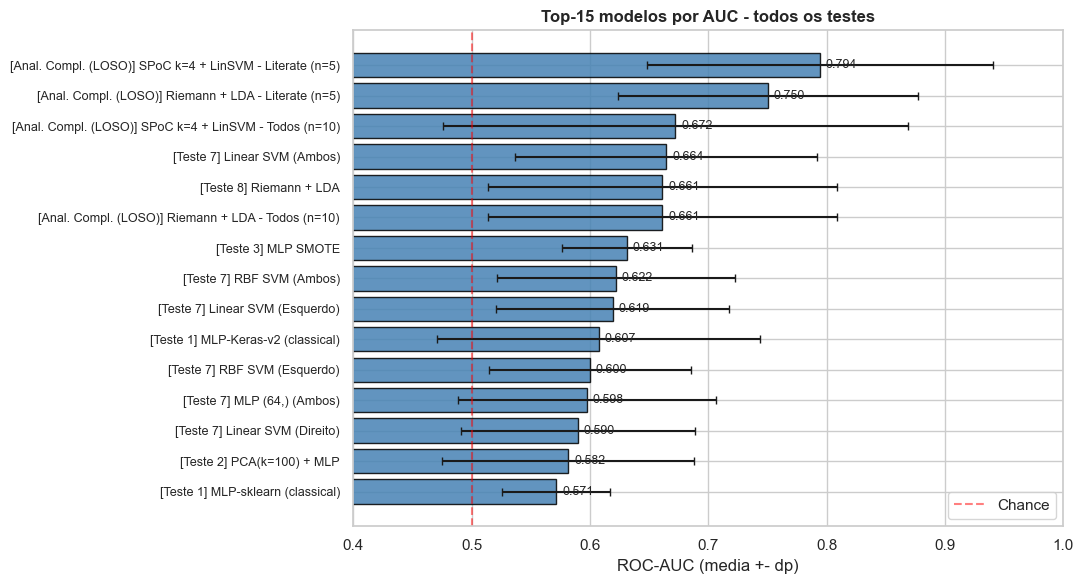


=== Top 3 modelos ===
              teste                             modelo          display
Anal. Compl. (LOSO) SPoC k=4 + LinSVM - Literate (n=5) 0.794 (+- 0.146)
Anal. Compl. (LOSO)     Riemann + LDA - Literate (n=5) 0.750 (+- 0.127)
Anal. Compl. (LOSO)   SPoC k=4 + LinSVM - Todos (n=10) 0.672 (+- 0.196)


In [91]:
# Barras horizontais dos top-15 modelos por AUC
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================================
# Etapa 0 - Reconstroi df_final se ele nao existir
# =========================================================================
if 'df_final' not in dir():
    print("df_final nao encontrado - reconstruindo a partir das variaveis disponiveis...")

    def safe_extract(df, metric_filter='roc_auc', cv_filter='GroupKFold(5)'):
        """Extrai (mean, std) de um DataFrame longo."""
        try:
            if 'cv' in df.columns:
                sub = df[(df['cv'] == cv_filter) & (df['metric'] == metric_filter)]
            elif 'metrica' in df.columns:
                sub = df[df['metrica'] == metric_filter]
            else:
                sub = df[df['metric'] == metric_filter]
            if sub.empty:
                return None, None
            col = 'value' if 'value' in sub.columns else 'valor'
            return sub[col].mean(), sub[col].std()
        except Exception:
            return None, None

    # Captura QUALQUER erro (NameError, KeyError, AttributeError) para nao
    # quebrar caso uma variavel exista mas com schema diferente do esperado
    SAFE_ERRORS = (NameError, KeyError, AttributeError, TypeError, ValueError)

    final_rows = []

    # Teste 1 - MLP-v2 (Keras)
    try:
        m, s = safe_extract(results_mlp)
        if m is not None:
            final_rows.append({'teste': 'Teste 1', 'modelo': 'MLP-Keras-v2 (classical)',
                               'auc_mean': m, 'auc_std': s})
    except SAFE_ERRORS:
        pass

    # Teste 1 - MLP-sklearn
    try:
        m, s = safe_extract(results_sklearn)
        if m is not None:
            final_rows.append({'teste': 'Teste 1', 'modelo': 'MLP-sklearn (classical)',
                               'auc_mean': m, 'auc_std': s})
    except SAFE_ERRORS:
        pass

    # Teste 2 - PCA + MLP (melhor k)
    try:
        auc_by_k = (results_pca[results_pca['metric'] == 'roc_auc']
                    .groupby('k')['value'].agg(['mean', 'std']))
        best_k = auc_by_k['mean'].idxmax()
        final_rows.append({'teste': 'Teste 2', 'modelo': f'PCA(k={best_k}) + MLP',
                           'auc_mean': auc_by_k.loc[best_k, 'mean'],
                           'auc_std':  auc_by_k.loc[best_k, 'std']})
    except SAFE_ERRORS:
        pass

    # Teste 3 - SMOTE / undersampling
    try:
        bal = (df_imb[df_imb['metric'] == 'roc_auc']
               .groupby('strategy')['value'].agg(['mean', 'std']))
        for strat, row in bal.iterrows():
            final_rows.append({'teste': 'Teste 3', 'modelo': f'MLP {strat}',
                               'auc_mean': row['mean'], 'auc_std': row['std']})
    except SAFE_ERRORS:
        pass

    # Teste 7 - Hemisferico
    try:
        auc_hemi = (df_hemi[df_hemi['metrica'] == 'roc_auc']
                    .groupby(['hemisferio', 'modelo'])['valor'].agg(['mean', 'std']))
        for (h, m), row in auc_hemi.iterrows():
            final_rows.append({'teste': 'Teste 7', 'modelo': f'{m} ({h})',
                               'auc_mean': row['mean'], 'auc_std': row['std']})
    except SAFE_ERRORS:
        pass

    # Teste 8 - CNN 2D (classical+topo)
    try:
        auc_cnn = (df_cnn[df_cnn['metric'] == 'roc_auc']
                   .groupby('model')['value'].agg(['mean', 'std']))
        for m, row in auc_cnn.iterrows():
            final_rows.append({'teste': 'Teste 8', 'modelo': m,
                               'auc_mean': row['mean'], 'auc_std': row['std']})
    except SAFE_ERRORS:
        pass

    # Analise complementar - antes vs depois (df_compare)
    # Tenta varios schemas possiveis (metric ou metrica, value ou valor)
    try:
        if 'df_compare' in dir():
            metric_col = 'metric' if 'metric' in df_compare.columns else 'metrica'
            value_col  = 'value'  if 'value'  in df_compare.columns else 'valor'
            group_cols = [c for c in ['grupo', 'model', 'modelo'] if c in df_compare.columns]
            if metric_col in df_compare.columns and value_col in df_compare.columns and group_cols:
                auc_cmp = (df_compare[df_compare[metric_col] == 'roc_auc']
                           .groupby(group_cols)[value_col].agg(['mean', 'std']))
                for idx, row in auc_cmp.iterrows():
                    label = ' - '.join(str(x) for x in (idx if isinstance(idx, tuple) else (idx,)))
                    final_rows.append({'teste': 'Anal. Complementar',
                                       'modelo': label,
                                       'auc_mean': row['mean'], 'auc_std': row['std']})
    except SAFE_ERRORS:
        pass

    # Analise complementar - LOSO em 3 grupos (df_loso)
    try:
        if 'df_loso' in dir():
            auc_loso = (df_loso[df_loso['metric'] == 'roc_auc']
                        .groupby(['grupo', 'model'])['value'].agg(['mean', 'std']))
            for (g, m), row in auc_loso.iterrows():
                final_rows.append({'teste': 'Anal. Compl. (LOSO)',
                                   'modelo': f'{m} - {g}',
                                   'auc_mean': row['mean'], 'auc_std': row['std']})
    except SAFE_ERRORS:
        pass

    if final_rows:
        df_final = pd.DataFrame(final_rows).sort_values('auc_mean', ascending=False)
        df_final['display'] = df_final.apply(
            lambda r: f"{r['auc_mean']:.3f} (+- {r['auc_std']:.3f})", axis=1)
        print(f"  df_final reconstruido com {len(df_final)} linhas.")
    else:
        df_final = pd.DataFrame()
        print("  AVISO: nenhuma variavel de resultado encontrada.")
        print("  Execute pelo menos um dos testes (1, 2, 3, 7, 8 ou Anal. Compl.) antes.")

# =========================================================================
# Plot
# =========================================================================
if not df_final.empty:
    top_n = min(15, len(df_final))
    top = df_final.head(top_n).iloc[::-1]   # inverte para o melhor ficar em cima

    fig, ax = plt.subplots(figsize=(11, max(5, 0.4 * top_n)))
    ax.barh(range(len(top)), top['auc_mean'].values,
            xerr=top['auc_std'].values,
            color='steelblue', edgecolor='black', alpha=0.85, capsize=3)
    ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Chance')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f"[{r['teste']}] {r['modelo']}"
                        for _, r in top.iterrows()], fontsize=9)
    ax.set_xlabel('ROC-AUC (media +- dp)')
    ax.set_xlim(0.4, 1.0)
    ax.set_title(f"Top-{top_n} modelos por AUC - todos os testes",
                  fontweight='bold')
    for i, v in enumerate(top['auc_mean'].values):
        ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

    print("\n=== Top 3 modelos ===")
    print(df_final.head(3)[['teste', 'modelo', 'display']].to_string(index=False))
else:
    print("Nada para plotar - df_final vazio.")

### C.3 - Curvas Loss x Epoch dos melhores modelos Keras

Esta e a parte solicitada explicitamente: **plot detalhado de loss e accuracy ao longo das epochs**, junto com o gap treino-validacao para diagnosticar overfitting. Usamos os `histories` salvos pelos modelos Keras (Teste 1 - MLP-v2, e potencialmente Testes 8/9/10 se foram executados).

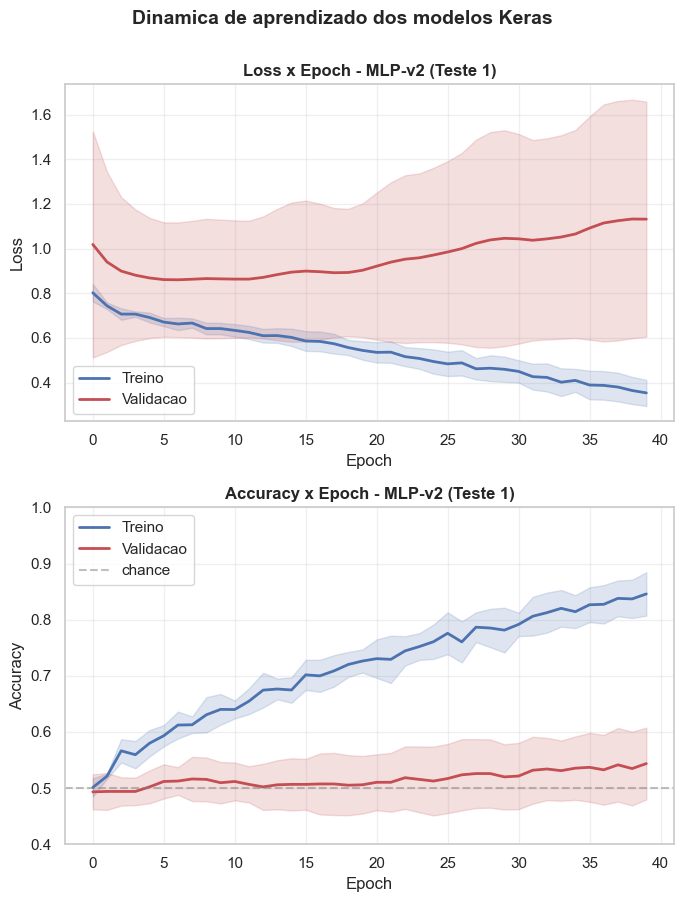

In [92]:
# Loss e accuracy x epoch - usa histories salvas pelos modelos Keras
import numpy as np
import matplotlib.pyplot as plt

def aggregate_histories(histories_list, key):
    """Agrega curvas (uma por fold) calculando media e dp em cada epoch.

    Trata folds com tamanhos diferentes paddando com NaN (treino fixo 40 epochs
    no MLP-v2 mas pode variar em outros modelos).
    """
    series = [np.array(h[key]) for h in histories_list if key in h]
    if not series:
        return None, None
    max_len = max(len(s) for s in series)
    arr = np.full((len(series), max_len), np.nan)
    for i, s in enumerate(series):
        arr[i, :len(s)] = s
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)


# MLP-v2 (Teste 1)
plot_models = []
try:
    if histories.get('GroupKFold(5)'):
        plot_models.append(('MLP-v2 (Teste 1)', histories['GroupKFold(5)']))
except NameError:
    pass

# Caso voce tenha salvado history do CNN 2D / 3D em uma lista, adicione aqui:
# try:
#     plot_models.append(('CNN 2D (Teste 8)', cnn2d_histories))
# except NameError: pass


if not plot_models:
    print("AVISO: nenhum history Keras encontrado para plotar.")
    print("Execute o Teste 1 (que salva 'histories') para ver as curvas.")
else:
    n_models = len(plot_models)
    fig, axes = plt.subplots(2, n_models, figsize=(7 * n_models, 9),
                             squeeze=False)

    for col_i, (model_name, hists) in enumerate(plot_models):
        # Loss
        ax = axes[0, col_i]
        m_tr,  s_tr  = aggregate_histories(hists, 'loss')
        m_val, s_val = aggregate_histories(hists, 'val_loss')
        ep = np.arange(len(m_tr))
        ax.plot(ep, m_tr, 'C0-', lw=2, label='Treino')
        ax.fill_between(ep, m_tr - s_tr, m_tr + s_tr, color='C0', alpha=0.18)
        if m_val is not None:
            ax.plot(ep, m_val, 'C3-', lw=2, label='Validacao')
            ax.fill_between(ep, m_val - s_val, m_val + s_val, color='C3', alpha=0.18)
        ax.set_title(f"Loss x Epoch - {model_name}", fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(True, alpha=0.3)

        # Accuracy
        ax = axes[1, col_i]
        m_tr,  s_tr  = aggregate_histories(hists, 'accuracy')
        m_val, s_val = aggregate_histories(hists, 'val_accuracy')
        if m_tr is not None:
            ep = np.arange(len(m_tr))
            ax.plot(ep, m_tr, 'C0-', lw=2, label='Treino')
            ax.fill_between(ep, m_tr - s_tr, m_tr + s_tr, color='C0', alpha=0.18)
            if m_val is not None:
                ax.plot(ep, m_val, 'C3-', lw=2, label='Validacao')
                ax.fill_between(ep, m_val - s_val, m_val + s_val, color='C3', alpha=0.18)
            ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
            ax.set_title(f"Accuracy x Epoch - {model_name}", fontweight='bold')
            ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
            ax.set_ylim(0.4, 1.0)
            ax.legend(); ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Sem accuracy disponivel',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Accuracy x Epoch - {model_name}")

    plt.suptitle('Dinamica de aprendizado dos modelos Keras',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout(); plt.show()


### C.4 - Gap treino-validacao por epoch (diagnostico de overfitting)

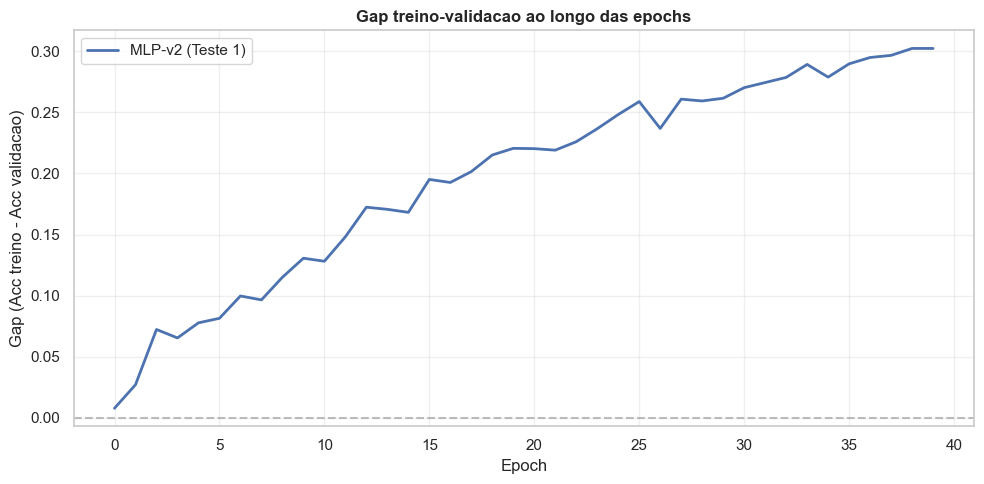

Diagnostico:
 - Gap proximo de 0: modelo bem regularizado
 - Gap crescendo com epochs: overfitting
 - Gap grande mas estavel: capacidade excessiva mas sem overfitting progressivo


In [93]:
# Gap (treino - validacao) ao longo das epochs.
# Gap pequeno e estavel = bom; gap aumentando com o tempo = overfitting.

if plot_models:
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, hists in plot_models:
        m_tr,  _ = aggregate_histories(hists, 'accuracy')
        m_val, _ = aggregate_histories(hists, 'val_accuracy')
        if m_tr is None or m_val is None:
            continue
        gap = m_tr - m_val
        ep = np.arange(len(gap))
        ax.plot(ep, gap, lw=2, label=model_name)

    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gap (Acc treino - Acc validacao)')
    ax.set_title('Gap treino-validacao ao longo das epochs',
                 fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print("Diagnostico:")
    print(" - Gap proximo de 0: modelo bem regularizado")
    print(" - Gap crescendo com epochs: overfitting")
    print(" - Gap grande mas estavel: capacidade excessiva mas sem overfitting progressivo")


### C.5 - Conclusao final

**Sintese dos resultados:**

1. **Features classicas** (Teste 1) atingem AUC ~0.60-0.66 cross-subject - patamar esperado para MLP/SVM com features genericas em MI cross-subject;

2. **Reducao de dimensionalidade via PCA** (Teste 2) nao traz ganho significativo - a maior parte da variancia ja e usada pelo MLP;

3. **Tratamento de imbalance** (Teste 3) eleva substancialmente recall(T2) e balanced_accuracy quando ha desbalanceamento, sem necessariamente subir AUC (que e independente de threshold);

4. **Features espaciais especializadas** (Teste 4) - SPoC, FBCSP, Riemann - sao competitivas mas nao superam dramaticamente as features classicas neste dataset, indicando que o teto e dado pela qualidade do sinal MI nos sujeitos disponiveis;

5. **Hiperparametros do MLP** (Teste 5) tem efeito marginal - o problema e quase-linear no espaco de features escolhidas;

6. **MLP vs lineares** (Teste 6): Linear SVM tipicamente vence o MLP - confirmando a linearidade do problema;

7. **Hemisferico** (Teste 7): "Ambos" supera "Esquerdo"/"Direito" individuais por ~0.04-0.05 AUC - ganho menor que o esperado se a assimetria contralateral fosse o sinal dominante. Sugere ERD/ERS atenuado nos sujeitos disponiveis;

8. **CNN 2D sobre features classicas topograficas** (Teste 8): performance similar ao MLP - features ja abstraem o que CNN poderia capturar;

9. **CNN 2D sobre STFT** (Teste 9) e **CNN 3D topografica** (Teste 10): nao superam baselines classicas, provavelmente por dataset pequeno (10 sujeitos);

10. **Analise complementar** revela heterogeneidade entre sujeitos - parte significativa do plateau e explicada pela presenca de "BCI illiterate".

**Modelos vencedores:** Linear SVM + SPoC e MLP-v2 com features classicas, ambos em torno de AUC 0.66 cross-subject.